In [1]:
import os, math
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

plt.rcParams["figure.dpi"] = 300
sns.set(style="whitegrid")

print("hi")

hi


In [2]:
# ============================================================
# 0. Configuration
# ============================================================

@dataclass
class Config:
    # Paths
    data_path_transaction: str = "/kaggle/input/ieee-fraud-detection/train_transaction.csv"
    working_dir: str = "/kaggle/working"

    # Columns
    transaction_id_col: str = "TransactionID"
    time_col: str = "TransactionDT"
    target_col: str = "isFraud"
    card_id_col: str = "card1"

    # Sampling for quick debug (1.0 = full data)
    sample_frac: float = 1.0

    # Drift window settings (global)
    global_window_size: int = 20_000
    global_step_size: int = 10_000

    # Drift window settings (local card-level)
    local_window_size: int = 200
    local_step_size: int = 100
    local_min_tx_per_card: int = 500
    max_cards_for_local: int = 50

    # PSI settings
    psi_num_bins: int = 10
    psi_min_count: int = 10
    # Statistical drift severity threshold (L2 over PSI)
    # (Raised from 0.20 → 0.50 to avoid “drift everywhere”)
    min_event_severity: float = 0.50

    # Extra controls for statistical drift
    min_strong_features_global: int = 2   # require at least 2 strong features for global drift
    min_strong_features_local: int = 1    # require at least 1 strong feature for local drift
    min_behaviour_group_severity: float = 0.0  # can be >0.0 if you want behaviour features to be involved

    # ADWIN parameters (on severity stream)
    adwin_delta: float = 0.002
    adwin_min_window: int = 20
    adwin_max_window: int = 200

    # Page-Hinkley parameters (on severity stream)
    ph_lambda: float = 0.5
    ph_delta: float = 0.005
    ph_alpha: float = 0.999
    ph_min_instances: int = 30


cfg = Config()


def ensure_working_dir(cfg: Config) -> None:
    os.makedirs(cfg.working_dir, exist_ok=True)


def save_fig_300dpi(fig: plt.Figure, filename: str, cfg: Config) -> None:
    """
    Save figure at 300 dpi into /kaggle/working and show it.
    """
    ensure_working_dir(cfg)
    out_path = os.path.join(cfg.working_dir, filename)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[INFO] Saved figure to: {out_path}")

print("hi")

hi


In [3]:
# ============================================================
# 1. Data loading and rich EDA
# ============================================================

def load_ieee_data(cfg: Config) -> pd.DataFrame:
    """
    Load IEEE train_transaction; optionally sample a fraction.
    """
    df = pd.read_csv(cfg.data_path_transaction)
    if cfg.sample_frac < 1.0:
        df = df.sample(frac=cfg.sample_frac, random_state=42)
    return df


def rich_eda(df: pd.DataFrame, cfg: Config) -> None:
    """
    Rich EDA with tables + 300 dpi plots for dissertation figures.
    """
    print("Head:")
    display(df.head())

    print("\nInfo:")
    print(df.info())

    # Overall fraud summary
    if cfg.target_col in df.columns:
        total = len(df)
        fraud_count = df[cfg.target_col].sum()
        fraud_rate = fraud_count / total
        fraud_summary = pd.DataFrame(
            {"total_rows": [total], "fraud_count": [fraud_count], "fraud_rate": [fraud_rate]}
        )
        print("\nOverall fraud summary:")
        display(fraud_summary.style.format({"fraud_rate": "{:.4%}"}))

    # Missingness
    miss_pct = df.isna().mean().sort_values(ascending=False) * 100
    miss_df = miss_pct.to_frame(name="missing_pct").reset_index()
    miss_df.rename(columns={"index": "feature"}, inplace=True)
    print("\nMissingness (top 40 features):")
    display(miss_df.head(40).style.format({"missing_pct": "{:.2f}"}))

    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
    sns.barplot(
        data=miss_df.head(40),
        x="missing_pct",
        y="feature",
        orient="h",
        ax=ax,
    )
    ax.set_xlabel("Missing (%)")
    ax.set_ylabel("Feature")
    ax.set_title("Top 40 features by missing percentage")
    plt.tight_layout()
    save_fig_300dpi(fig, "fig_eda_missingness_top40.png", cfg)

    # Time-based EDA
    if cfg.time_col in df.columns and cfg.target_col in df.columns:
        tmp = df[[cfg.time_col, cfg.target_col]].copy()
        day_secs = 24 * 60 * 60
        tmp["time_bin_day"] = (tmp[cfg.time_col] // day_secs).astype(int)

        agg = (
            tmp.groupby("time_bin_day")
            .agg(
                count=("time_bin_day", "size"),
                fraud_count=(cfg.target_col, "sum"),
                fraud_rate=(cfg.target_col, "mean"),
            )
            .reset_index()
        )
        print("\nTime-based volume and fraud stats (first 20 bins):")
        display(
            agg.head(20).style.format(
                {"count": "{:,.0f}", "fraud_count": "{:,.0f}", "fraud_rate": "{:.4%}"}
            )
        )

        fig, ax1 = plt.subplots(figsize=(10, 4), dpi=300)
        sns.lineplot(data=agg, x="time_bin_day", y="count", ax=ax1, label="Count")
        ax1.set_ylabel("Transaction count", color="tab:blue")
        ax1.tick_params(axis="y", labelcolor="tab:blue")

        ax2 = ax1.twinx()
        sns.lineplot(
            data=agg,
            x="time_bin_day",
            y="fraud_rate",
            ax=ax2,
            label="Fraud rate",
            color="tab:red",
        )
        ax2.set_ylabel("Fraud rate", color="tab:red")
        ax2.tick_params(axis="y", labelcolor="tab:red")

        ax1.set_xlabel("Time bin (approx days)")
        plt.title("Transactions and fraud rate over time (per-day bins)")
        fig.tight_layout()
        save_fig_300dpi(fig, "fig_eda_time_fraud_per_day.png", cfg)

    # TransactionAmt
    if "TransactionAmt" in df.columns:
        df["TransactionAmt_log1p"] = np.log1p(df["TransactionAmt"])

        overall_stats = df["TransactionAmt"].describe().to_frame(name="overall").T
        print("\nTransactionAmt summary (overall):")
        display(overall_stats.style.format("{:,.2f}"))

        if cfg.target_col in df.columns:
            by_fraud = df.groupby(cfg.target_col)["TransactionAmt"].describe()
            print("\nTransactionAmt summary by isFraud:")
            display(by_fraud.style.format("{:,.2f}"))

        fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
        sns.histplot(df["TransactionAmt"], bins=100, kde=False, ax=ax)
        ax.set_xlabel("TransactionAmt")
        ax.set_ylabel("Count")
        ax.set_title("Distribution of TransactionAmt (raw)")
        plt.tight_layout()
        save_fig_300dpi(fig, "fig_eda_txamt_hist_raw.png", cfg)

        fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
        sns.histplot(df["TransactionAmt_log1p"], bins=100, kde=False, ax=ax)
        ax.set_xlabel("log1p(TransactionAmt)")
        ax.set_ylabel("Count")
        ax.set_title("Distribution of TransactionAmt (log1p)")
        plt.tight_layout()
        save_fig_300dpi(fig, "fig_eda_txamt_hist_log1p.png", cfg)

        if cfg.target_col in df.columns:
            fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
            sns.boxplot(
                data=df.sample(min(100_000, len(df)), random_state=42),
                x=cfg.target_col,
                y="TransactionAmt_log1p",
                ax=ax,
            )
            ax.set_xlabel("isFraud")
            ax.set_ylabel("log1p(TransactionAmt)")
            ax.set_title("TransactionAmt (log1p) by fraud label")
            plt.tight_layout()
            save_fig_300dpi(fig, "fig_eda_txamt_by_fraud_log1p.png", cfg)

    # Key categoricals
    for cat_col in ["ProductCD", "card4", "card6"]:
        if cat_col not in df.columns:
            continue
        print(f"\nCategorical summary for {cat_col}:")
        if cfg.target_col in df.columns:
            cat_stats = (
                df.groupby(cat_col)[cfg.target_col]
                .agg(count="size", fraud_count="sum", fraud_rate="mean")
                .reset_index()
            )
        else:
            cat_stats = df[cat_col].value_counts().to_frame("count").reset_index()
            cat_stats.columns = [cat_col, "count"]
            cat_stats["fraud_count"] = np.nan
            cat_stats["fraud_rate"] = np.nan
        display(
            cat_stats.sort_values("count", ascending=False).style.format(
                {"count": "{:,.0f}", "fraud_count": "{:,.0f}", "fraud_rate": "{:.4%}"}
            )
        )

        fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
        sns.barplot(
            data=cat_stats.sort_values("count", ascending=False),
            x=cat_col,
            y="count",
            ax=ax,
        )
        ax.set_xlabel(cat_col)
        ax.set_ylabel("Count")
        ax.set_title(f"{cat_col} distribution (count)")
        plt.tight_layout()
        save_fig_300dpi(fig, f"fig_eda_{cat_col}_count.png", cfg)

    # card1
    if cfg.card_id_col in df.columns:
        if cfg.target_col in df.columns:
            card_stats = (
                df.groupby(cfg.card_id_col)[cfg.target_col]
                .agg(count="size", fraud_count="sum", fraud_rate="mean")
                .reset_index()
            )
        else:
            card_stats = (
                df[cfg.card_id_col]
                .value_counts()
                .to_frame("count")
                .reset_index()
            )
            card_stats.columns = [cfg.card_id_col, "count"]
            card_stats["fraud_count"] = np.nan
            card_stats["fraud_rate"] = np.nan

        card_stats_sorted = card_stats.sort_values("count", ascending=False)
        print("\nTop 30 card1 by volume:")
        display(
            card_stats_sorted.head(30).style.format(
                {"count": "{:,.0f}", "fraud_count": "{:,.0f}", "fraud_rate": "{:.4%}"}
            )
        )

        fig, ax = plt.subplots(figsize=(12, 4), dpi=300)
        sns.barplot(
            data=card_stats_sorted.head(30),
            x=cfg.card_id_col,
            y="count",
            ax=ax,
        )
        ax.set_xlabel(cfg.card_id_col)
        ax.set_ylabel("Count")
        ax.set_title("Top 30 card1 by transaction volume")
        plt.xticks(rotation=90)
        plt.tight_layout()
        save_fig_300dpi(fig, "fig_eda_card1_top30_count.png", cfg)

print("hi")

hi


In [4]:
# ============================================================
# 2. Drift feature selection (impactful + < 5% missing)
# ============================================================

DRIFT_MAX_MISSING_PCT = 5.0

@dataclass
class DriftFeatureConfig:
    max_missing_pct: float = 5.0
    add_features: Optional[List[str]] = None
    drop_features: Optional[List[str]] = None
    use_manual_only: bool = False  # if True, ignore automatic list and only use add_features


def feature_group(col: str, cfg: Config) -> str:
    cl = col.lower()
    if col in ("TransactionAmt", "TransactionAmt_log1p"):
        return "amount"
    if col.startswith("card") or col == cfg.card_id_col:
        return "card"
    if cl.startswith("addr") or col.startswith("dist"):
        return "address"
    if col.startswith("C") or col.startswith("D") or col.startswith("M"):
        return "behaviour"
    if col.startswith("V"):
        return "v_block"
    return "other"


def build_impact_feature_list(df: pd.DataFrame,
                              cfg: Config,
                              feat_cfg: DriftFeatureConfig) -> List[str]:
    """
    Build list of candidate drift features.
    If use_manual_only=True, we only use feat_cfg.add_features (filtered to existing columns).
    Otherwise, we use a heuristic automatic list (without full V-block, to avoid feature explosion).
    """
    # Manual-only path
    if feat_cfg.use_manual_only and feat_cfg.add_features:
        manual = [c for c in feat_cfg.add_features if c in df.columns]
        if feat_cfg.drop_features:
            manual = [c for c in manual if c not in feat_cfg.drop_features]
        return manual

    cols: List[str] = []

    # Amount
    if "TransactionAmt" in df.columns:
        if "TransactionAmt_log1p" not in df.columns:
            df["TransactionAmt_log1p"] = np.log1p(df["TransactionAmt"])
        cols.extend(["TransactionAmt", "TransactionAmt_log1p"])

    # Key categoricals
    for c in ["ProductCD", "card4", "card6"]:
        if c in df.columns:
            cols.append(c)

    # card1..card6
    for i in range(1, 7):
        c = f"card{i}"
        if c in df.columns:
            cols.append(c)

    # addr/dist
    for c in ["addr1", "addr2", "dist1", "dist2"]:
        if c in df.columns:
            cols.append(c)

    # C, D, M
    for prefix, max_idx in [("C", 14), ("D", 15), ("M", 9)]:
        for i in range(1, max_idx + 1):
            c = f"{prefix}{i}"
            if c in df.columns:
                cols.append(c)

    # NOTE: We deliberately do NOT automatically include full V-block here
    # to avoid extremely high-dimensional drift features.
    # You can still manually add selected V-features via add_features.

    # Additional manual features
    if feat_cfg.add_features:
        for c in feat_cfg.add_features:
            if c in df.columns:
                cols.append(c)

    # Deduplicate
    seen = set()
    out = []
    for c in cols:
        if c not in seen:
            seen.add(c)
            out.append(c)

    # Drop manual
    if feat_cfg.drop_features:
        out = [c for c in out if c not in feat_cfg.drop_features]

    return out


def select_drift_features(df: pd.DataFrame,
                          cfg: Config,
                          feat_cfg: DriftFeatureConfig
                          ) -> Tuple[List[str], pd.DataFrame]:
    """
    From candidate features, keep only those with < max_missing_pct.
    """
    candidates = build_impact_feature_list(df, cfg, feat_cfg)

    miss_pct = df[candidates].isna().mean().mul(100.0)
    selected = miss_pct[miss_pct < feat_cfg.max_missing_pct].index.tolist()

    info = pd.DataFrame({
        "feature": selected,
        "missing_pct": miss_pct[selected].values,
        "dtype": [str(df[c].dtype) for c in selected],
    })
    info["group"] = info["feature"].apply(lambda c: feature_group(c, cfg))
    info = info.sort_values(["group", "feature"]).reset_index(drop=True)

    print(
        f"\n[Drift features] Candidates: {len(candidates)}, "
        f"Selected (< {feat_cfg.max_missing_pct:.1f}% missing): {len(selected)}"
    )
    display(info.style.format({"missing_pct": "{:.2f}"}))

    ensure_working_dir(cfg)
    info.to_csv(os.path.join(cfg.working_dir, "drift_features_selected.csv"), index=False)
    print("[INFO] Saved drift_features_selected.csv")

    # Bar plot: number of features per group
    group_counts = (
        info.groupby("group")["feature"].count().reset_index(name="num_features")
        .sort_values("num_features", ascending=False)
    )
    print("\nNumber of selected drift features per group:")
    display(group_counts)

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    sns.barplot(data=group_counts, x="group", y="num_features", ax=ax)
    ax.set_xlabel("Group")
    ax.set_ylabel("Number of features")
    ax.set_title("Selected drift features per group")
    plt.xticks(rotation=45)
    plt.tight_layout()
    save_fig_300dpi(fig, "fig_drift_features_per_group.png", cfg)

    return selected, info

print("hi")

hi


In [5]:
# ============================================================
# 3. PSI scoring (per feature) + severity
# ============================================================

# Strong-feature threshold: higher = fewer strong features → more realistic univariate events.
PSI_STRONG_FEATURE_THRESHOLD = 0.20
TOP_N_FEATURES_PER_EVENT = 5


def psi_numeric(before: pd.Series, after: pd.Series, cfg: Config) -> float:
    """
    Standard PSI for numeric features using linear bins between min and max.
    """
    both = pd.concat([before, after], axis=0)
    both = both.replace([np.inf, -np.inf], np.nan).dropna()
    if len(both) == 0 or both.nunique() <= 1:
        return 0.0
    x_min, x_max = both.min(), both.max()
    if x_min == x_max:
        return 0.0

    bins = np.linspace(x_min, x_max, cfg.psi_num_bins + 1)
    bvals = before.replace([np.inf, -np.inf], np.nan).dropna()
    avals = after.replace([np.inf, -np.inf], np.nan).dropna()
    if len(bvals) == 0 or len(avals) == 0:
        return 0.0

    b_counts, _ = np.histogram(bvals, bins=bins)
    a_counts, _ = np.histogram(avals, bins=bins)

    B, A = b_counts.sum(), a_counts.sum()
    if B == 0 or A == 0:
        return 0.0

    b_ratios = b_counts / B
    a_ratios = a_counts / A

    eps = 1e-6
    b_ratios = np.where(b_ratios == 0, eps, b_ratios)
    a_ratios = np.where(a_ratios == 0, eps, a_ratios)

    psi = np.sum((b_ratios - a_ratios) * np.log(b_ratios / a_ratios))
    return float(psi)


def psi_categorical(before: pd.Series, after: pd.Series) -> float:
    """
    PSI for categorical features using category probabilities.
    """
    b_counts = before.value_counts(dropna=False)
    a_counts = after.value_counts(dropna=False)
    cats = sorted(set(b_counts.index).union(set(a_counts.index)))
    B, A = b_counts.sum(), a_counts.sum()
    if B == 0 or A == 0:
        return 0.0
    eps = 1e-6
    psi_val = 0.0
    for cat in cats:
        p = b_counts.get(cat, 0) / B
        q = a_counts.get(cat, 0) / A
        if p == 0:
            p = eps
        if q == 0:
            q = eps
        psi_val += (p - q) * np.log(p / q)
    return float(psi_val)


def compute_psi_per_feature(df_before: pd.DataFrame,
                            df_after: pd.DataFrame,
                            drift_features: List[str],
                            cfg: Config) -> Dict[str, float]:
    """
    Compute PSI for each drift feature between before and after windows.
    """
    pf: Dict[str, float] = {}
    for col in drift_features:
        if col not in df_before.columns or col not in df_after.columns:
            continue
        s_before = df_before[col]
        s_after = df_after[col]
        if pd.api.types.is_numeric_dtype(s_before):
            psi_val = psi_numeric(s_before, s_after, cfg)
        else:
            psi_val = psi_categorical(s_before.astype(str), s_after.astype(str))
        pf[col] = psi_val
    return pf


def aggregate_psi_to_severity(per_feature_psi: Dict[str, float],
                              cfg: Config) -> Dict[str, Any]:
    """
    Aggregate per-feature PSI into:
      - group_scores (L2 per feature-group),
      - global severity (L2 over all PSI),
      - strong_features and num_strong_features,
      - dominant_feature and top-2 combination.
    """
    group_scores: Dict[str, float] = {}
    abs_psi: Dict[str, float] = {}
    for f, v in per_feature_psi.items():
        abs_psi[f] = abs(float(v))
        grp = feature_group(f, cfg)
        group_scores.setdefault(grp, 0.0)
        group_scores[grp] += float(v) ** 2

    for g in list(group_scores.keys()):
        group_scores[g] = float(math.sqrt(group_scores[g]))

    psi_vals = np.array(list(per_feature_psi.values()), dtype=float)
    if len(psi_vals) == 0:
        severity = 0.0
    else:
        severity = float(math.sqrt(np.sum(psi_vals ** 2)))

    sorted_feats = sorted(abs_psi.items(), key=lambda kv: kv[1], reverse=True)
    strong_features = [f for f, v in abs_psi.items() if v >= PSI_STRONG_FEATURE_THRESHOLD]
    num_strong_features = len(strong_features)
    dominant_feature = sorted_feats[0][0] if sorted_feats else None
    if len(sorted_feats) >= 2:
        combo2 = tuple(sorted([sorted_feats[0][0], sorted_feats[1][0]]))
    else:
        combo2 = None

    return {
        "per_feature": per_feature_psi,
        "group_scores": group_scores,
        "severity": severity,
        "abs_psi": abs_psi,
        "sorted_feats": sorted_feats,
        "strong_features": strong_features,
        "num_strong_features": num_strong_features,
        "dominant_feature": dominant_feature,
        "combo2": combo2,
    }

print("hi")

hi


In [6]:
# ============================================================
# 4. ADWIN and Page-Hinkley (severity stream)
# ============================================================

class ADWINDetector:
    """
    Simple ADWIN-like detector for mean change on a streaming sequence.
    """

    def __init__(self, delta: float, min_window_size: int, max_window_size: int):
        self.delta = delta
        self.min_window_size = min_window_size
        self.max_window_size = max_window_size
        self.window: List[float] = []

    def update(self, value: float) -> bool:
        self.window.append(float(value))
        if len(self.window) > self.max_window_size:
            self.window = self.window[-self.max_window_size:]

        n = len(self.window)
        if n < 2 * self.min_window_size:
            return False

        win = np.array(self.window, dtype=float)
        drift_detected = False
        for cut in range(self.min_window_size, n - self.min_window_size + 1):
            left = win[:cut]
            right = win[cut:]
            n1, n2 = len(left), len(right)
            if n1 < self.min_window_size or n2 < self.min_window_size:
                continue
            m1 = left.mean()
            m2 = right.mean()
            diff = abs(m1 - m2)
            eps = math.sqrt(
                2 * (1.0 / n1 + 1.0 / n2) * math.log(4.0 / self.delta)
            )
            if diff > eps:
                drift_detected = True
                break
        return drift_detected


class PageHinkleyDetector:
    """
    Page-Hinkley detector for change in mean on a streaming sequence.
    """

    def __init__(self, delta: float, lambda_: float,
                 alpha: float, min_instances: int):
        self.delta = delta
        self.lambda_ = lambda_
        self.alpha = alpha
        self.min_instances = min_instances
        self.mean = 0.0
        self.sum = 0.0
        self.min_sum = 0.0
        self.n = 0

    def update(self, value: float) -> bool:
        x = float(value)
        self.n += 1
        if self.n == 1:
            self.mean = x
            self.sum = 0.0
            self.min_sum = 0.0
            return False
        self.mean = self.alpha * self.mean + (1.0 - self.alpha) * x
        self.sum += x - self.mean - self.delta
        self.min_sum = min(self.min_sum, self.sum)

        if self.n < self.min_instances:
            return False
        if (self.sum - self.min_sum) > self.lambda_:
            # reset after detection
            self.mean = x
            self.sum = 0.0
            self.min_sum = 0.0
            self.n = 0
            return True
        return False

print("hi")

hi


In [7]:
# ============================================================
# 5. Global drift detection
# ============================================================

def global_window_boundaries(n_rows: int,
                             window_size: int,
                             step_size: int
                             ) -> List[Tuple[int, int, int, int, int]]:
    """
    Return list of (boundary_index, before_start, before_end, after_start, after_end)
    for non-overlapping before/after windows with given step.
    """
    boundaries = []
    b_idx = 0
    i = 0
    while True:
        s_b = i
        e_b = s_b + window_size
        s_a = e_b
        e_a = s_a + window_size
        if e_a > n_rows:
            break
        boundaries.append((b_idx, s_b, e_b, s_a, e_a))
        b_idx += 1
        i += step_size
    return boundaries


class GlobalDriftAnalyzer:
    """
    Global unsupervised drift analysis based on PSI severity.
    """

    def __init__(self, df: pd.DataFrame, cfg: Config,
                 drift_features: List[str]):
        self.df = df
        self.cfg = cfg
        self.drift_features = drift_features
        self.adwin = ADWINDetector(
            delta=cfg.adwin_delta,
            min_window_size=cfg.adwin_min_window,
            max_window_size=cfg.adwin_max_window,
        )
        self.ph = PageHinkleyDetector(
            delta=cfg.ph_delta,
            lambda_=cfg.ph_lambda,
            alpha=cfg.ph_alpha,
            min_instances=cfg.ph_min_instances,
        )

    def run(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
        n = len(self.df)
        boundaries = global_window_boundaries(
            n, self.cfg.global_window_size, self.cfg.global_step_size
        )

        events = []
        boundary_rows = []

        for b_idx, s_b, e_b, s_a, e_a in boundaries:
            df_before = self.df.iloc[s_b:e_b]
            df_after = self.df.iloc[s_a:e_a]

            per_feat = compute_psi_per_feature(df_before, df_after,
                                               self.drift_features, self.cfg)
            agg = aggregate_psi_to_severity(per_feat, self.cfg)
            severity = agg["severity"]
            num_sf = agg["num_strong_features"]
            group_scores = agg["group_scores"]
            behaviour_sev = group_scores.get("behaviour", 0.0)

            adwin_flag = self.adwin.update(severity)
            ph_flag = self.ph.update(severity)

            # Stricter statistical drift rule for global:
            stat_flag = (
                severity >= self.cfg.min_event_severity
                and num_sf >= self.cfg.min_strong_features_global
                and behaviour_sev >= self.cfg.min_behaviour_group_severity
            )

            boundary_rows.append({
                "boundary_index": b_idx,
                "severity": severity,
                "before_start_idx": s_b,
                "before_end_idx": e_b,
                "after_start_idx": s_a,
                "after_end_idx": e_a,
                "adwin_flag": adwin_flag,
                "ph_flag": ph_flag,
                "stat_flag": stat_flag,
            })

            if adwin_flag or ph_flag or stat_flag:
                events.append({
                    "level": "global",
                    "card_id": None,
                    "event_id": len(events),
                    "detector_type": "severity_stream",
                    "boundary_index": b_idx,
                    "severity": severity,
                    "before_start_idx": s_b,
                    "before_end_idx": e_b,
                    "after_start_idx": s_a,
                    "after_end_idx": e_a,
                    "strong_features": agg["strong_features"],
                    "num_strong_features": num_sf,
                    "dominant_feature": agg["dominant_feature"],
                    "combo2": agg["combo2"],
                    "per_feature_scores": agg["per_feature"],
                    "group_scores": group_scores,
                    "adwin_flag": adwin_flag,
                    "ph_flag": ph_flag,
                    "stat_flag": stat_flag,
                })

        boundary_scores_df = pd.DataFrame(boundary_rows)
        events_df = pd.DataFrame(events)
        return events_df, boundary_scores_df


In [9]:
# ============================================================
# 6. Local (card-level) drift detection
# ============================================================

def card_window_boundaries(n_rows: int,
                           window_size: int,
                           step_size: int
                           ) -> List[Tuple[int, int, int, int, int]]:
    """
    Window boundaries in local (card-level) time series.
    """
    boundaries = []
    b_idx = 0
    i = 0
    while True:
        s_b = i
        e_b = s_b + window_size
        s_a = e_b
        e_a = s_a + window_size
        if e_a > n_rows:
            break
        boundaries.append((b_idx, s_b, e_b, s_a, e_a))
        b_idx += 1
        i += step_size
    return boundaries


class LocalDriftAnalyzer:
    """
    Card-level unsupervised drift analysis based on PSI severity.
    """

    def __init__(self, df: pd.DataFrame, cfg: Config,
                 drift_features: List[str]):
        self.df = df
        self.cfg = cfg
        self.drift_features = drift_features

    def run_for_cards(self, card_ids: List[int]) -> pd.DataFrame:
        events = []
        for card_id in card_ids:
            df_card = self.df[self.df[self.cfg.card_id_col] == card_id].copy()
            df_card = df_card.sort_values(self.cfg.time_col).reset_index(drop=True)
            n = len(df_card)
            if n < 2 * self.cfg.local_window_size:
                continue

            adwin = ADWINDetector(
                delta=self.cfg.adwin_delta,
                min_window_size=self.cfg.adwin_min_window,
                max_window_size=self.cfg.adwin_max_window,
            )
            ph = PageHinkleyDetector(
                delta=self.cfg.ph_delta,
                lambda_=self.cfg.ph_lambda,
                alpha=self.cfg.ph_alpha,
                min_instances=self.cfg.ph_min_instances,
            )

            boundaries = card_window_boundaries(
                n, self.cfg.local_window_size, self.cfg.local_step_size
            )

            for lb_idx, s_b, e_b, s_a, e_a in boundaries:
                df_before = df_card.iloc[s_b:e_b]
                df_after = df_card.iloc[s_a:e_a]

                per_feat = compute_psi_per_feature(df_before, df_after,
                                                   self.drift_features, self.cfg)
                agg = aggregate_psi_to_severity(per_feat, self.cfg)
                severity = agg["severity"]
                num_sf = agg["num_strong_features"]

                adwin_flag = adwin.update(severity)
                ph_flag = ph.update(severity)

                # Local: allow events with at least 1 strong feature
                stat_flag = (
                    severity >= self.cfg.min_event_severity
                    and num_sf >= self.cfg.min_strong_features_local
                )

                if adwin_flag or ph_flag or stat_flag:
                    global_idxs = df_after["row_idx"].values
                    g_start = int(global_idxs.min())
                    g_end = int(global_idxs.max())

                    events.append({
                        "level": "local",
                        "card_id": card_id,
                        "event_id": len(events),
                        "local_boundary_index": lb_idx,
                        "severity": severity,
                        "local_before_start": s_b,
                        "local_before_end": e_b,
                        "local_after_start": s_a,
                        "local_after_end": e_a,
                        "global_after_start_idx": g_start,
                        "global_after_end_idx": g_end,
                        "strong_features": agg["strong_features"],
                        "num_strong_features": num_sf,
                        "dominant_feature": agg["dominant_feature"],
                        "combo2": agg["combo2"],
                        "per_feature_scores": agg["per_feature"],
                        "group_scores": agg["group_scores"],
                        "adwin_flag": adwin_flag,
                        "ph_flag": ph_flag,
                        "stat_flag": stat_flag,
                    })

        return pd.DataFrame(events)
print("hi")

hi


In [18]:
# ============================================================
# 7. PSI-based uni/multi summaries + ADWIN/PH comparison
# ============================================================

def split_events_uni_multi(events_df: pd.DataFrame
                           ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split events into univariate (one strong feature) and multivariate (>=2 strong features).
    """
    if events_df.empty or "num_strong_features" not in events_df.columns:
        return events_df.iloc[:0].copy(), events_df.iloc[:0].copy()
    uni = events_df[events_df["num_strong_features"] == 1].copy()
    multi = events_df[events_df["num_strong_features"] >= 2].copy()
    return uni, multi


def summarize_psi_events(events_df: pd.DataFrame,
                         level_label: str,
                         mode_label: str,
                         cfg: Config) -> None:
    """
    For uni-/multi-variate events, summarise:
      - examples with severity etc.
      - feature-wise frequency and average |PSI|,
      - (for multi) top pairs of features,
      - detector cross-tab STAT vs ADWIN vs PH.
    """
    if events_df.empty:
        print(f"\n[{level_label} + {mode_label}] No events.")
        return

    print(f"\n[{level_label} + {mode_label}] Number of events: {len(events_df)}")
    cols_to_show = [
        c for c in ["event_id", "severity", "boundary_index",
                    "local_boundary_index", "card_id",
                    "dominant_feature", "num_strong_features",
                    "adwin_flag", "ph_flag", "stat_flag"]
        if c in events_df.columns
    ]
    display(events_df[cols_to_show].head(10))

    # Feature summary: in how many events each feature appears, and its mean |PSI|
    feature_counts: Dict[str, int] = {}
    feature_psi_sum: Dict[str, float] = {}

    for _, ev in events_df.iterrows():
        pf = ev["per_feature_scores"]
        for f, v in pf.items():
            feature_counts[f] = feature_counts.get(f, 0) + 1
            feature_psi_sum[f] = feature_psi_sum.get(f, 0.0) + abs(v)

    feat_rows = []
    for f in feature_counts:
        feat_rows.append({
            "feature": f,
            "num_events": feature_counts[f],
            "mean_abs_psi": feature_psi_sum[f] / feature_counts[f],
        })

    feat_df = pd.DataFrame(feat_rows).sort_values("num_events", ascending=False)
    print(f"\n[{level_label} + {mode_label}] Feature-wise summary:")
    display(feat_df.head(30))

    csv_name = f"{level_label}_{mode_label}_feature_summary.csv"
    feat_df.to_csv(os.path.join(cfg.working_dir, csv_name), index=False)
    print(f"[INFO] Saved {csv_name}")

    fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
    sns.barplot(
        data=feat_df.head(20),
        x="feature",
        y="num_events",
        ax=ax,
    )
    ax.set_xlabel("Feature")
    ax.set_ylabel("Number of events")
    ax.set_title(f"{level_label.title()} {mode_label}-variate drift: top 20 features")
    plt.xticks(rotation=90)
    plt.tight_layout()
    save_fig_300dpi(fig, f"fig_{level_label}_{mode_label}_feature_counts_top20.png", cfg)

    # Combination summary for multivariate
    if mode_label == "multi" and "combo2" in events_df.columns:
        combos = events_df["combo2"].dropna()
        if len(combos) > 0:
            combo_counts = combos.value_counts().reset_index()
            combo_counts.columns = ["combo2", "num_events"]
            combo_counts["combo2_str"] = combo_counts["combo2"].apply(
                lambda t: " + ".join(t) if isinstance(t, tuple) else str(t)
            )
            combo_counts = combo_counts[["combo2_str", "num_events"]]
            print(f"\n[{level_label} + {mode_label}] Combination (top2) summary:")
            display(combo_counts.head(30))

            csv_name = f"{level_label}_{mode_label}_combo_summary.csv"
            combo_counts.to_csv(os.path.join(cfg.working_dir, csv_name), index=False)
            print(f"[INFO] Saved {csv_name}")

            fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
            sns.barplot(
                data=combo_counts.head(20),
                x="combo2_str",
                y="num_events",
                ax=ax,
            )
            ax.set_xlabel("Feature combination (top2)")
            ax.set_ylabel("Number of events")
            ax.set_title(f"{level_label.title()} multivariate drift: top 20 combinations")
            plt.xticks(rotation=90)
            plt.tight_layout()
            save_fig_300dpi(fig, f"fig_{level_label}_{mode_label}_combo_counts_top20.png", cfg)

       # Detector comparison cross-tab
    if {"adwin_flag", "ph_flag", "stat_flag"}.issubset(events_df.columns):
        ct = pd.crosstab(
            index=events_df["stat_flag"],
            columns=[events_df["adwin_flag"], events_df["ph_flag"]],
            rownames=["STAT_drift"],
            colnames=["ADWIN", "PH"],   # <-- two names for two columns
        )
        print(f"\n[{level_label} + {mode_label}] Detector flag cross-tab (STAT vs ADWIN/PH):")
        display(ct)


print("hi")

hi


In [19]:
# ============================================================
# 8. Transaction-level drift label integration
# ============================================================

DRIFT_NO = "NO_DRIFT"
DRIFT_LOCAL = "LOCAL_ONLY"
DRIFT_GLOBAL = "GLOBAL_ONLY"
DRIFT_BOTH = "CONFIRMED_BOTH"


def integrate_drift_labels(df: pd.DataFrame,
                           global_events_df: pd.DataFrame,
                           local_events_df: pd.DataFrame,
                           cfg: Config) -> pd.DataFrame:
    """
    Map global/local event windows back to transaction-level drift labels.
    """
    df2 = df.copy()
    df2["local_drift_flag"] = 0
    df2["global_drift_flag"] = 0
    df2["drift_intensity"] = 0.0

    # Global events
    for _, ev in global_events_df.iterrows():
        s = int(ev["after_start_idx"])
        e = int(ev["after_end_idx"])
        sev = float(ev["severity"])
        mask = (df2["row_idx"] >= s) & (df2["row_idx"] < e)
        df2.loc[mask, "global_drift_flag"] = 1
        df2.loc[mask, "drift_intensity"] += sev

    # Local events
    for _, ev in local_events_df.iterrows():
        s = int(ev["global_after_start_idx"])
        e = int(ev["global_after_end_idx"])
        sev = float(ev["severity"])
        mask = (df2["row_idx"] >= s) & (df2["row_idx"] <= e)
        df2.loc[mask, "local_drift_flag"] = 1
        df2.loc[mask, "drift_intensity"] += sev

    def label_row(row):
        l = row["local_drift_flag"]
        g = row["global_drift_flag"]
        if l == 1 and g == 1:
            return DRIFT_BOTH
        elif l == 1:
            return DRIFT_LOCAL
        elif g == 1:
            return DRIFT_GLOBAL
        else:
            return DRIFT_NO

    df2["drift_label"] = df2.apply(label_row, axis=1)
    return df2


def summarize_drift_labels(df_with_drift: pd.DataFrame,
                           cfg: Config) -> pd.DataFrame:
    """
    Show counts and percentages for each drift_label.
    """
    label_counts = df_with_drift["drift_label"].value_counts(dropna=False)
    label_pct = (label_counts / len(df_with_drift) * 100).round(2)
    summary = pd.DataFrame({
        "drift_label": label_counts.index,
        "count": label_counts.values,
        "percentage": label_pct.values,
    })
    print("\nDrift label summary:")
    display(summary)

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    sns.barplot(
        data=summary,
        x="drift_label",
        y="count",
        ax=ax,
    )
    ax.set_xlabel("Drift label")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of drift labels")
    plt.tight_layout()
    save_fig_300dpi(fig, "fig_drift_label_distribution.png", cfg)
    return summary


In [20]:
# ============================================================
# 9. Fraud linkage (optional but useful)
# ============================================================

def fraud_rate_by_drift_label(df_with_drift: pd.DataFrame,
                              cfg: Config) -> pd.DataFrame:
    """
    Simple fraud linkage: fraud rate per drift_label.
    """
    if cfg.target_col not in df_with_drift.columns:
        print("No target column; skipping fraud linkage.")
        return pd.DataFrame()

    fraud_by_label = (
        df_with_drift
        .groupby("drift_label")[cfg.target_col]
        .agg(count="count", fraud_count="sum", fraud_rate="mean")
        .reset_index()
    )
    print("\nFraud rate by drift_label:")
    display(fraud_by_label.style.format(
        {"count": "{:,.0f}", "fraud_count": "{:,.0f}", "fraud_rate": "{:.4%}"}
    ))

    ensure_working_dir(cfg)
    out_path = os.path.join(cfg.working_dir, "fraud_rate_by_drift_label.csv")
    fraud_by_label.to_csv(out_path, index=False)
    print(f"[INFO] Saved fraud_rate_by_drift_label.csv")

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    sns.barplot(
        data=fraud_by_label,
        x="drift_label",
        y="fraud_rate",
        ax=ax,
    )
    ax.set_xlabel("Drift label")
    ax.set_ylabel("Fraud rate")
    ax.set_title("Fraud rate by drift label")
    plt.tight_layout()
    save_fig_300dpi(fig, "fig_fraud_rate_by_drift_label.png", cfg)
    return fraud_by_label

In [21]:
# ============================================================
# 10. Transaction-level explanation (simple textual)
# ============================================================

def explain_transaction(tx_id: int,
                        df_with_drift: pd.DataFrame,
                        global_events_df: pd.DataFrame,
                        local_events_df: pd.DataFrame,
                        cfg: Config,
                        top_k: int = 5) -> None:
    """
    Human-readable explanation for why a transaction is labelled drift.
    """
    row = df_with_drift[df_with_drift[cfg.transaction_id_col] == tx_id]
    if row.empty:
        print(f"TransactionID {tx_id} not found.")
        return
    row = row.iloc[0]

    print(f"\n=== Explanation for TransactionID={tx_id} ===")
    print(f"row_idx: {row['row_idx']}")
    print(f"drift_label: {row['drift_label']}")
    print(f"local_drift_flag: {row['local_drift_flag']}, "
          f"global_drift_flag: {row['global_drift_flag']}")
    print(f"drift_intensity: {row['drift_intensity']:.4f}")

    ridx = int(row["row_idx"])

    # Global events
    print("\nGlobal events overlapping this transaction:")
    has_global = False
    for _, ev in global_events_df.iterrows():
        s = int(ev["after_start_idx"])
        e = int(ev["after_end_idx"])
        if s <= ridx < e:
            has_global = True
            print(f"  - event_id={ev['event_id']}, boundary_index={ev['boundary_index']}, "
                  f"severity={ev['severity']:.4f}, "
                  f"flags: ADWIN={ev['adwin_flag']}, PH={ev['ph_flag']}, STAT={ev['stat_flag']}")
            pf = ev["per_feature_scores"]
            top_feats = sorted(pf.items(), key=lambda kv: abs(kv[1]), reverse=True)[:top_k]
            print("    Top PSI features:")
            for f, v in top_feats:
                print(f"      {f}: PSI={v:.4f}")
    if not has_global:
        print("  (none)")

    # Local events
    print("\nLocal events overlapping this transaction:")
    has_local = False
    for _, ev in local_events_df.iterrows():
        s = int(ev["global_after_start_idx"])
        e = int(ev["global_after_end_idx"])
        if s <= ridx <= e:
            has_local = True
            print(f"  - card_id={ev['card_id']}, event_id={ev['event_id']}, "
                  f"severity={ev['severity']:.4f}, "
                  f"flags: ADWIN={ev['adwin_flag']}, PH={ev['ph_flag']}, STAT={ev['stat_flag']}")
            pf = ev["per_feature_scores"]
            top_feats = sorted(pf.items(), key=lambda kv: abs(kv[1]), reverse=True)[:top_k]
            print("    Top PSI features:")
            for f, v in top_feats:
                print(f"      {f}: PSI={v:.4f}")
    if not has_local:
        print("  (none)")

print("hi")


hi


In [22]:
# ============================================================
# 11. Simple synthetic tests (sanity checks)
# ============================================================

def run_synthetic_tests(cfg: Config) -> None:
    """
    Sanity checks that PSI and ADWIN/PH behave as expected on toy data.
    """
    print("\n=== Synthetic tests ===")

    # 1. PSI test (numeric)
    np.random.seed(42)
    before = np.random.normal(loc=0.0, scale=1.0, size=5000)
    after_no_shift = np.random.normal(loc=0.0, scale=1.0, size=5000)
    after_shift = np.random.normal(loc=1.0, scale=1.0, size=5000)

    s_before = pd.Series(before)
    s_no_shift = pd.Series(after_no_shift)
    s_shift = pd.Series(after_shift)

    psi_no = psi_numeric(s_before, s_no_shift, cfg)
    psi_yes = psi_numeric(s_before, s_shift, cfg)

    print(f"PSI(no shift)   ≈ {psi_no:.4f}")
    print(f"PSI(shift mean) ≈ {psi_yes:.4f}  (should be larger than no-shift PSI)")

    # 2. ADWIN / PH test on a 1D sequence with known change
    seq1 = np.random.normal(0.0, 1.0, 200)
    seq2 = np.random.normal(1.0, 1.0, 200)
    stream = np.concatenate([seq1, seq2])

    adwin = ADWINDetector(delta=0.002, min_window_size=20, max_window_size=200)
    ph = PageHinkleyDetector(delta=0.005, lambda_=0.5, alpha=0.999, min_instances=30)

    adwin_detect_idx = None
    ph_detect_idx = None

    for i, v in enumerate(stream):
        if adwin.update(v) and adwin_detect_idx is None:
            adwin_detect_idx = i
        if ph.update(v) and ph_detect_idx is None:
            ph_detect_idx = i

    print(f"\nADWIN detection index (synthetic): {adwin_detect_idx}")
    print(f"Page-Hinkley detection index (synthetic): {ph_detect_idx}")
    print("True change point around index ~200.")

    # Simple plot of the synthetic stream
    fig, ax = plt.subplots(figsize=(8, 3), dpi=300)
    ax.plot(stream, label="value")
    if adwin_detect_idx is not None:
        ax.axvline(adwin_detect_idx, color="red", linestyle="--", label="ADWIN detect")
    if ph_detect_idx is not None:
        ax.axvline(ph_detect_idx, color="green", linestyle="--", label="PH detect")
    ax.axvline(200, color="black", linestyle=":", label="true change")
    ax.set_title("Synthetic stream with change and detector alarms")
    ax.set_xlabel("Index")
    ax.set_ylabel("Value")
    ax.legend()
    plt.tight_layout()
    save_fig_300dpi(fig, "fig_synth_stream_detectors.png", cfg)


Raw shape: (590540, 394)
Sorted shape: (590540, 395)
Head:


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V331,V332,V333,V334,V335,V336,V337,V338,V339,row_idx
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 395 entries, TransactionID to row_idx
dtypes: float64(376), int64(5), object(14)
memory usage: 1.7+ GB
None

Overall fraud summary:


,total_rows,fraud_count,fraud_rate
0,590540,20663,3.4990%



Missingness (top 40 features):


,feature,missing_pct
0,dist2,93.63
1,D7,93.41
2,D13,89.51
3,D14,89.47
4,D12,89.04
5,D6,87.61
6,D9,87.31
7,D8,87.31
8,V146,86.12
9,V156,86.12


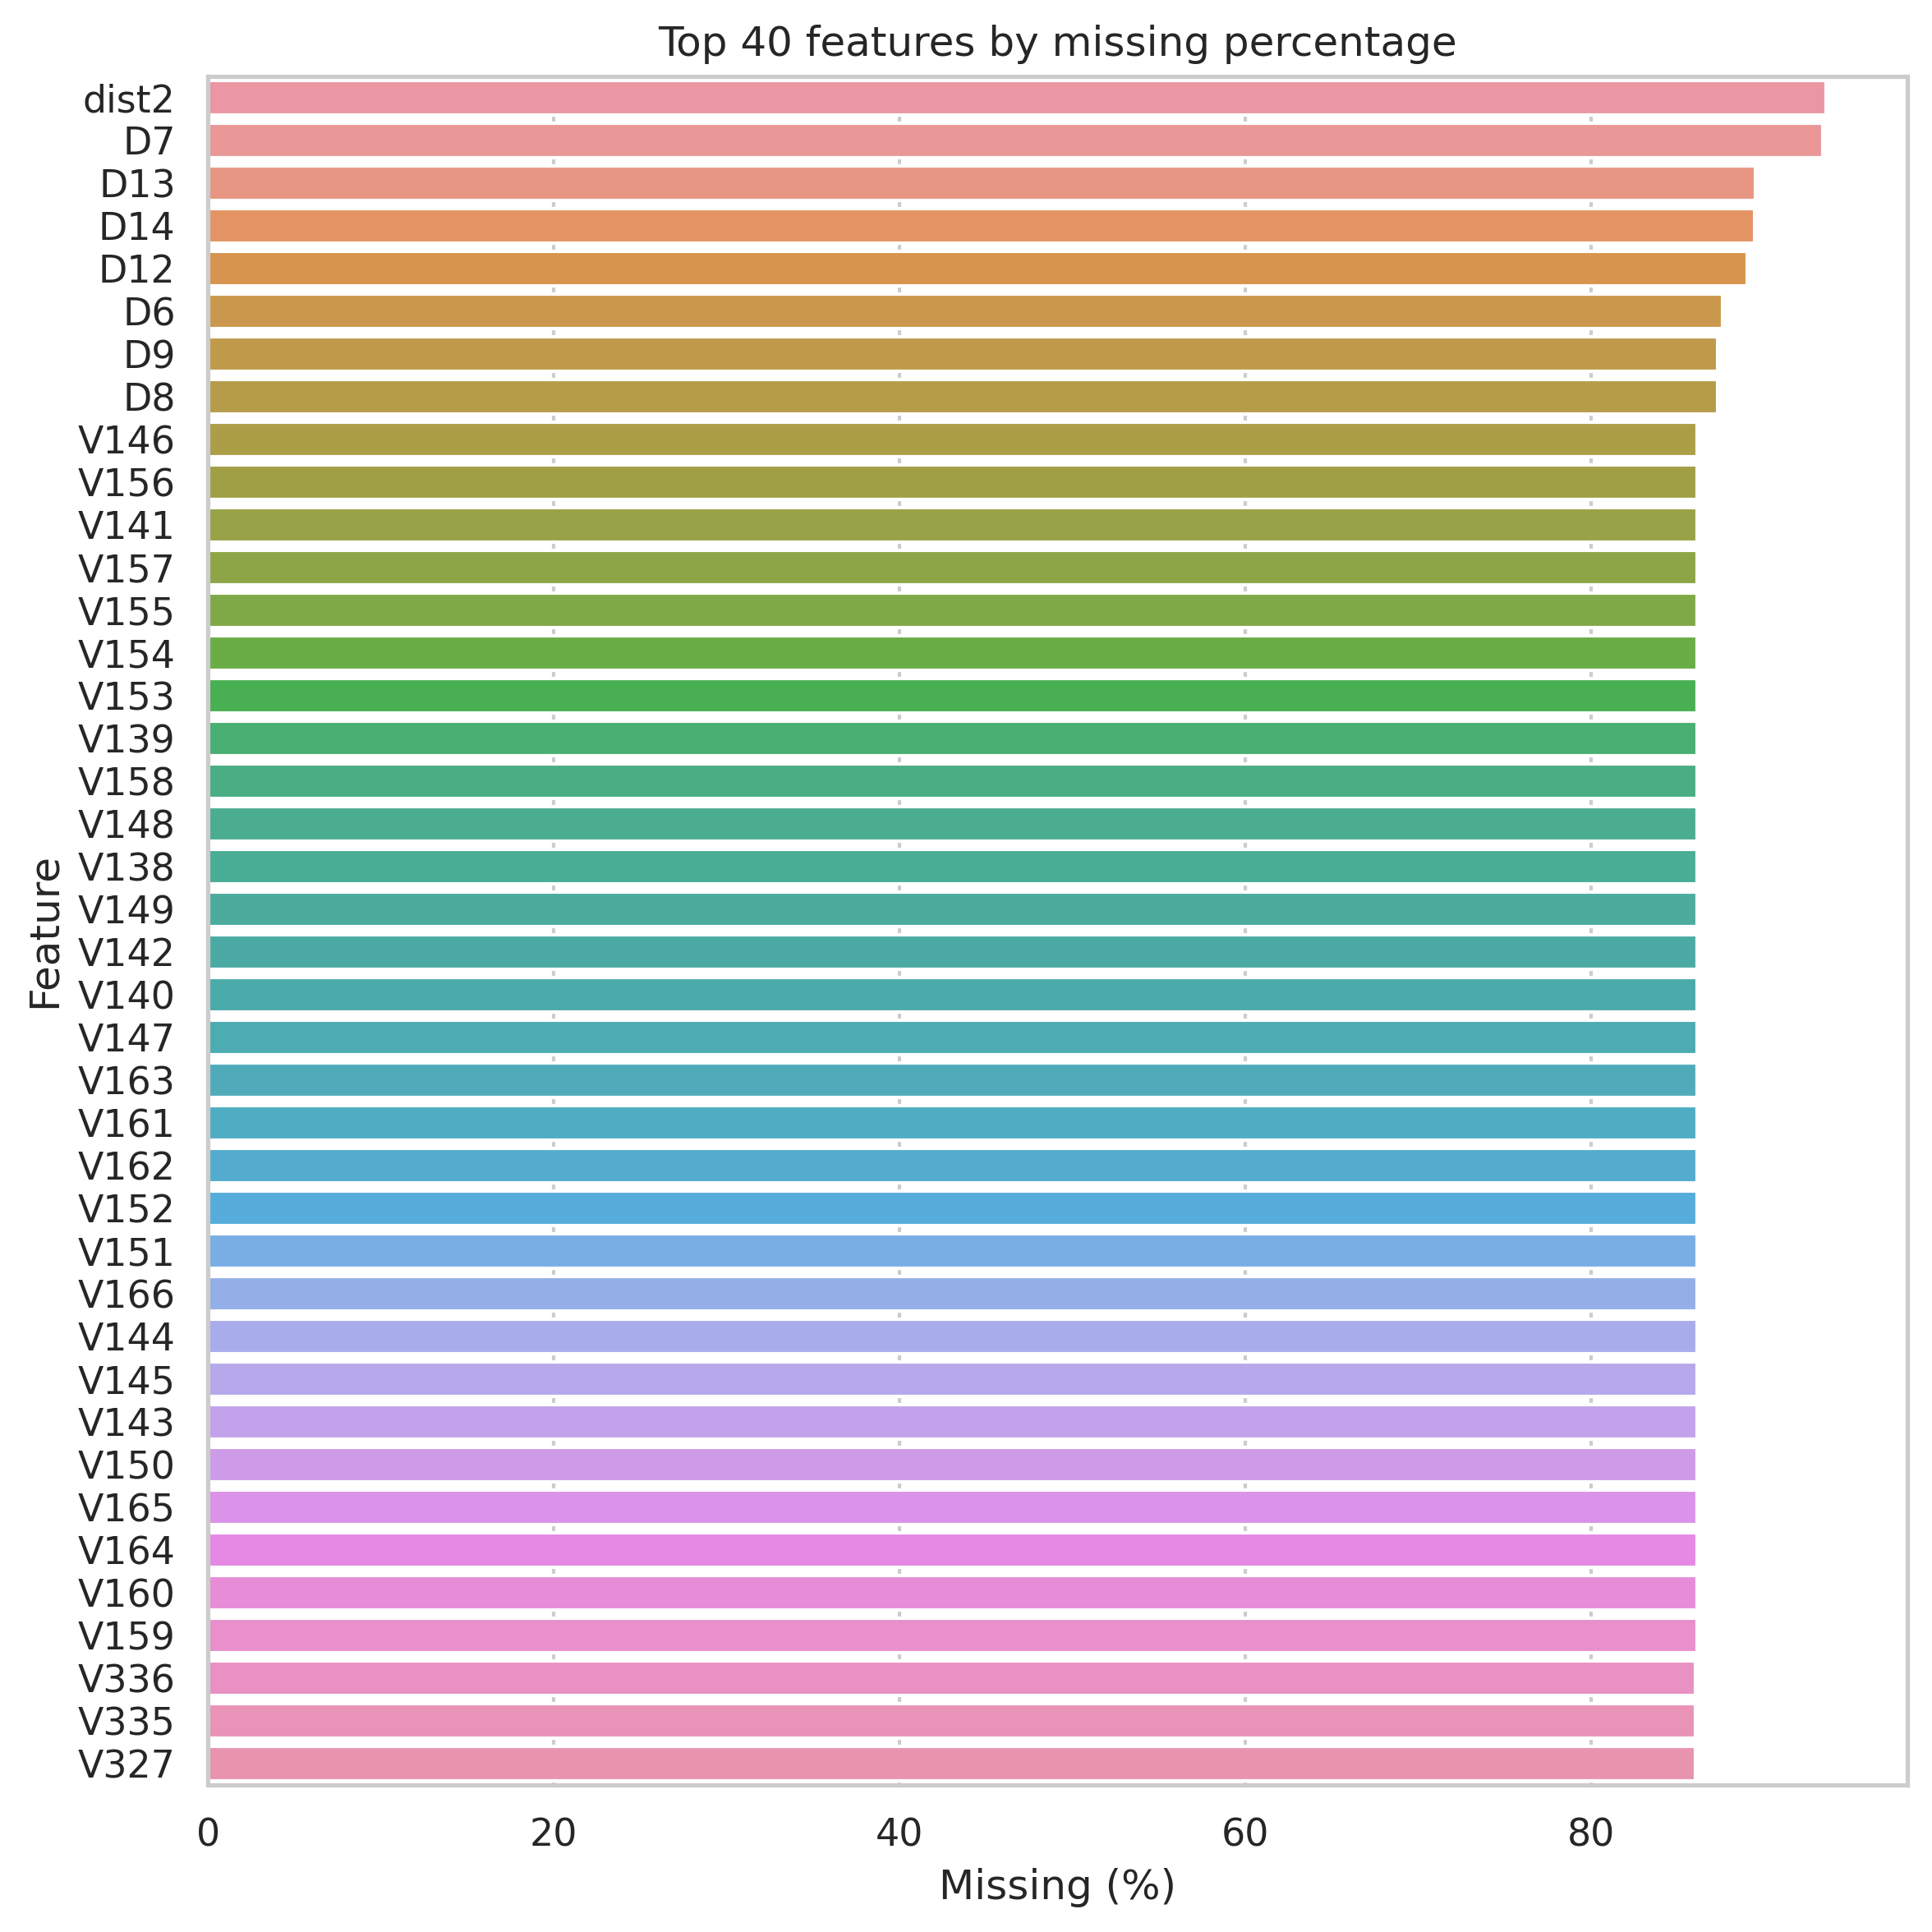

[INFO] Saved figure to: /kaggle/working/fig_eda_missingness_top40.png

Time-based volume and fraud stats (first 20 bins):


,time_bin_day,count,fraud_count,fraud_rate
0,1,"5,122",112,2.1866%
1,2,"3,730",123,3.2976%
2,3,"3,241",92,2.8386%
3,4,"4,036",115,2.8494%
4,5,"3,964",127,3.2038%
5,6,"3,717",99,2.6634%
6,7,"3,786",136,3.5922%
7,8,"3,999",93,2.3256%
8,9,"3,907",119,3.0458%
9,10,"3,445",90,2.6125%


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

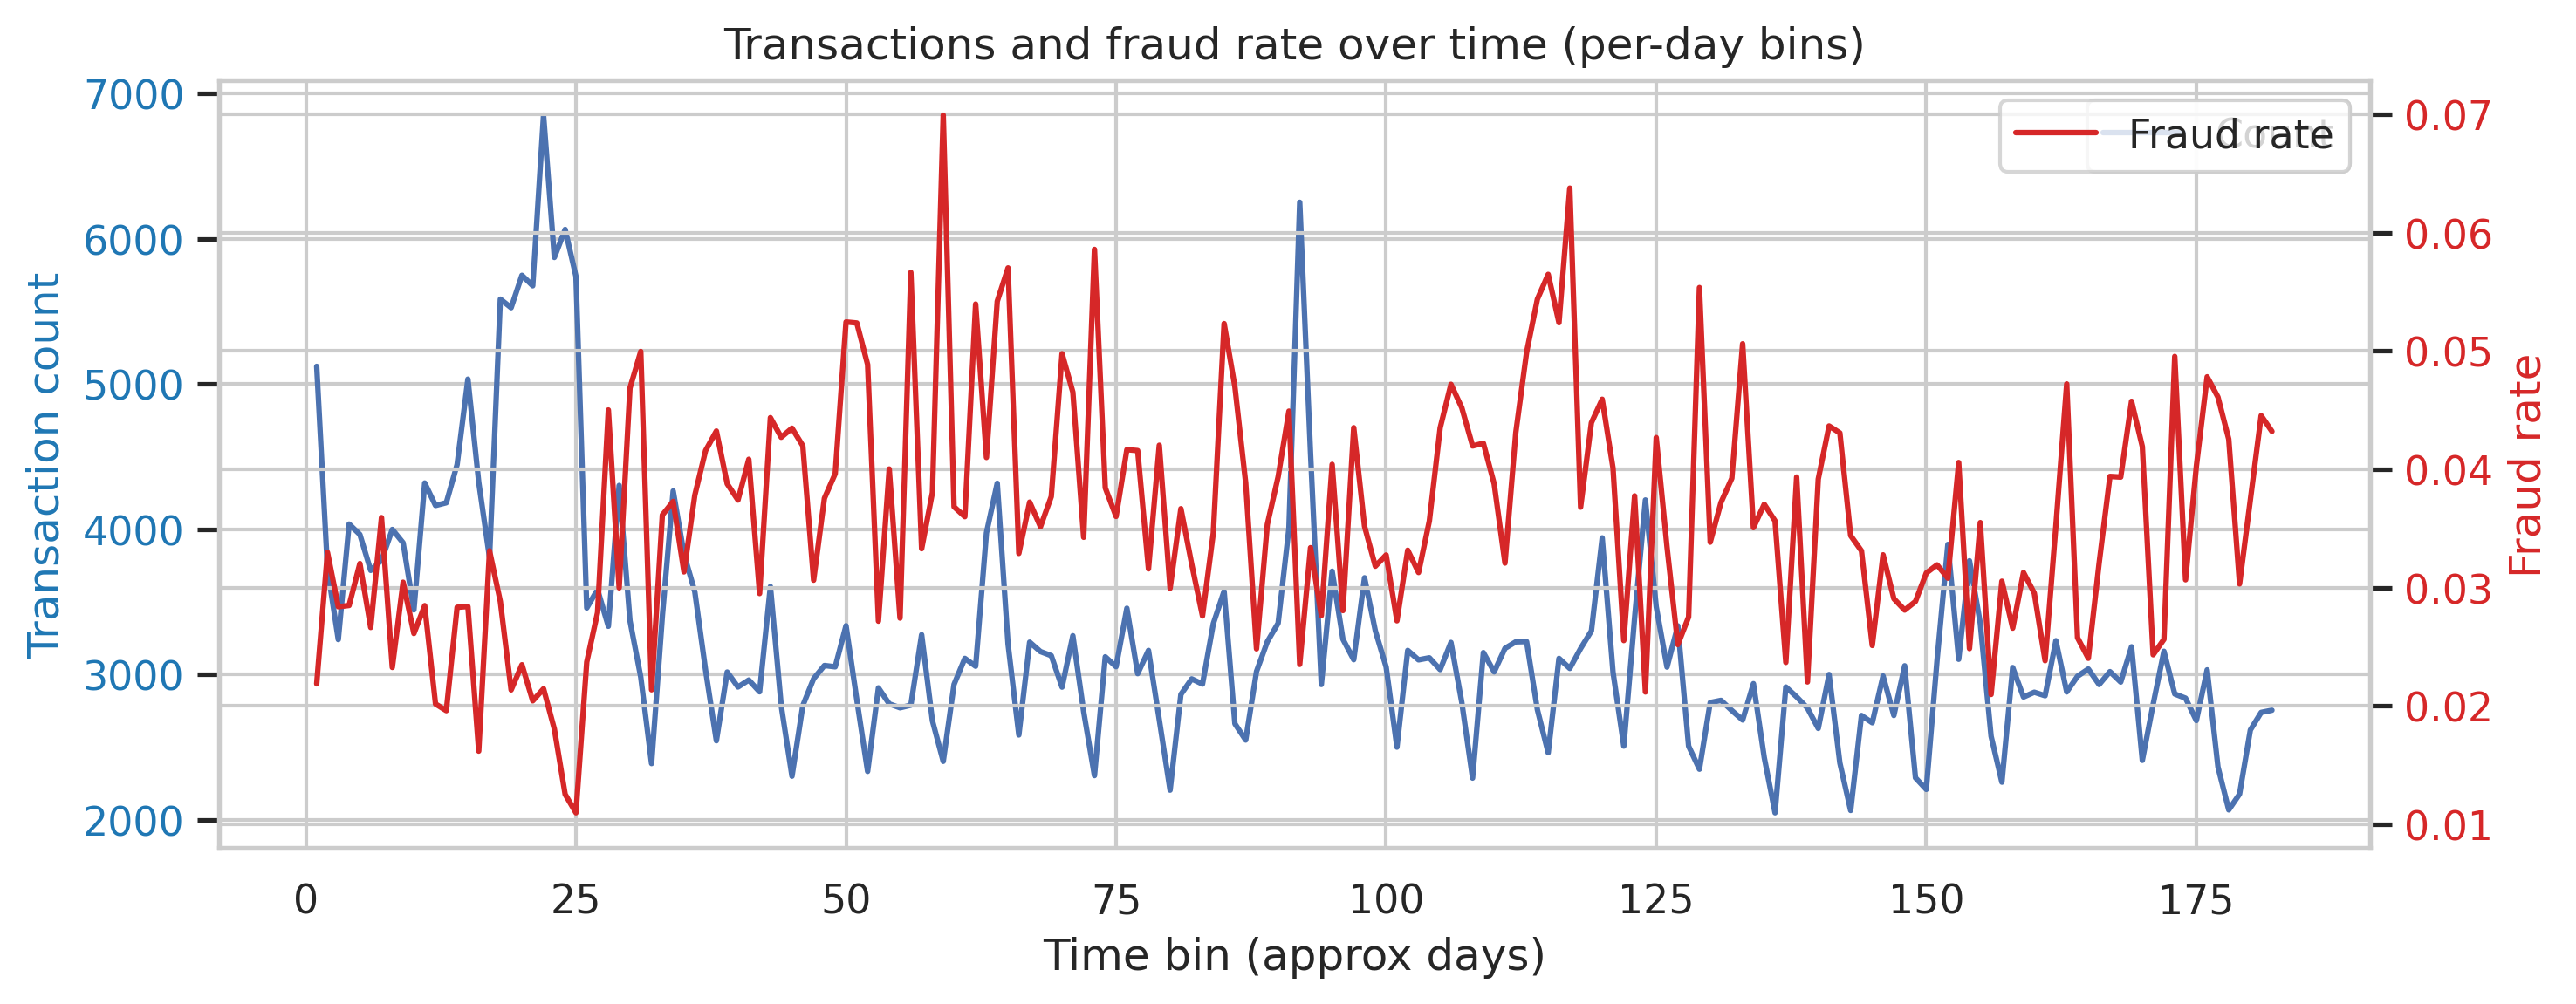

[INFO] Saved figure to: /kaggle/working/fig_eda_time_fraud_per_day.png

TransactionAmt summary (overall):


,count,mean,std,min,25%,50%,75%,max
overall,"590,540.00",135.03,239.16,0.25,43.32,68.77,125.00,"31,937.39"



TransactionAmt summary by isFraud:


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"569,877.00",134.51,239.40,0.25,43.97,68.50,120.00,"31,937.39"
1,"20,663.00",149.24,232.21,0.29,35.04,75.00,161.00,"5,191.00"


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


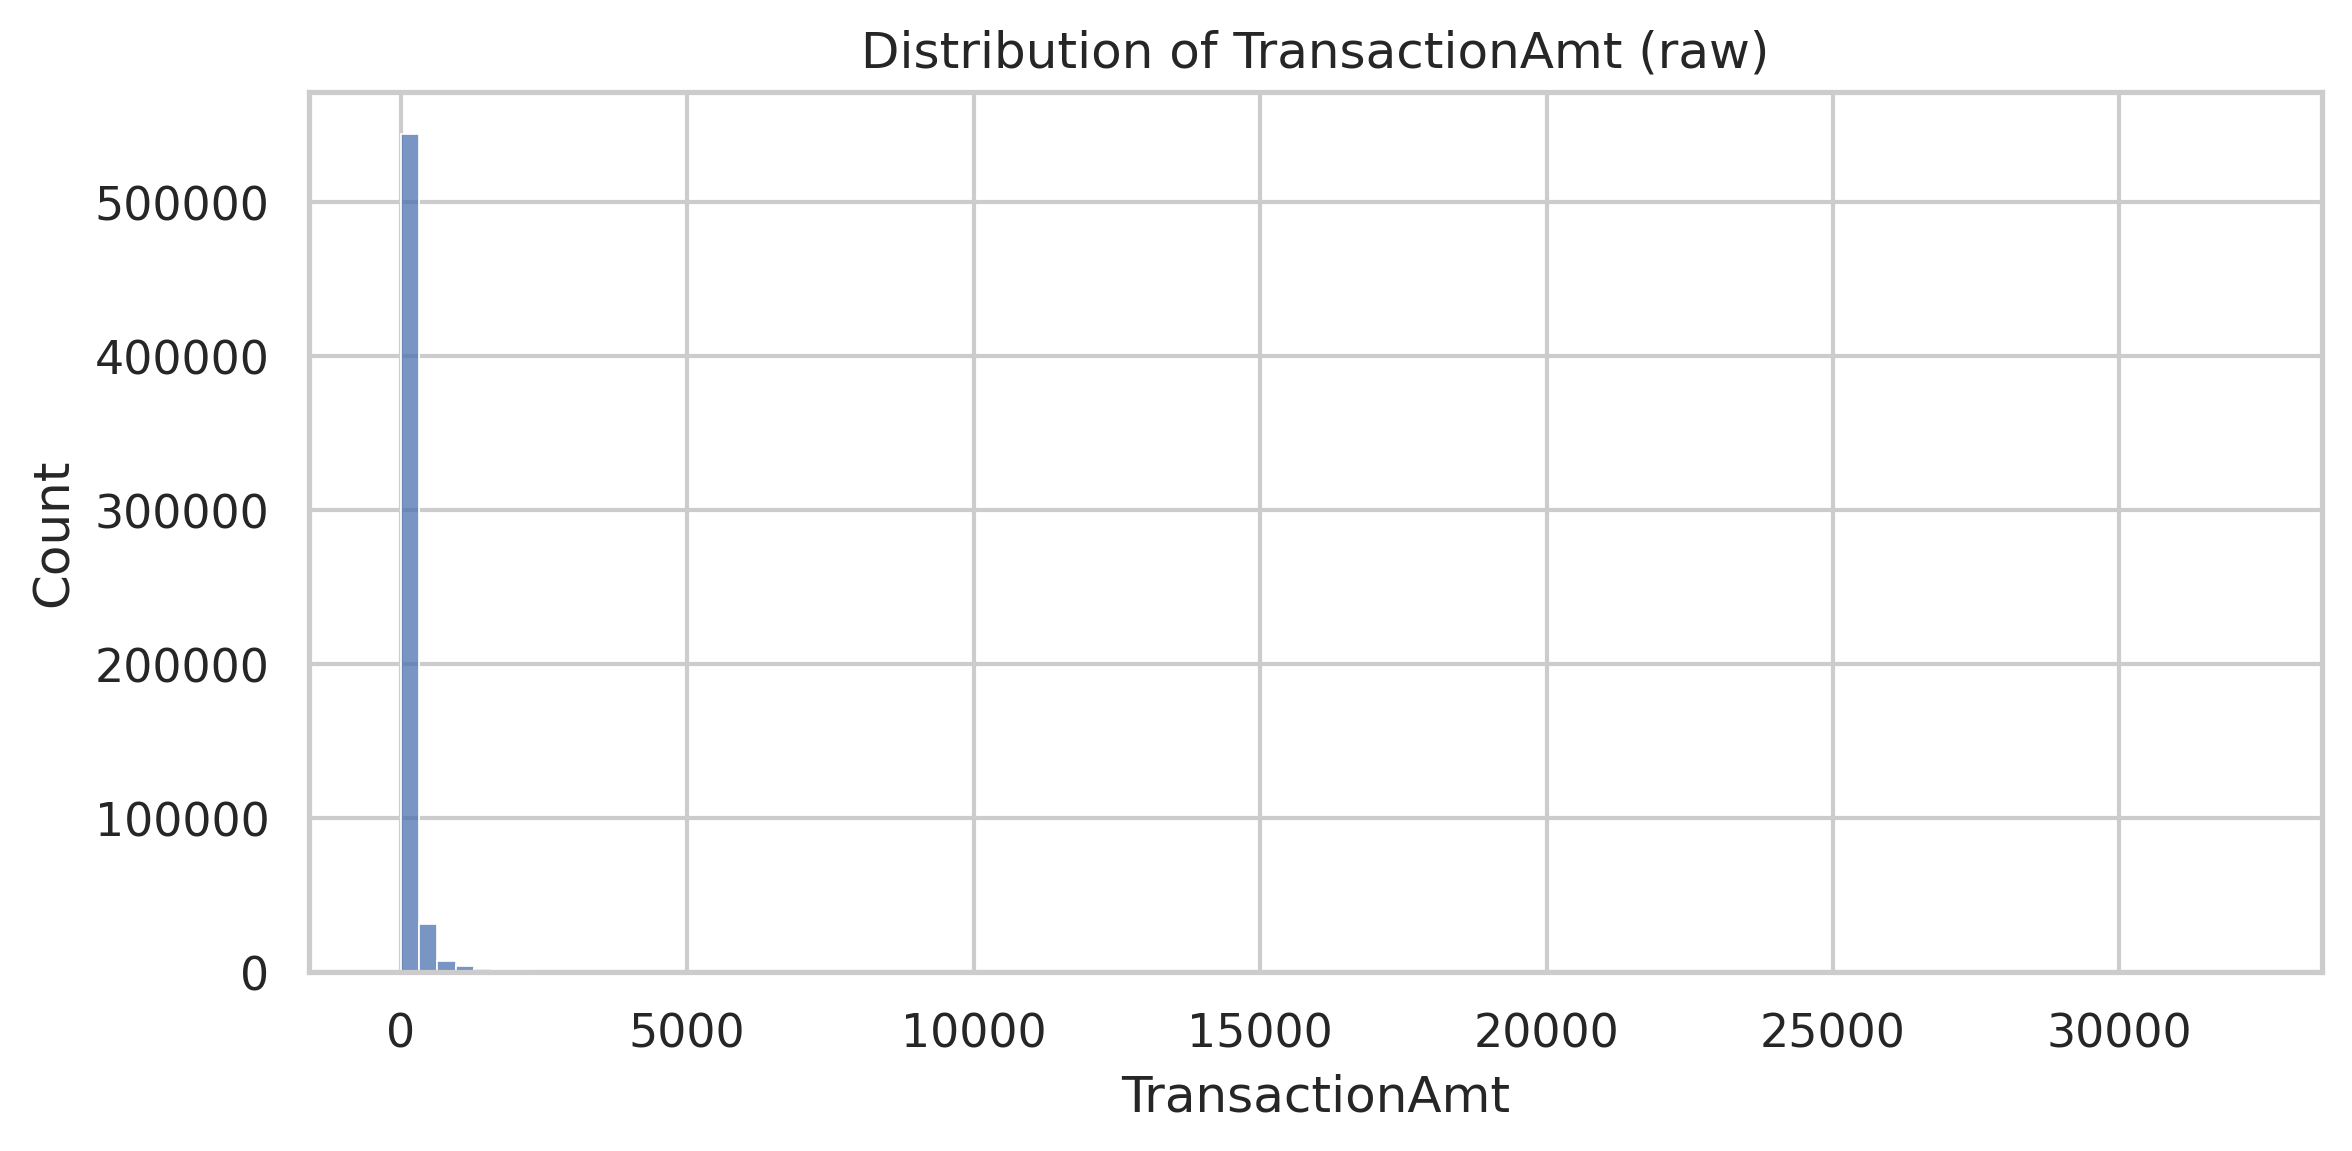

[INFO] Saved figure to: /kaggle/working/fig_eda_txamt_hist_raw.png


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


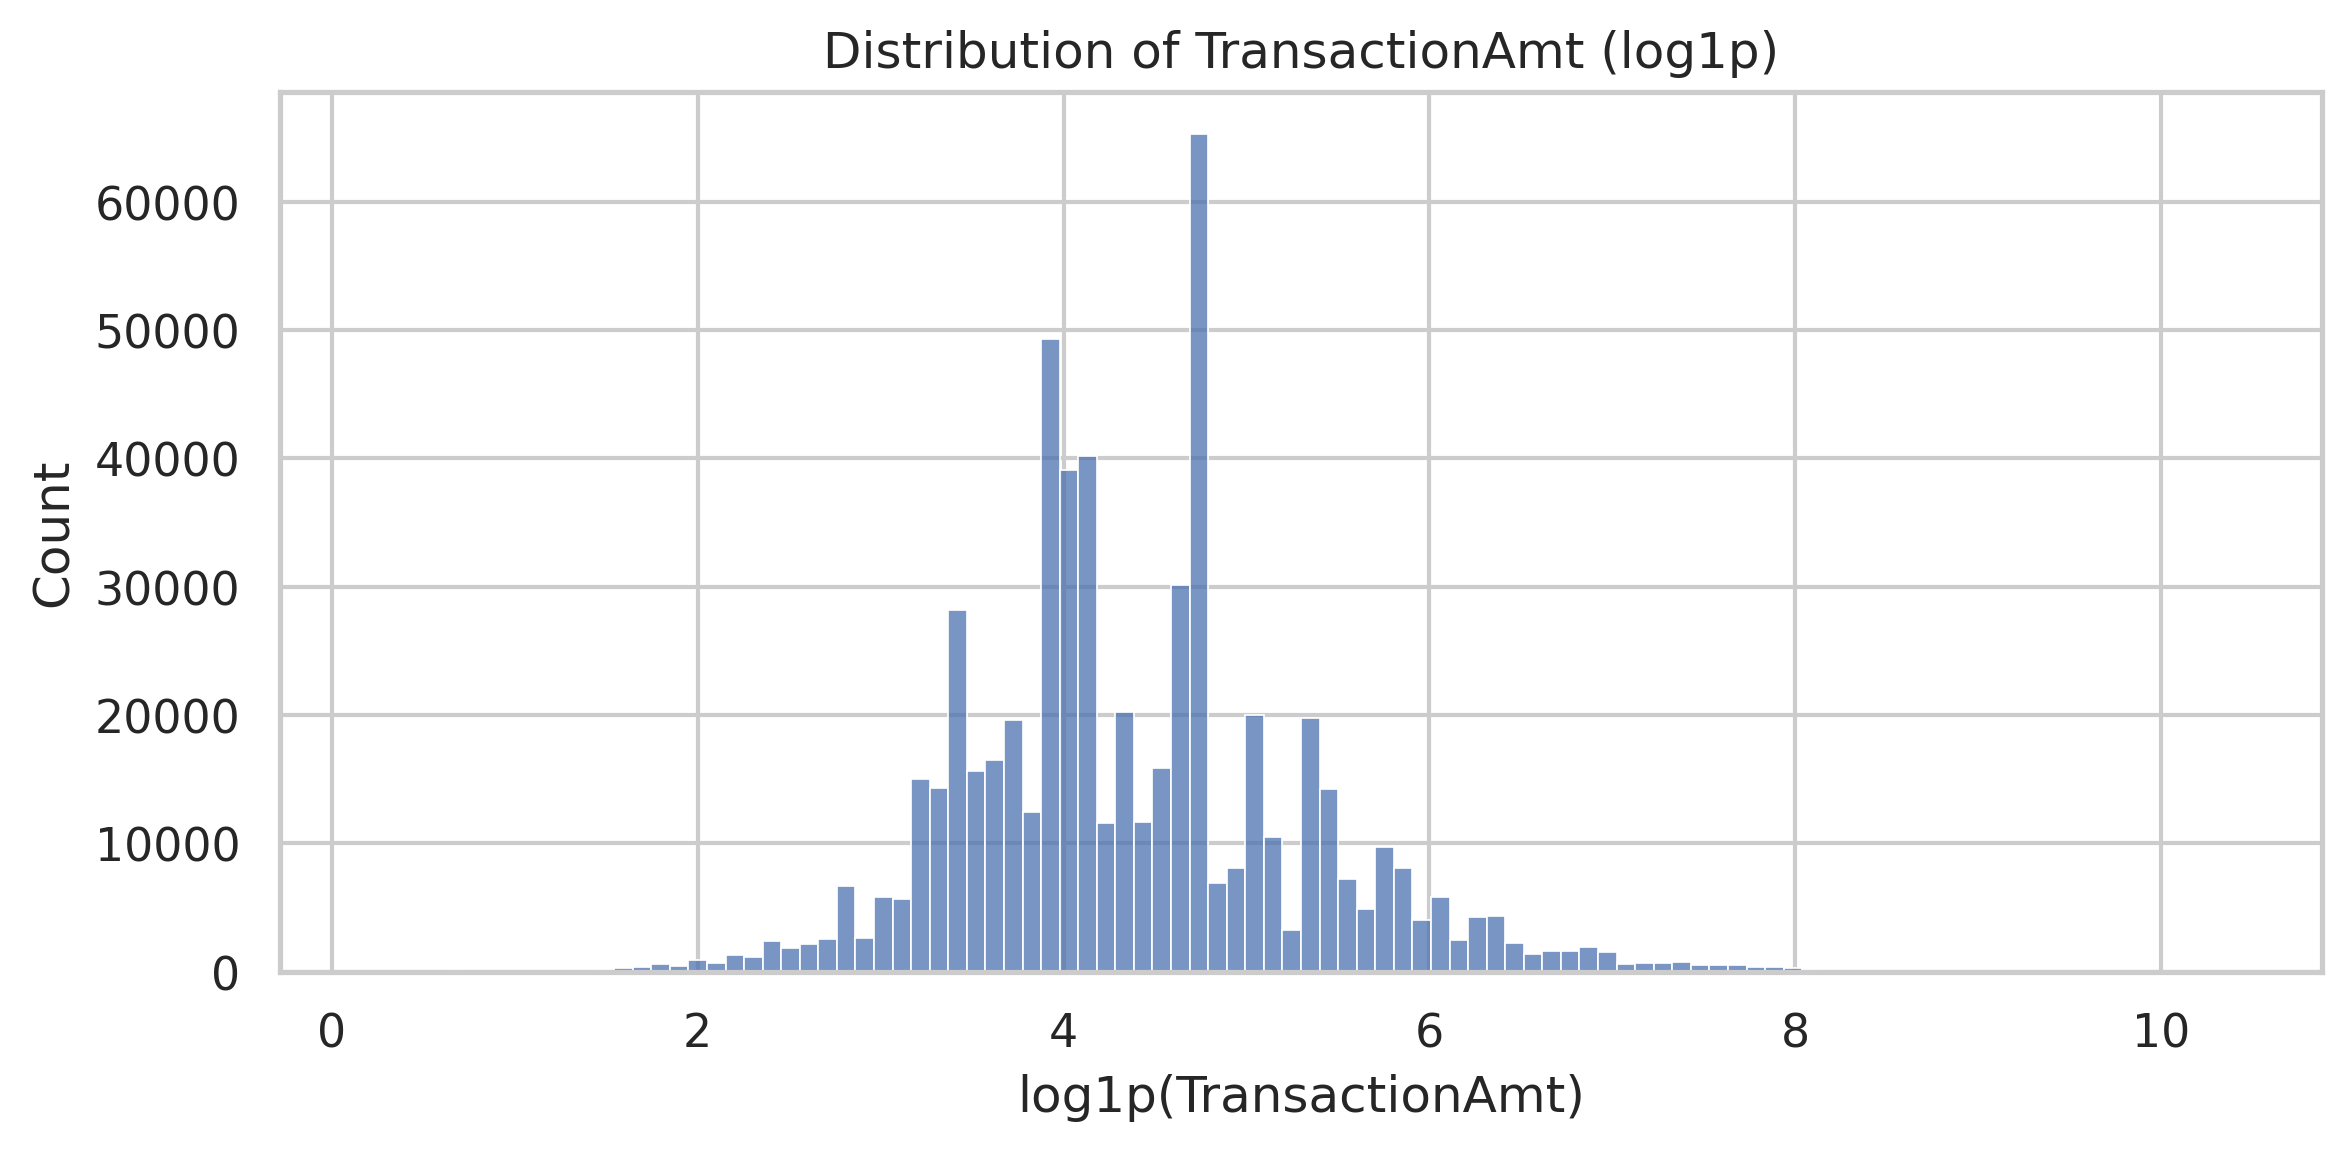

[INFO] Saved figure to: /kaggle/working/fig_eda_txamt_hist_log1p.png


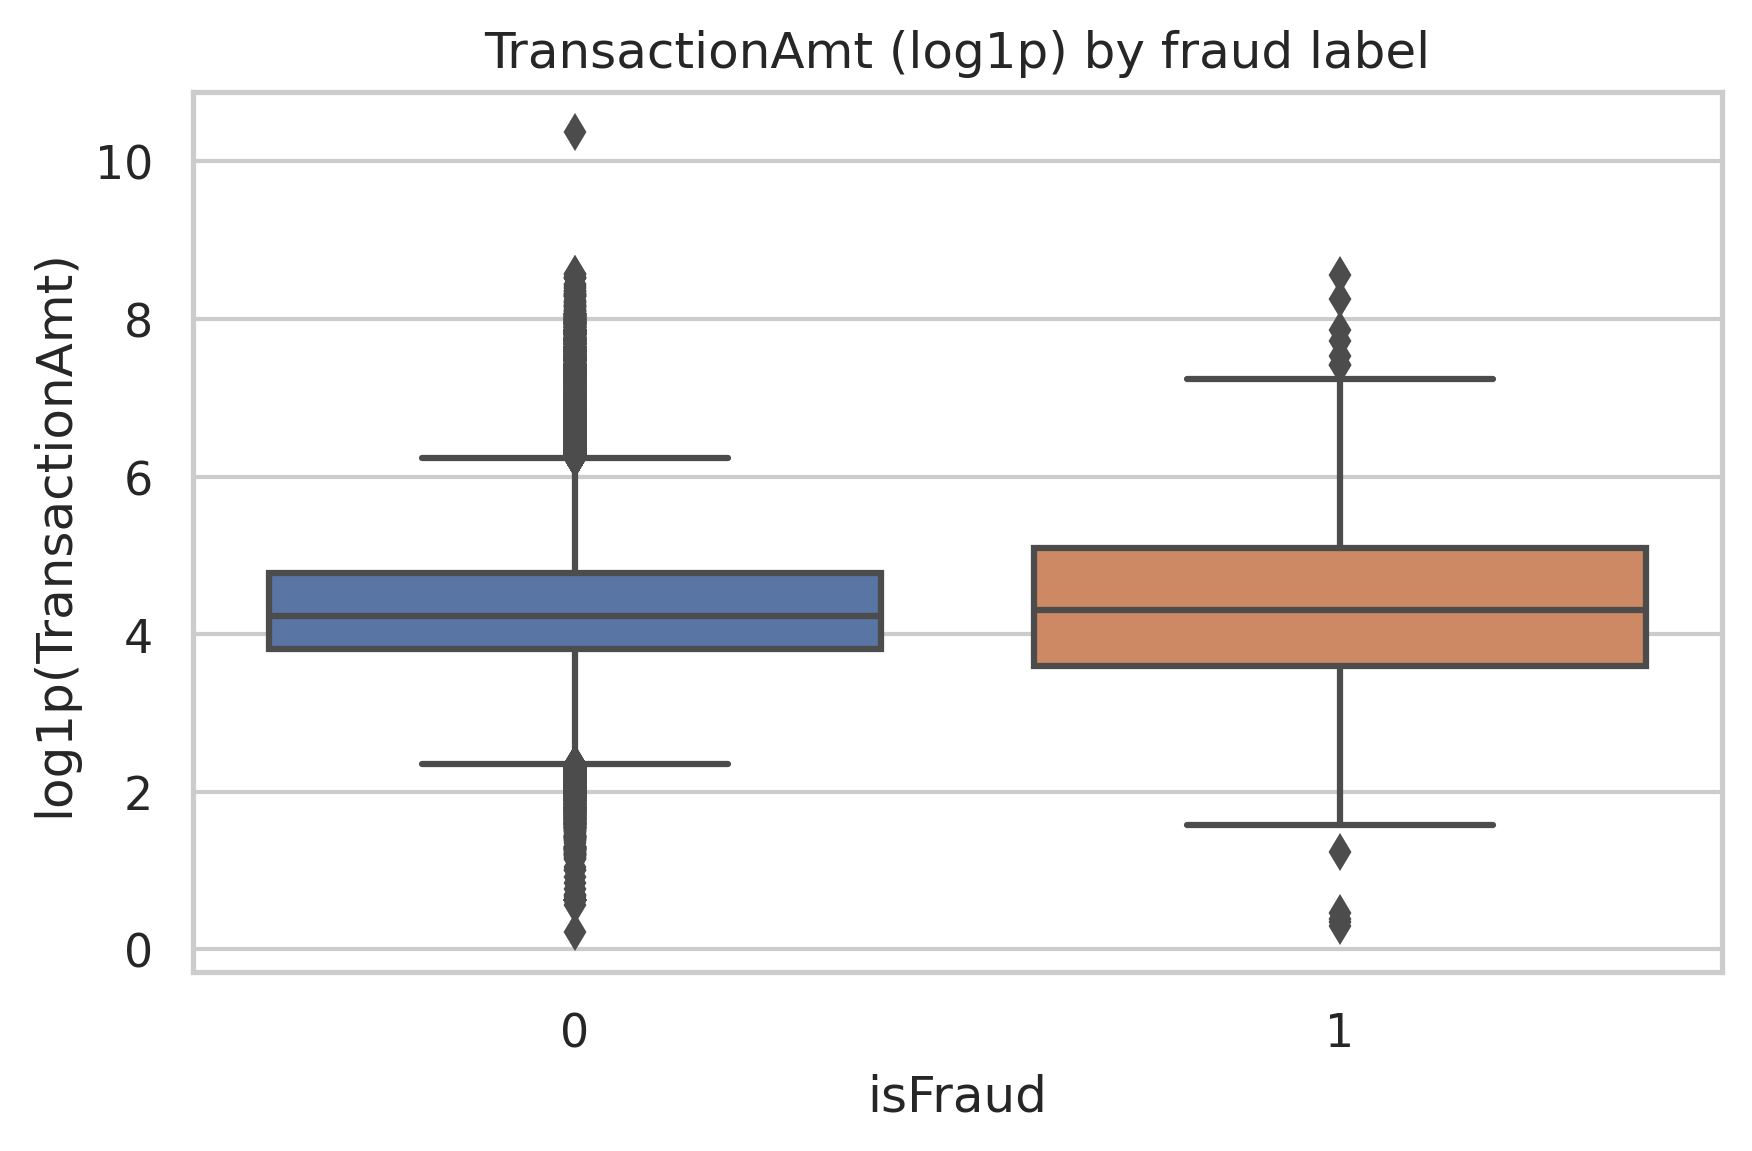

[INFO] Saved figure to: /kaggle/working/fig_eda_txamt_by_fraud_log1p.png

Categorical summary for ProductCD:


,ProductCD,count,fraud_count,fraud_rate
4,W,"439,670","8,969",2.0399%
0,C,"68,519","8,008",11.6873%
2,R,"37,699","1,426",3.7826%
1,H,"33,024","1,574",4.7662%
3,S,"11,628",686,5.8996%


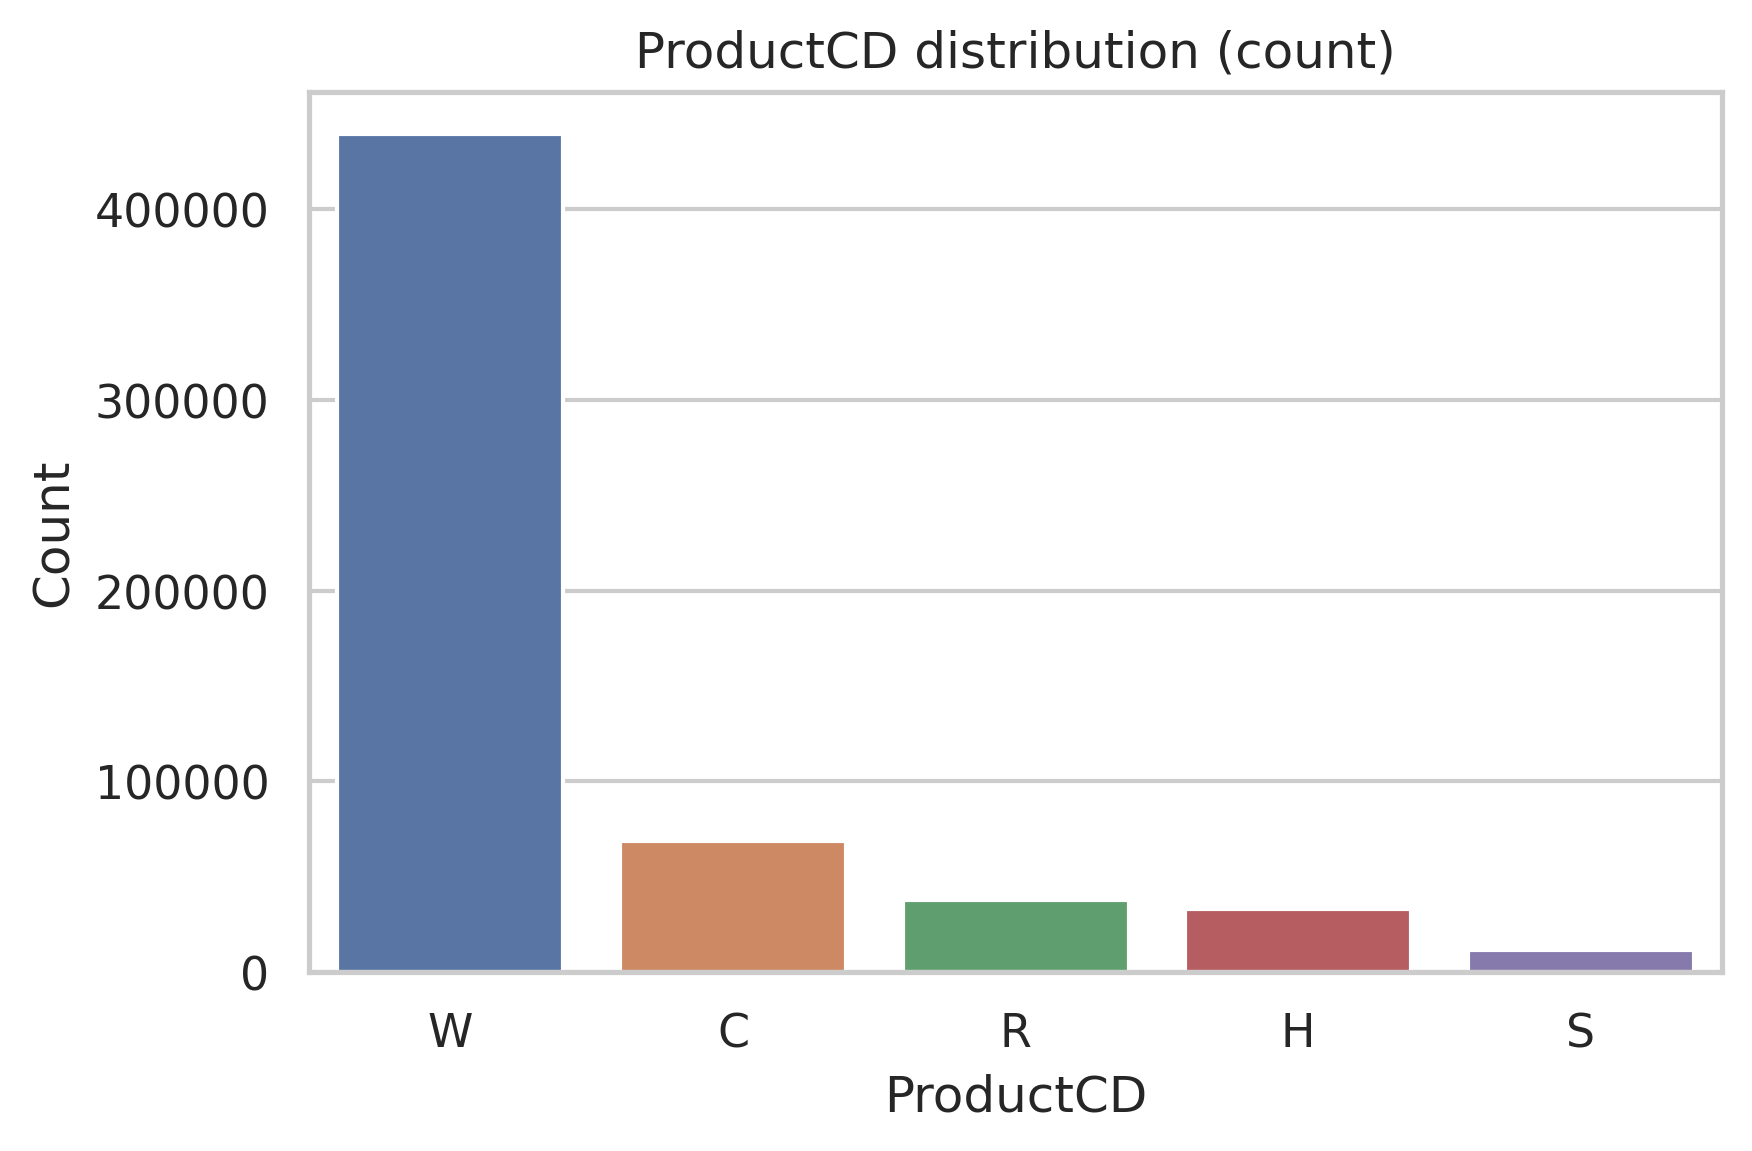

[INFO] Saved figure to: /kaggle/working/fig_eda_ProductCD_count.png

Categorical summary for card4:


,card4,count,fraud_count,fraud_rate
3,visa,"384,767","13,373",3.4756%
2,mastercard,"189,217","6,496",3.4331%
0,american express,"8,328",239,2.8698%
1,discover,"6,651",514,7.7282%


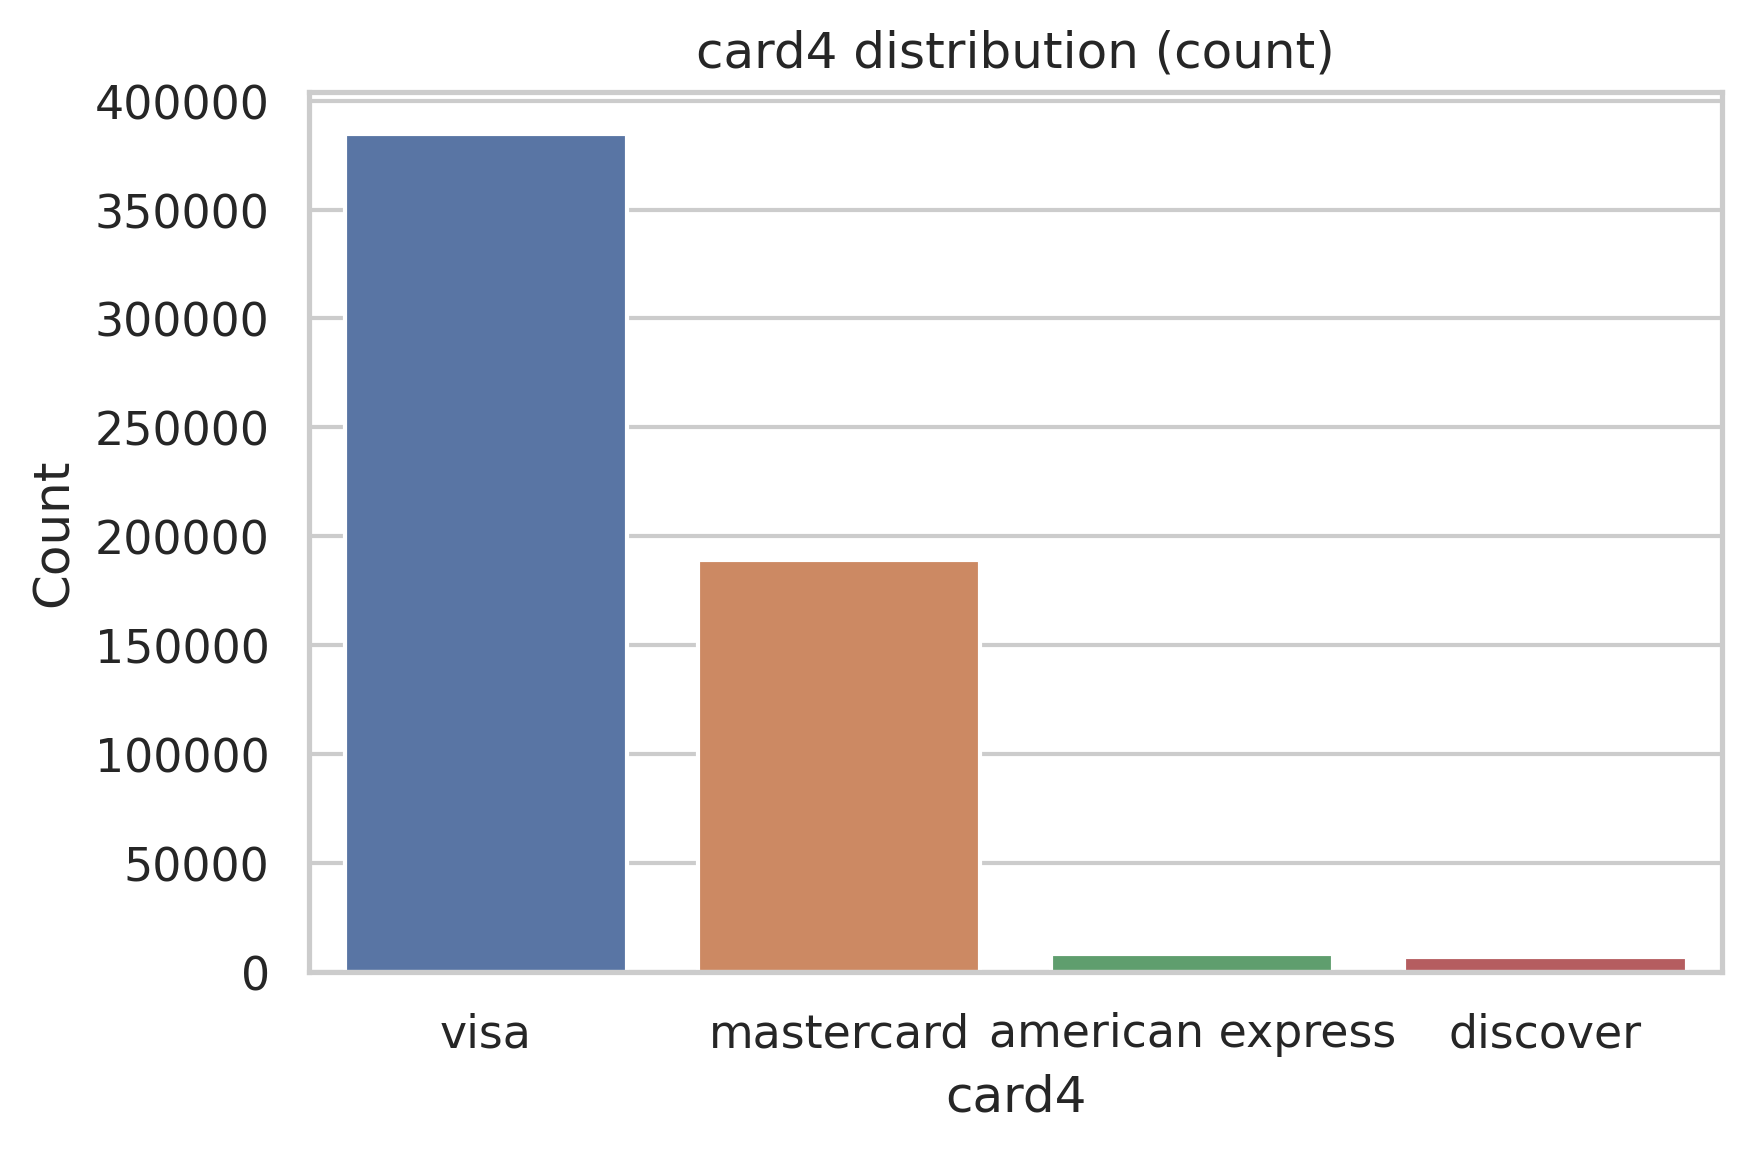

[INFO] Saved figure to: /kaggle/working/fig_eda_card4_count.png

Categorical summary for card6:


,card6,count,fraud_count,fraud_rate
2,debit,"439,938","10,674",2.4263%
1,credit,"148,986","9,950",6.6785%
3,debit or credit,30,0,0.0000%
0,charge card,15,0,0.0000%


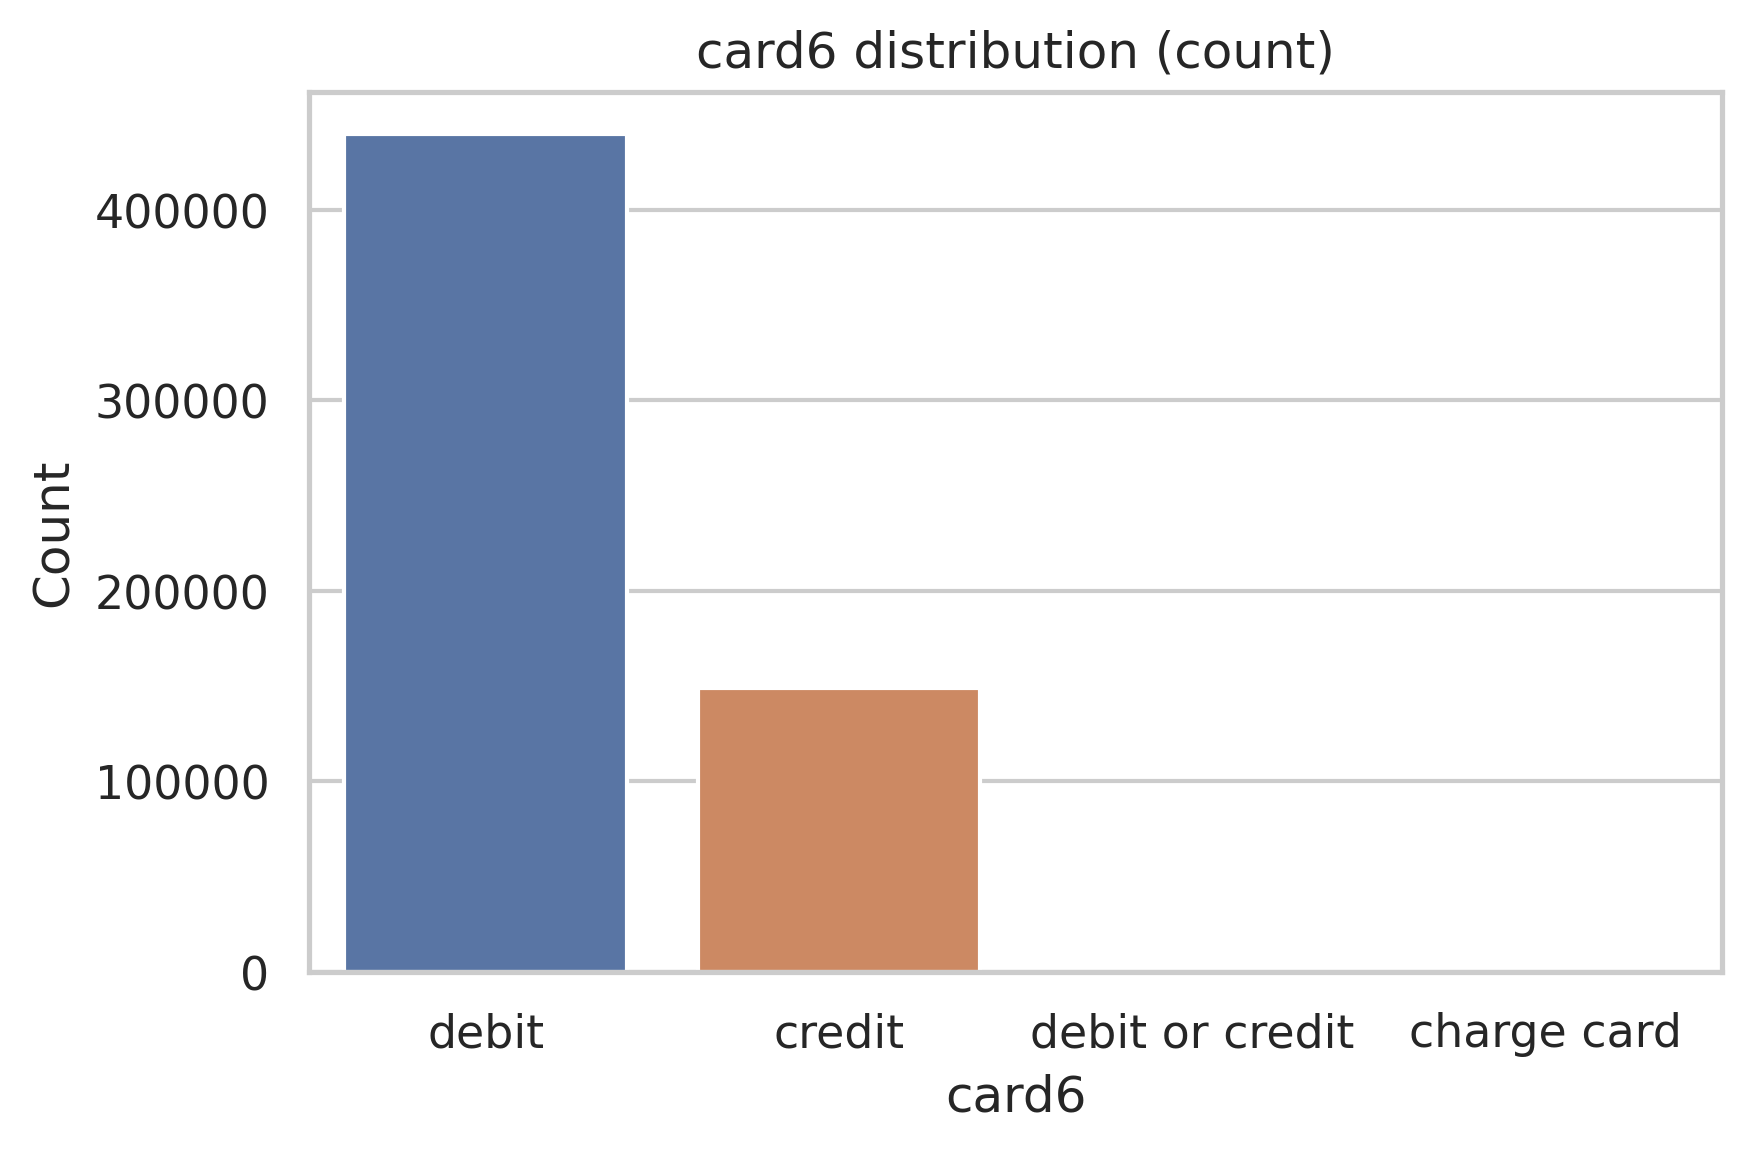

[INFO] Saved figure to: /kaggle/working/fig_eda_card6_count.png

Top 30 card1 by volume:


,card1,count,fraud_count,fraud_rate
5365,7919,"14,932",112,0.7501%
6615,9500,"14,162",528,3.7283%
11593,15885,"10,361",444,4.2853%
12616,17188,"10,344",278,2.6875%
10950,15066,"7,945",313,3.9396%
9143,12695,"7,091",201,2.8346%
9014,12544,"6,773",146,2.1556%
3886,6019,"6,771",294,4.3420%
1412,2803,"6,141",73,1.1887%
5106,7585,"5,334",263,4.9306%


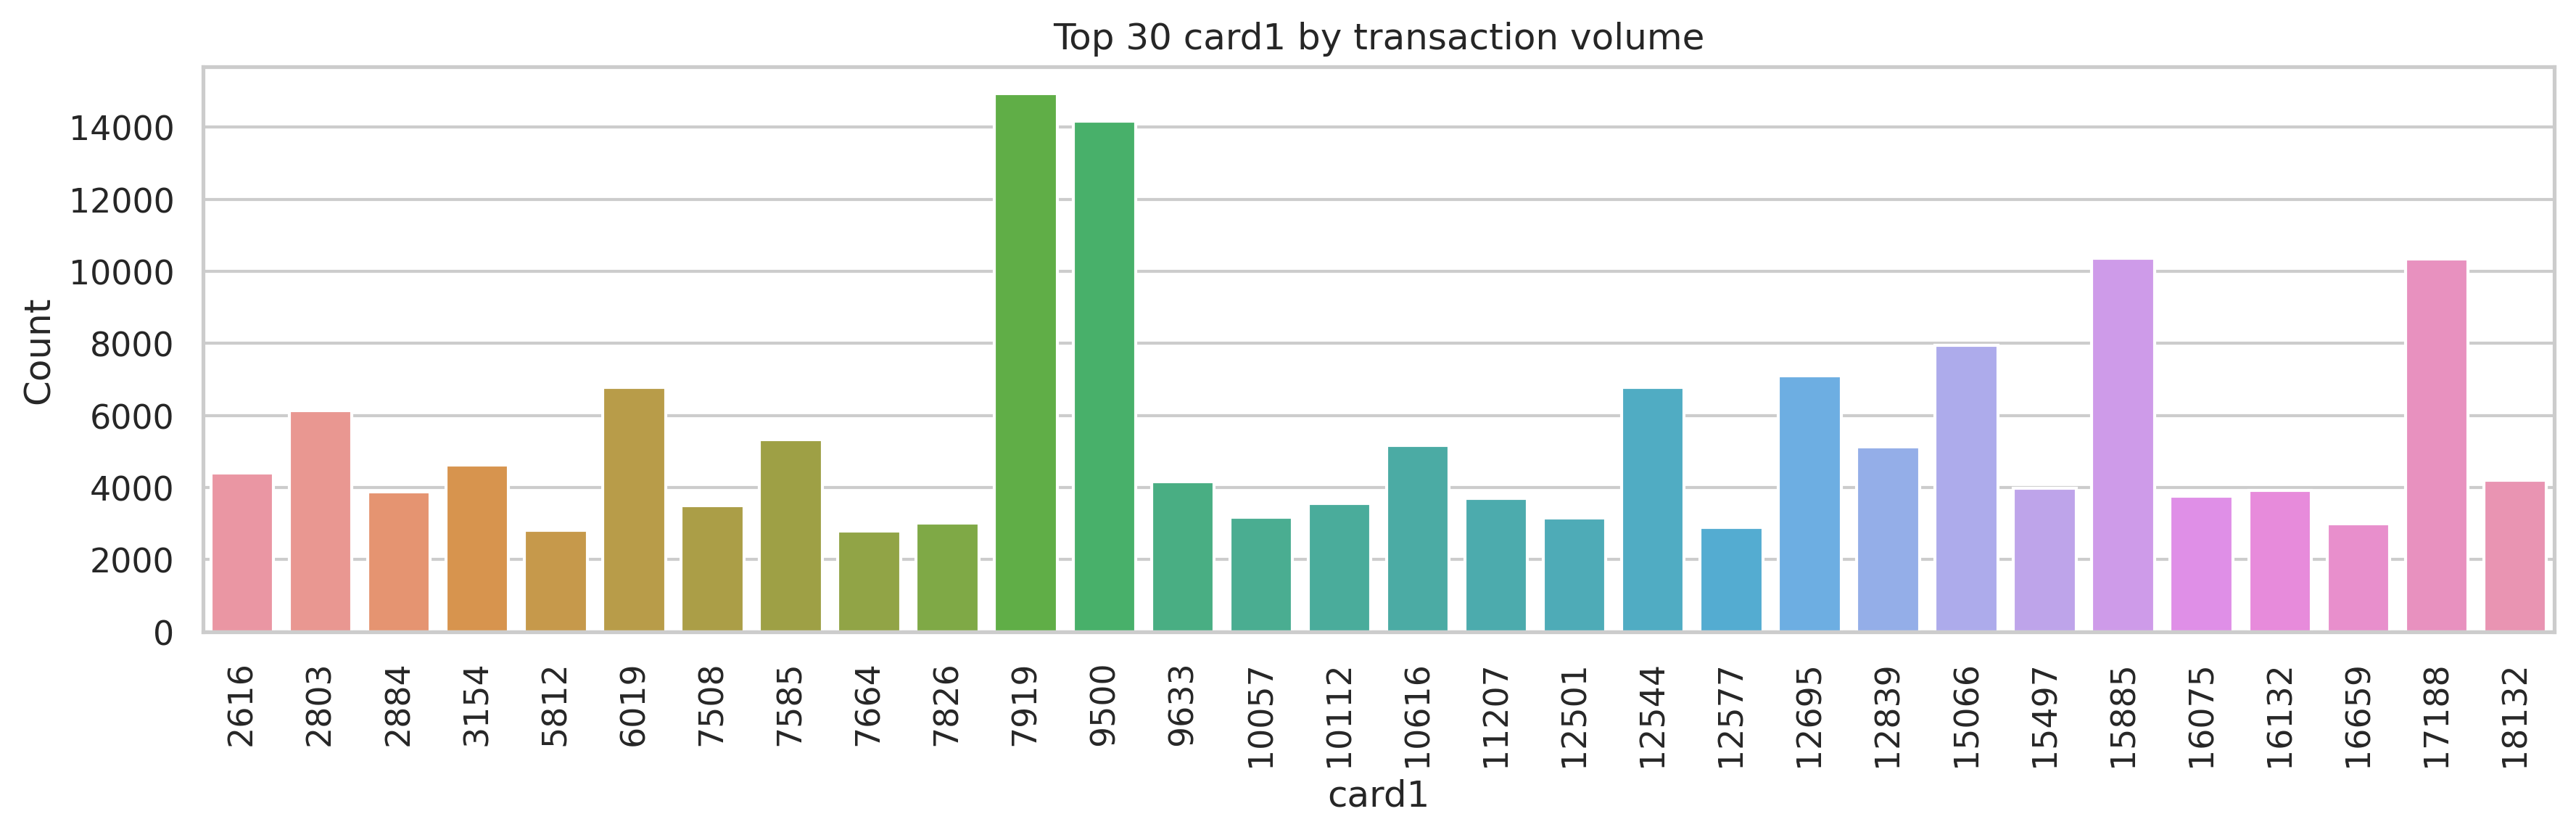

[INFO] Saved figure to: /kaggle/working/fig_eda_card1_top30_count.png

[Drift features] Candidates: 23, Selected (< 5.0% missing): 21


,feature,missing_pct,dtype,group
0,TransactionAmt,0.00,float64,amount
1,TransactionAmt_log1p,0.00,float64,amount
2,C1,0.00,float64,behaviour
3,C2,0.00,float64,behaviour
4,C4,0.00,float64,behaviour
5,C5,0.00,float64,behaviour
6,D1,0.21,float64,behaviour
7,card1,0.00,int64,card
8,card2,1.51,float64,card
9,card3,0.27,float64,card


[INFO] Saved drift_features_selected.csv

Number of selected drift features per group:


,group,num_features
4,v_block,7
2,card,6
1,behaviour,5
0,amount,2
3,other,1


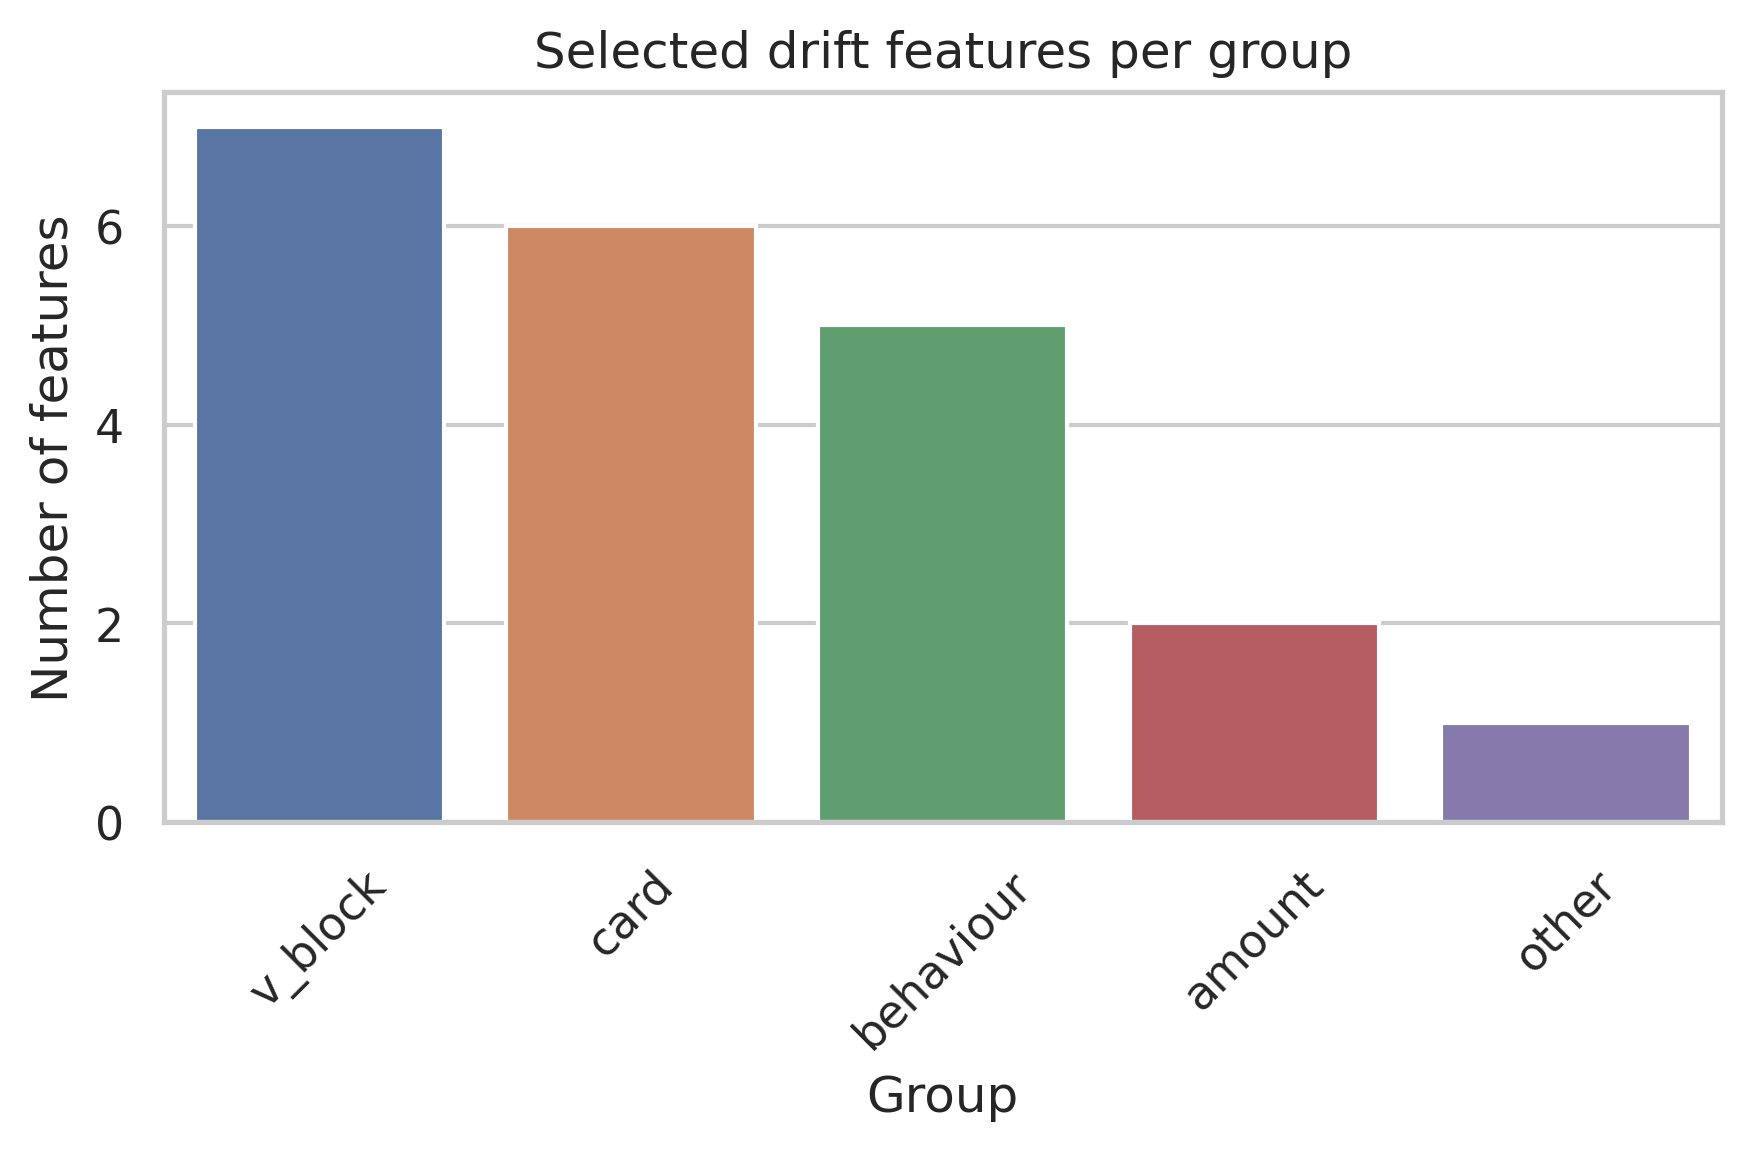

[INFO] Saved figure to: /kaggle/working/fig_drift_features_per_group.png

Global drift events: (14, 19)


,level,card_id,event_id,detector_type,boundary_index,severity,before_start_idx,before_end_idx,after_start_idx,after_end_idx,strong_features,num_strong_features,dominant_feature,combo2,per_feature_scores,group_scores,adwin_flag,ph_flag,stat_flag
0,global,None,0,severity_stream,1,0.544930,10000,30000,30000,50000,"[C1, C2, C4]",3,C2,"(C1, C2)","{'TransactionAmt': 0.0036457437059783425, 'Tra...","{'amount': 0.00606782876615032, 'other': 0.045...",False,False,True
1,global,None,1,severity_stream,2,0.736522,20000,40000,40000,60000,"[C1, C2, C4]",3,C2,"(C1, C2)","{'TransactionAmt': 0.0022966044140317996, 'Tra...","{'amount': 0.008634001846605866, 'other': 0.03...",False,False,True
2,global,None,2,severity_stream,3,0.727169,30000,50000,50000,70000,"[C1, C2, C4]",3,C2,"(C1, C2)","{'TransactionAmt': 0.002004702537656597, 'Tran...","{'amount': 0.004824770693181489, 'other': 0.02...",False,False,True
3,global,None,3,severity_stream,4,0.710155,40000,60000,60000,80000,"[C1, C2, C4]",3,C2,"(C1, C2)","{'TransactionAmt': 0.0025724316916948342, 'Tra...","{'amount': 0.005820220291244315, 'other': 0.03...",False,False,True
4,global,None,4,severity_stream,5,0.528936,50000,70000,70000,90000,"[C1, C2, C4]",3,C2,"(C1, C2)","{'TransactionAmt': 0.0036888138758260514, 'Tra...","{'amount': 0.015983333624874356, 'other': 0.07...",False,False,True



Global boundary scores (first 10):


,boundary_index,severity,before_start_idx,before_end_idx,after_start_idx,after_end_idx,adwin_flag,ph_flag,stat_flag
0,0,0.293010,0,20000,20000,40000,False,False,False
1,1,0.544930,10000,30000,30000,50000,False,False,True
2,2,0.736522,20000,40000,40000,60000,False,False,True
3,3,0.727169,30000,50000,50000,70000,False,False,True
4,4,0.710155,40000,60000,60000,80000,False,False,True
5,5,0.528936,50000,70000,70000,90000,False,False,True
6,6,0.101882,60000,80000,80000,100000,False,False,False
7,7,0.060154,70000,90000,90000,110000,False,False,False
8,8,0.076431,80000,100000,100000,120000,False,False,False
9,9,0.113386,90000,110000,110000,130000,False,False,False



Summary of global boundary severities:


,count,mean,std,min,25%,50%,75%,max
severity,56.0,0.232403,0.279403,0.012585,0.024482,0.062227,0.532935,0.817499


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


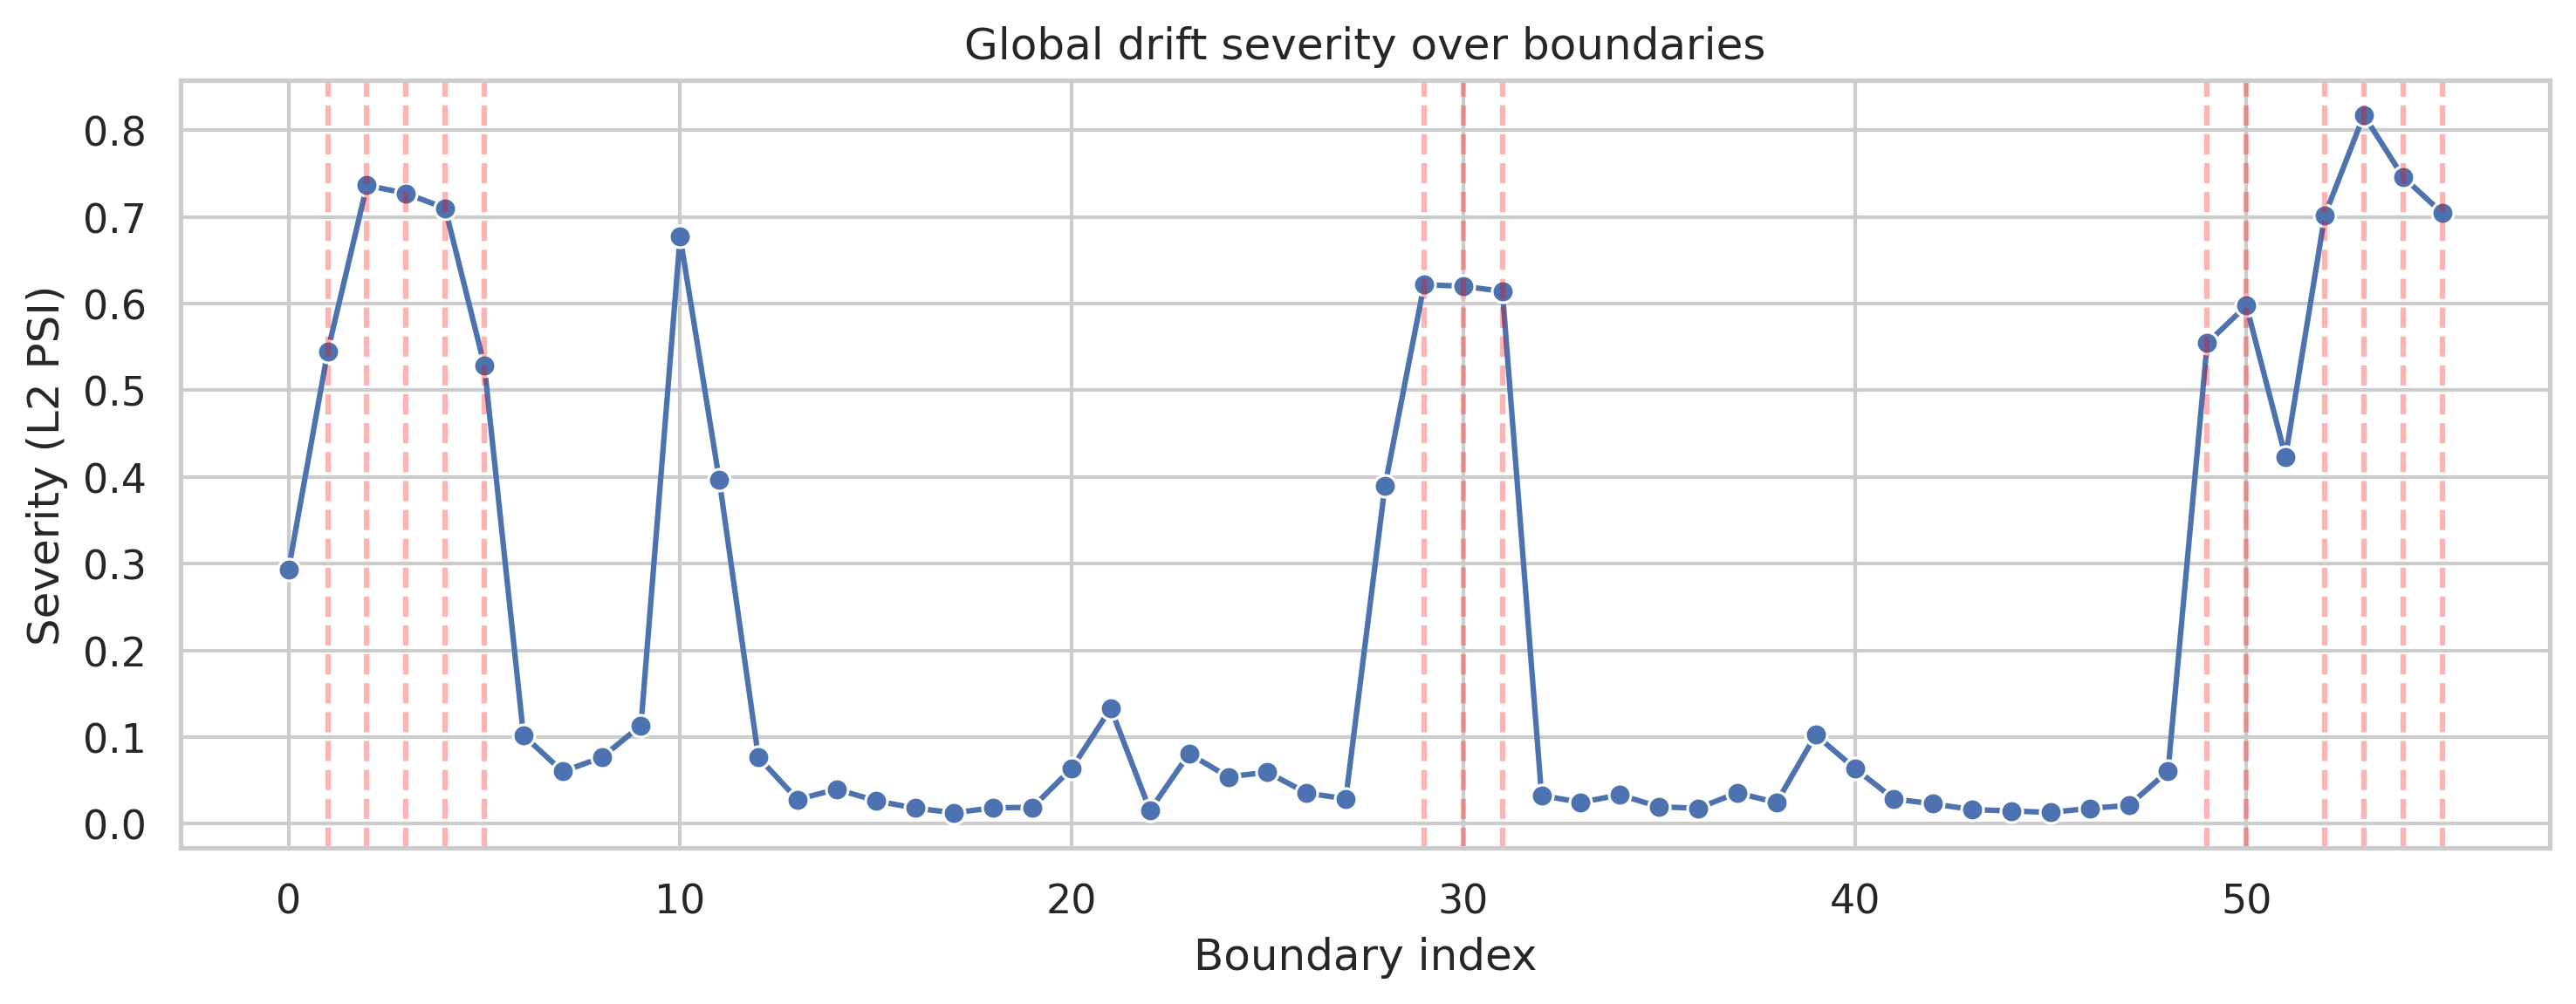

[INFO] Saved figure to: /kaggle/working/fig_global_severity_timeline.png

Local drift: analysing 50 cards with >= 500 tx each.

Local drift events: (1935, 20)


,level,card_id,event_id,local_boundary_index,severity,local_before_start,local_before_end,local_after_start,local_after_end,global_after_start_idx,global_after_end_idx,strong_features,num_strong_features,dominant_feature,combo2,per_feature_scores,group_scores,adwin_flag,ph_flag,stat_flag
0,local,7919,0,0,8.724985,0,200,200,400,1652,3397,"[TransactionAmt, TransactionAmt_log1p, card5, ...",11,card5,"(C5, card5)","{'TransactionAmt': 0.31963057651454896, 'Trans...","{'amount': 0.4609973342470881, 'other': 0.0, '...",False,False,True
1,local,7919,1,1,3.845190,100,300,300,500,2547,4362,"[TransactionAmt, card5, C1, C5, V96, V306, V30...",8,card5,"(V312, card5)","{'TransactionAmt': 0.2599427683941648, 'Transa...","{'amount': 0.3049817641761838, 'other': 0.0426...",False,False,True
2,local,7919,2,2,1.053507,200,400,400,600,3438,5420,"[TransactionAmt, TransactionAmt_log1p, card5, ...",8,card5,"(V306, card5)","{'TransactionAmt': 0.20576143426789487, 'Trans...","{'amount': 0.28721111261877896, 'other': 0.144...",False,False,True
3,local,7919,3,3,1.132473,300,500,500,700,4377,6559,"[card5, C1, C2, C5, V306, V307, V312]",7,C5,"(C1, C5)","{'TransactionAmt': 0.1606154502004961, 'Transa...","{'amount': 0.17411917537864546, 'other': 0.046...",False,False,True
4,local,7919,4,4,0.859599,400,600,600,800,5423,8185,"[TransactionAmt, TransactionAmt_log1p, C2, C5,...",7,TransactionAmt,"(C5, TransactionAmt)","{'TransactionAmt': 0.39145697812534885, 'Trans...","{'amount': 0.485875096921155, 'other': 0.18690...",False,False,True



Local drift events per card (top 30):


,card_id,num_events
0,7919,146
1,9500,138
2,15885,100
3,17188,100
4,15066,76
5,12695,67
6,12544,64
7,6019,64
8,2803,58
9,7585,50


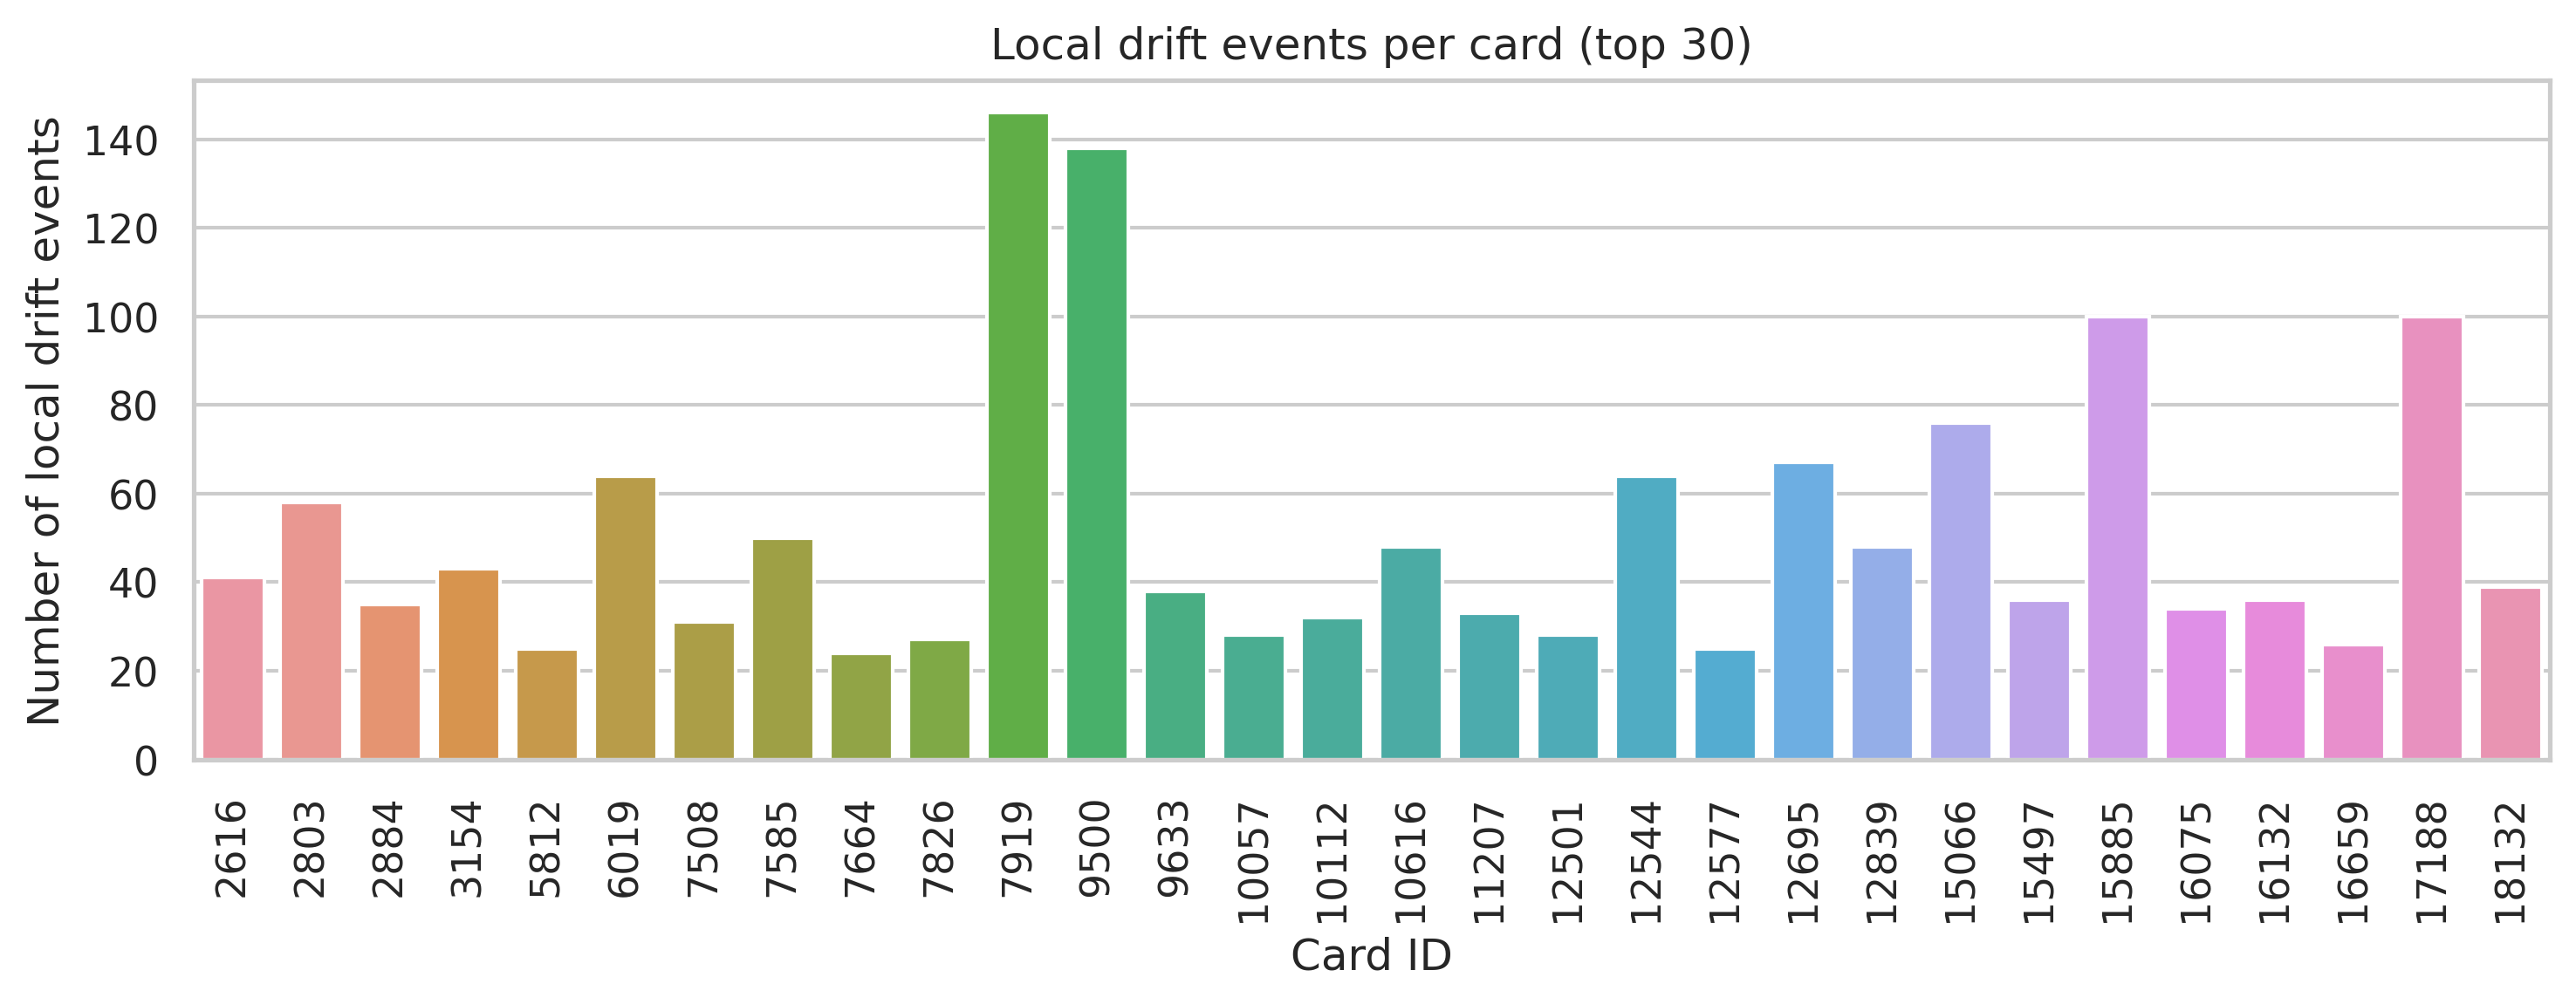

[INFO] Saved figure to: /kaggle/working/fig_local_events_per_card_top30.png

[global + uni] No events.

[global + multi] Number of events: 14


,event_id,severity,boundary_index,card_id,dominant_feature,num_strong_features,adwin_flag,ph_flag,stat_flag
0,0,0.544930,1,None,C2,3,False,False,True
1,1,0.736522,2,None,C2,3,False,False,True
2,2,0.727169,3,None,C2,3,False,False,True
3,3,0.710155,4,None,C2,3,False,False,True
4,4,0.528936,5,None,C2,3,False,False,True
5,5,0.621945,29,None,card6,2,False,False,True
6,6,0.620035,30,None,card6,2,False,True,True
7,7,0.614264,31,None,card6,2,False,False,True
8,8,0.554518,49,None,card6,2,False,False,True
9,9,0.597668,50,None,card6,2,False,False,True



[global + multi] Feature-wise summary:


,feature,num_events,mean_abs_psi
0,TransactionAmt,14,0.002822
1,TransactionAmt_log1p,14,0.006671
2,ProductCD,14,0.031553
3,card1,14,0.005809
4,card2,14,0.009462
5,card3,14,0.005790
6,card4,14,0.180270
7,card5,14,0.011828
8,card6,14,0.182482
9,C1,14,0.133886


[INFO] Saved global_multi_feature_summary.csv


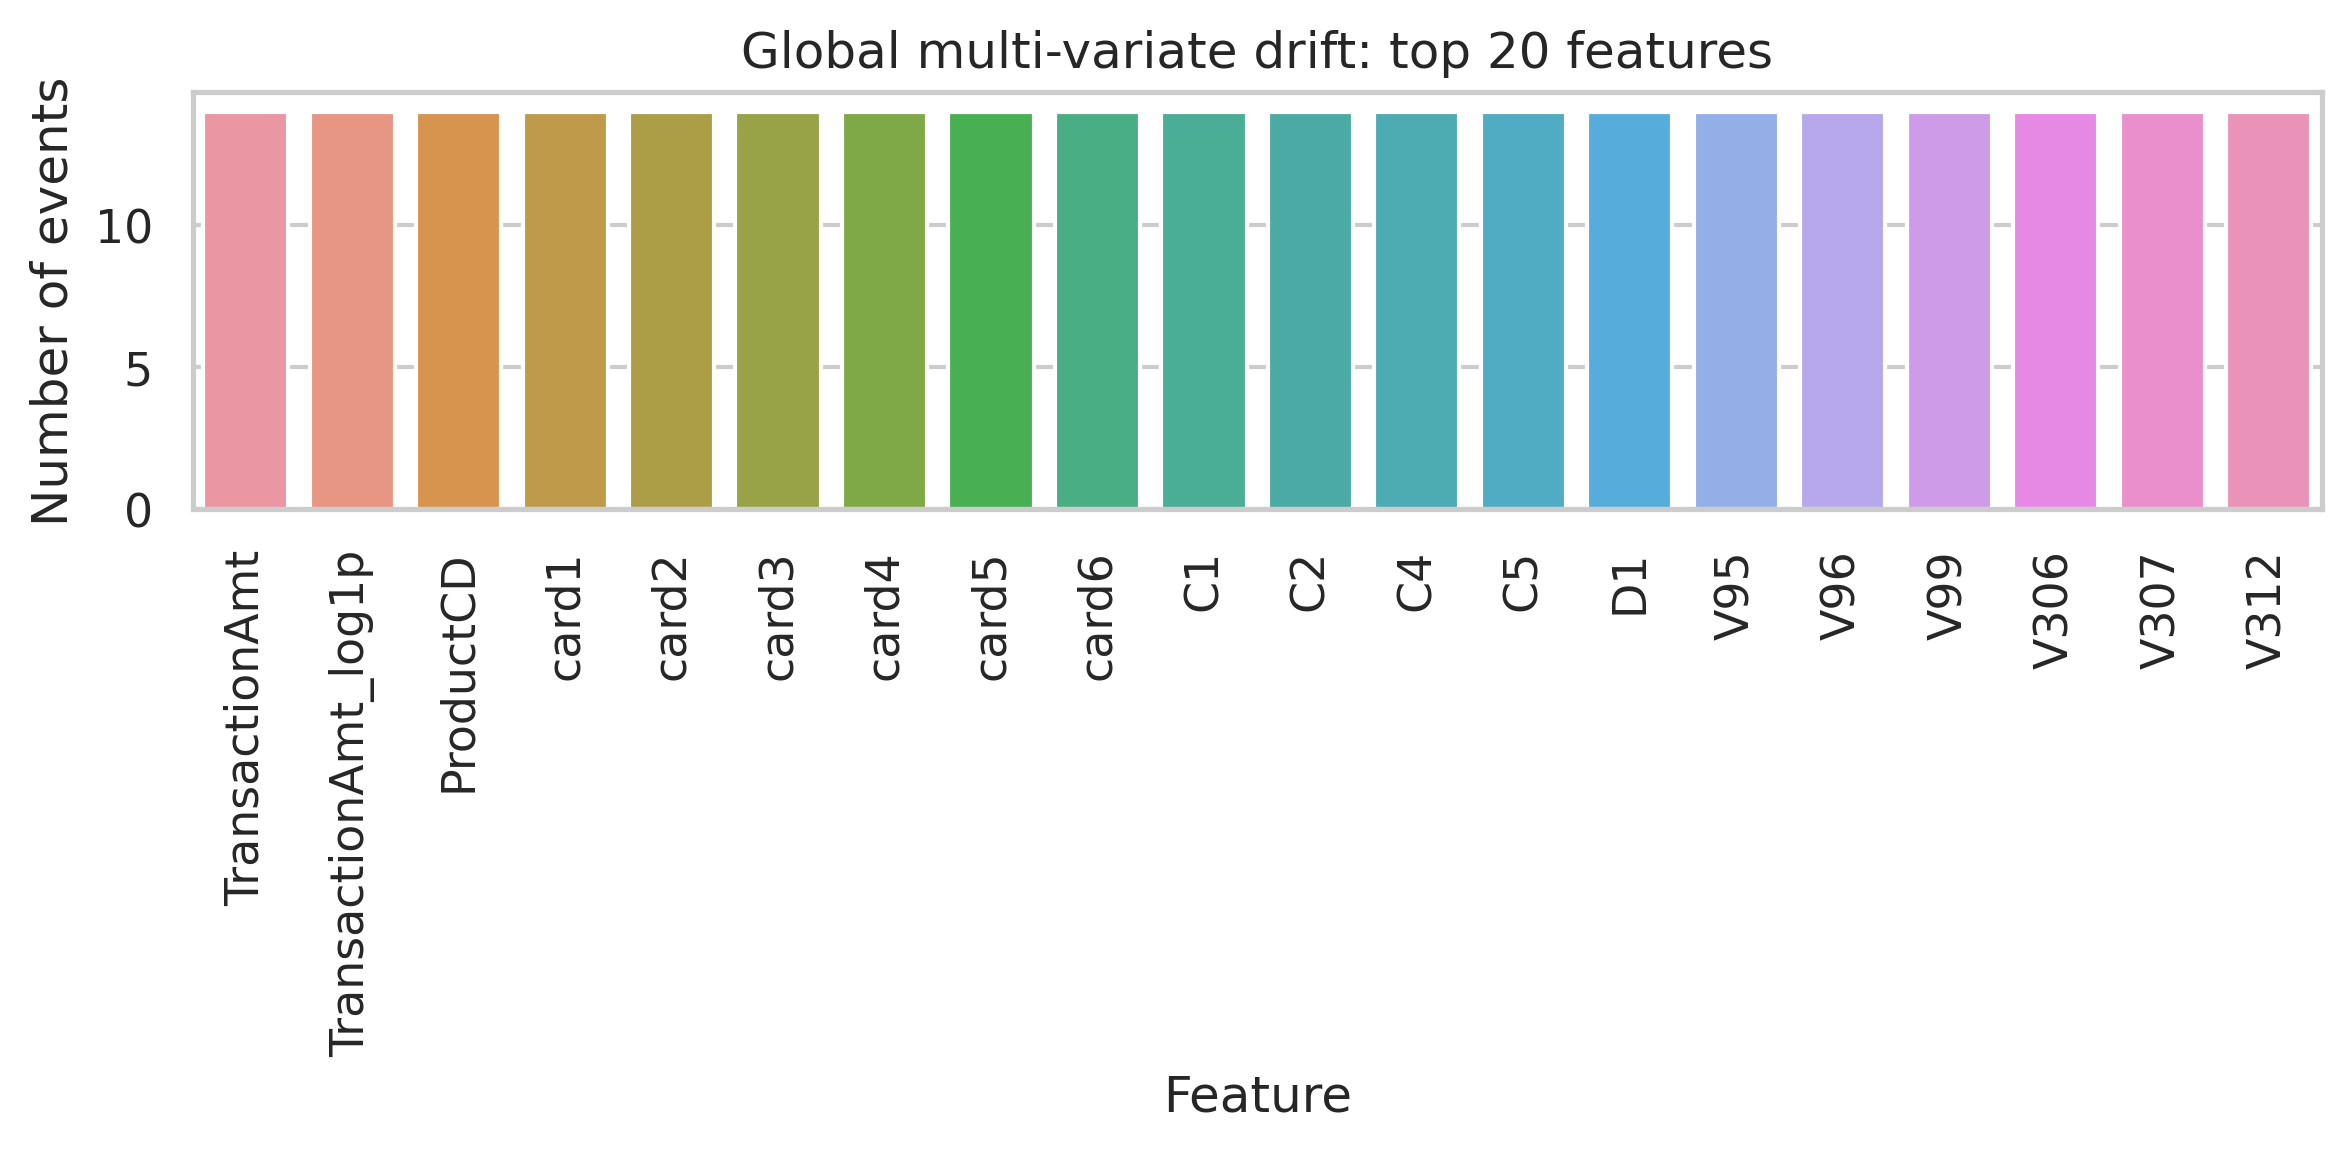

[INFO] Saved figure to: /kaggle/working/fig_global_multi_feature_counts_top20.png

[global + multi] Combination (top2) summary:


,combo2_str,num_events
0,card4 + card6,6
1,C1 + C2,5
2,V307 + V96,2
3,V95 + V96,1


[INFO] Saved global_multi_combo_summary.csv


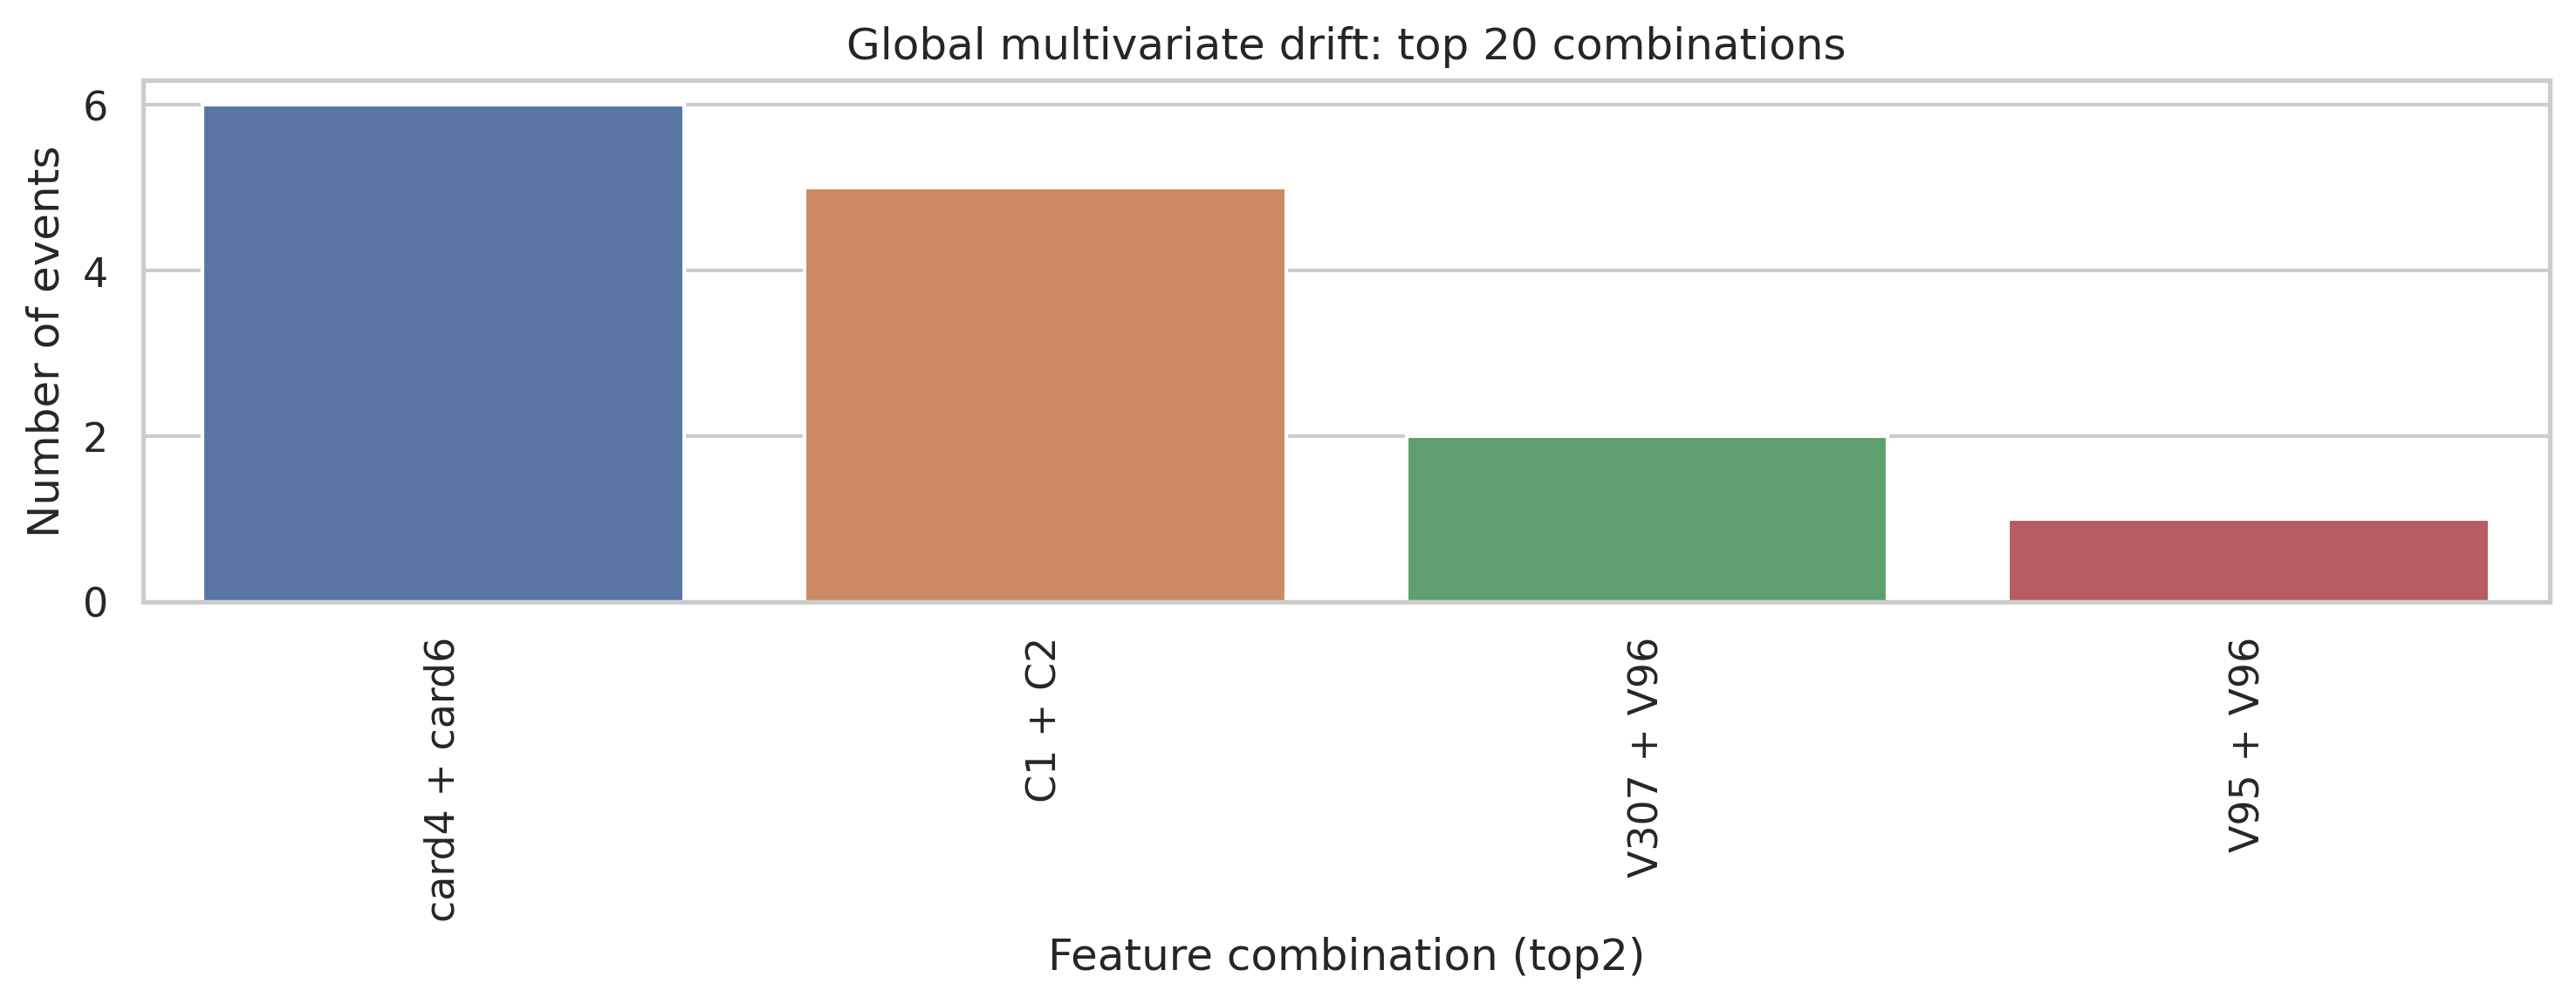

[INFO] Saved figure to: /kaggle/working/fig_global_multi_combo_counts_top20.png

[global + multi] Detector flag cross-tab (STAT vs ADWIN/PH):


ADWIN      False      
PH         False True 
STAT_drift            
True          13     1


[local + uni] Number of events: 3


,event_id,severity,local_boundary_index,card_id,dominant_feature,num_strong_features,adwin_flag,ph_flag,stat_flag
175,175,0.539546,29,9500,V312,1,False,False,True
177,177,0.627261,31,9500,V312,1,False,False,True
913,913,0.551585,2,12839,V307,1,False,False,True



[local + uni] Feature-wise summary:


,feature,num_events,mean_abs_psi
0,TransactionAmt,3,0.094257
1,TransactionAmt_log1p,3,0.111961
2,ProductCD,3,0.124059
3,card1,3,0.000000
4,card2,3,0.000000
5,card3,3,0.000000
6,card4,3,0.000000
7,card5,3,0.000000
8,card6,3,0.000000
9,C1,3,0.114393


[INFO] Saved local_uni_feature_summary.csv


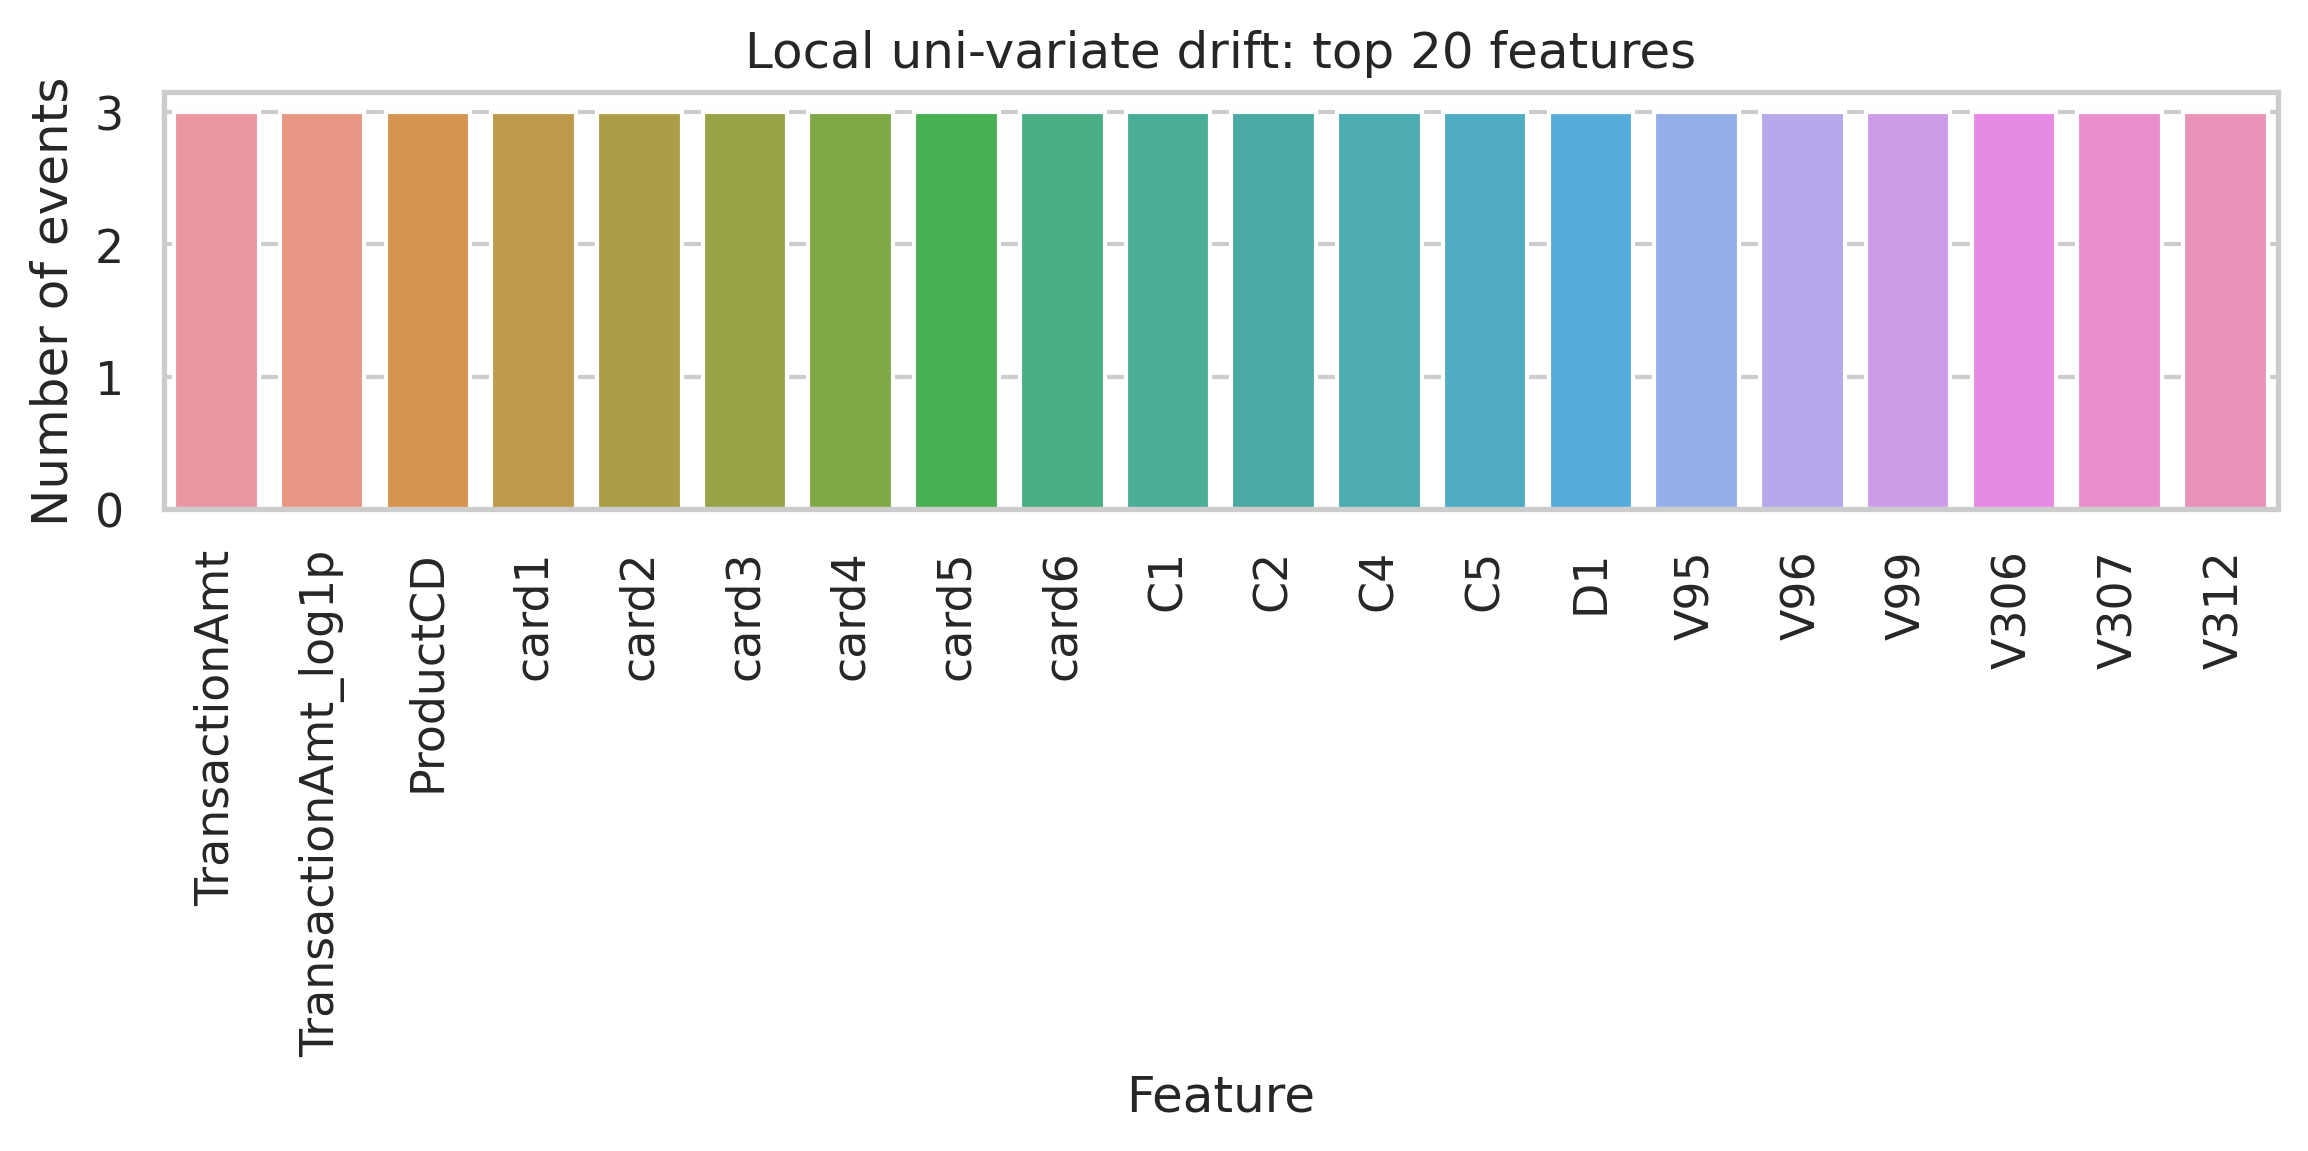

[INFO] Saved figure to: /kaggle/working/fig_local_uni_feature_counts_top20.png

[local + uni] Detector flag cross-tab (STAT vs ADWIN/PH):


ADWIN,False
PH,False
STAT_drift,
True,3



[local + multi] Number of events: 1931


,event_id,severity,local_boundary_index,card_id,dominant_feature,num_strong_features,adwin_flag,ph_flag,stat_flag
0,0,8.724985,0,7919,card5,11,False,False,True
1,1,3.845190,1,7919,card5,8,False,False,True
2,2,1.053507,2,7919,card5,8,False,False,True
3,3,1.132473,3,7919,C5,7,False,False,True
4,4,0.859599,4,7919,TransactionAmt,7,False,False,True
5,5,1.110474,5,7919,V306,9,False,False,True
6,6,0.984380,6,7919,V313,8,False,False,True
7,7,0.979956,7,7919,V306,6,False,False,True
8,8,1.942498,8,7919,card5,11,False,False,True
9,9,4.047834,9,7919,card5,9,False,False,True



[local + multi] Feature-wise summary:


,feature,num_events,mean_abs_psi
0,TransactionAmt,1931,0.277638
1,TransactionAmt_log1p,1931,0.234360
2,ProductCD,1931,0.137645
3,card1,1931,0.000000
4,card2,1931,0.009729
5,card3,1931,0.000000
6,card4,1931,0.055833
7,card5,1931,0.045827
8,card6,1931,0.055833
9,C1,1931,0.313585


[INFO] Saved local_multi_feature_summary.csv


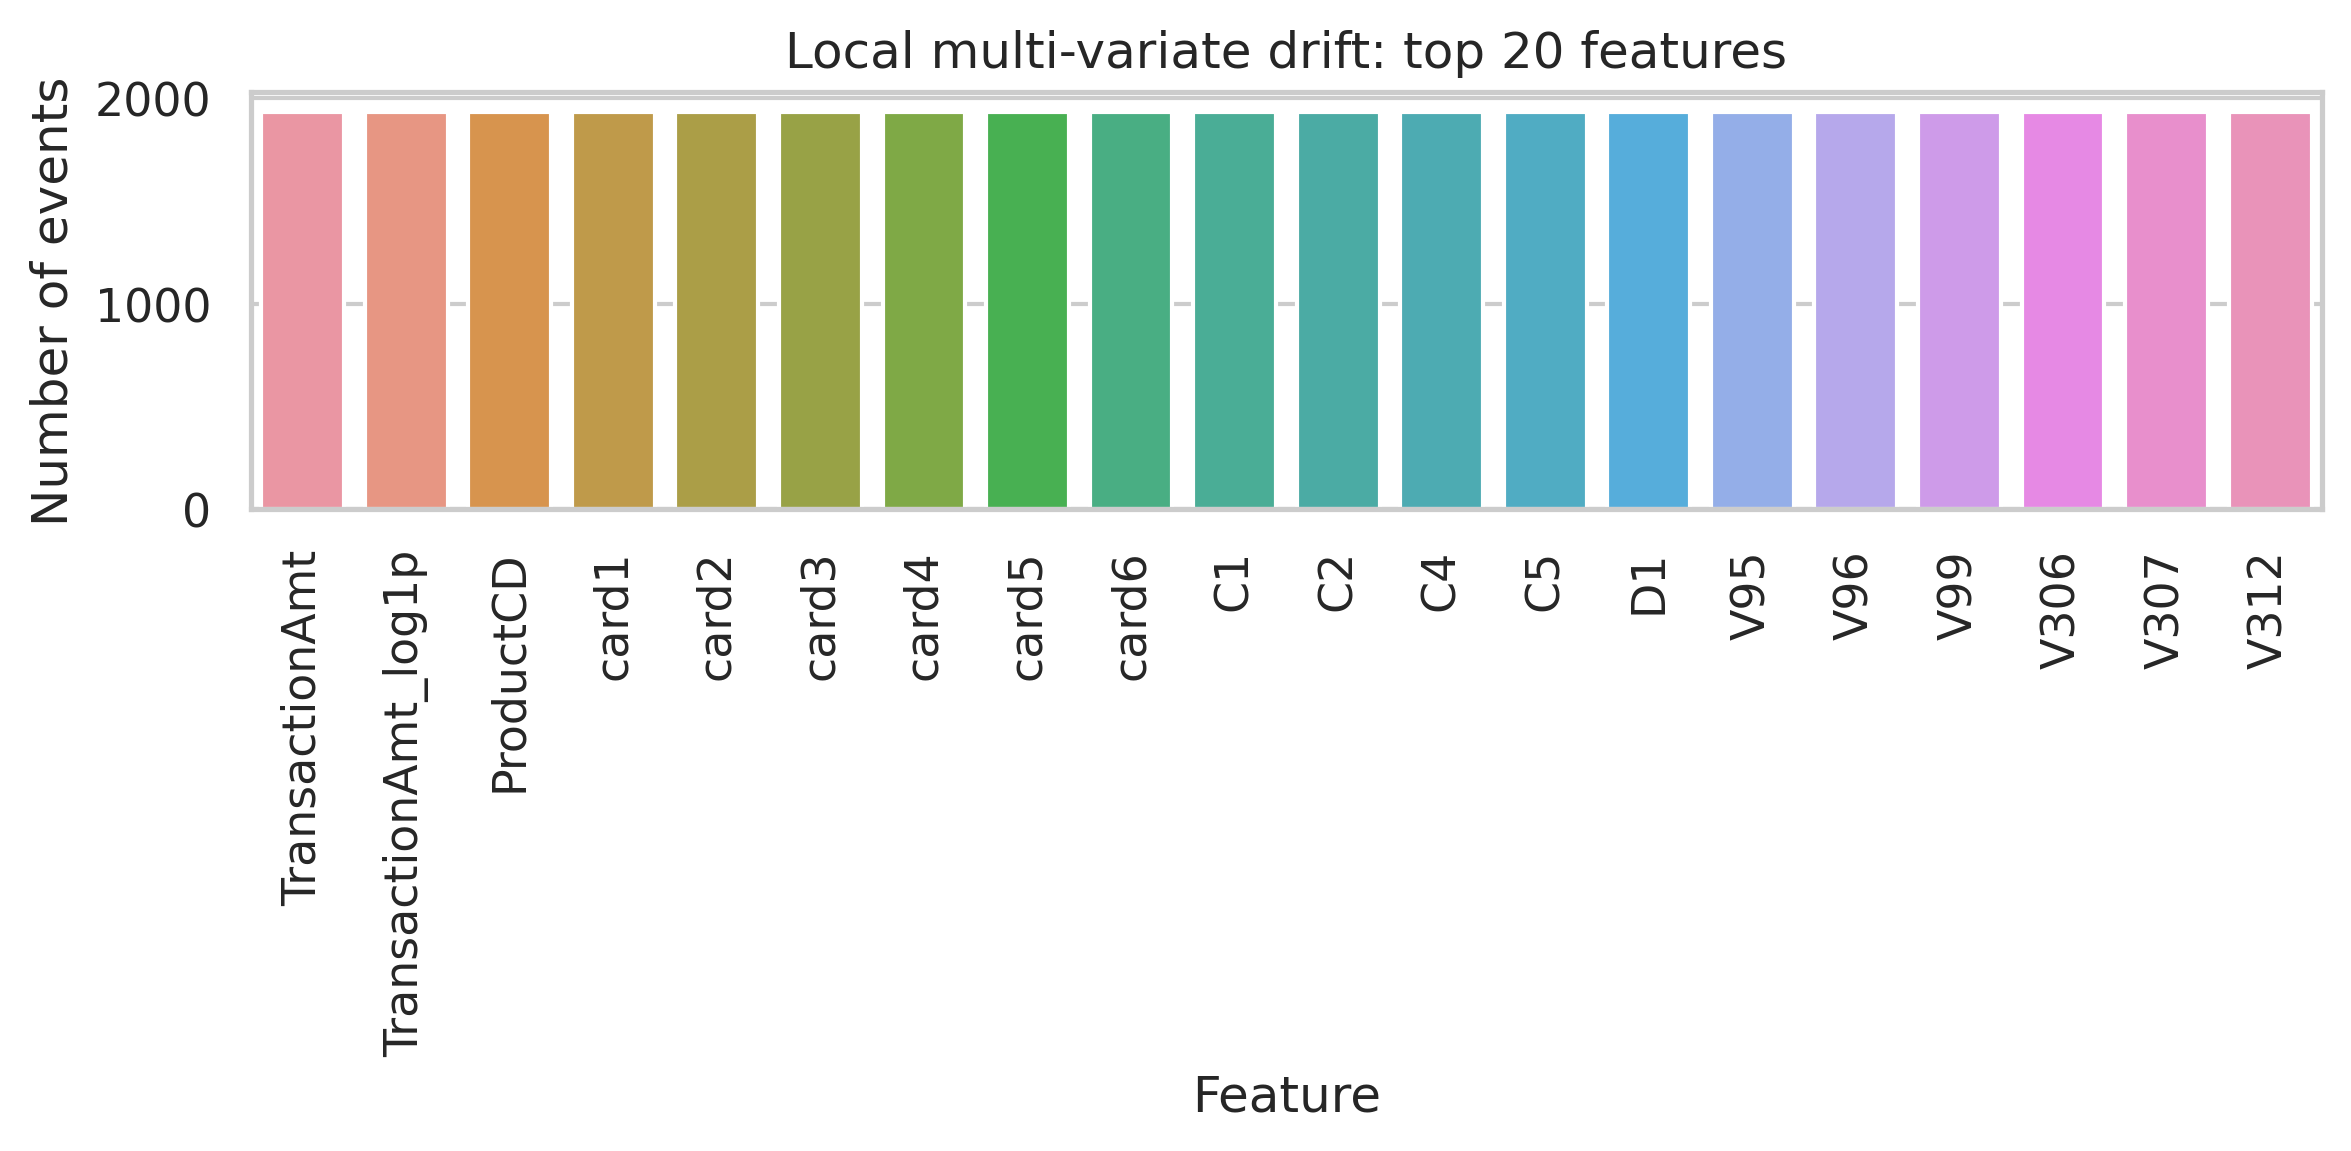

[INFO] Saved figure to: /kaggle/working/fig_local_multi_feature_counts_top20.png

[local + multi] Combination (top2) summary:


,combo2_str,num_events
0,V312 + V313,137
1,V307 + V312,104
2,V307 + V96,82
3,C1 + C2,75
4,V96 + V99,71
5,card4 + card6,51
6,TransactionAmt + V312,48
7,V312 + V96,45
8,C1 + C5,42
9,V306 + V312,35


[INFO] Saved local_multi_combo_summary.csv


/tmp/ipykernel_47/731896106.py:110: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


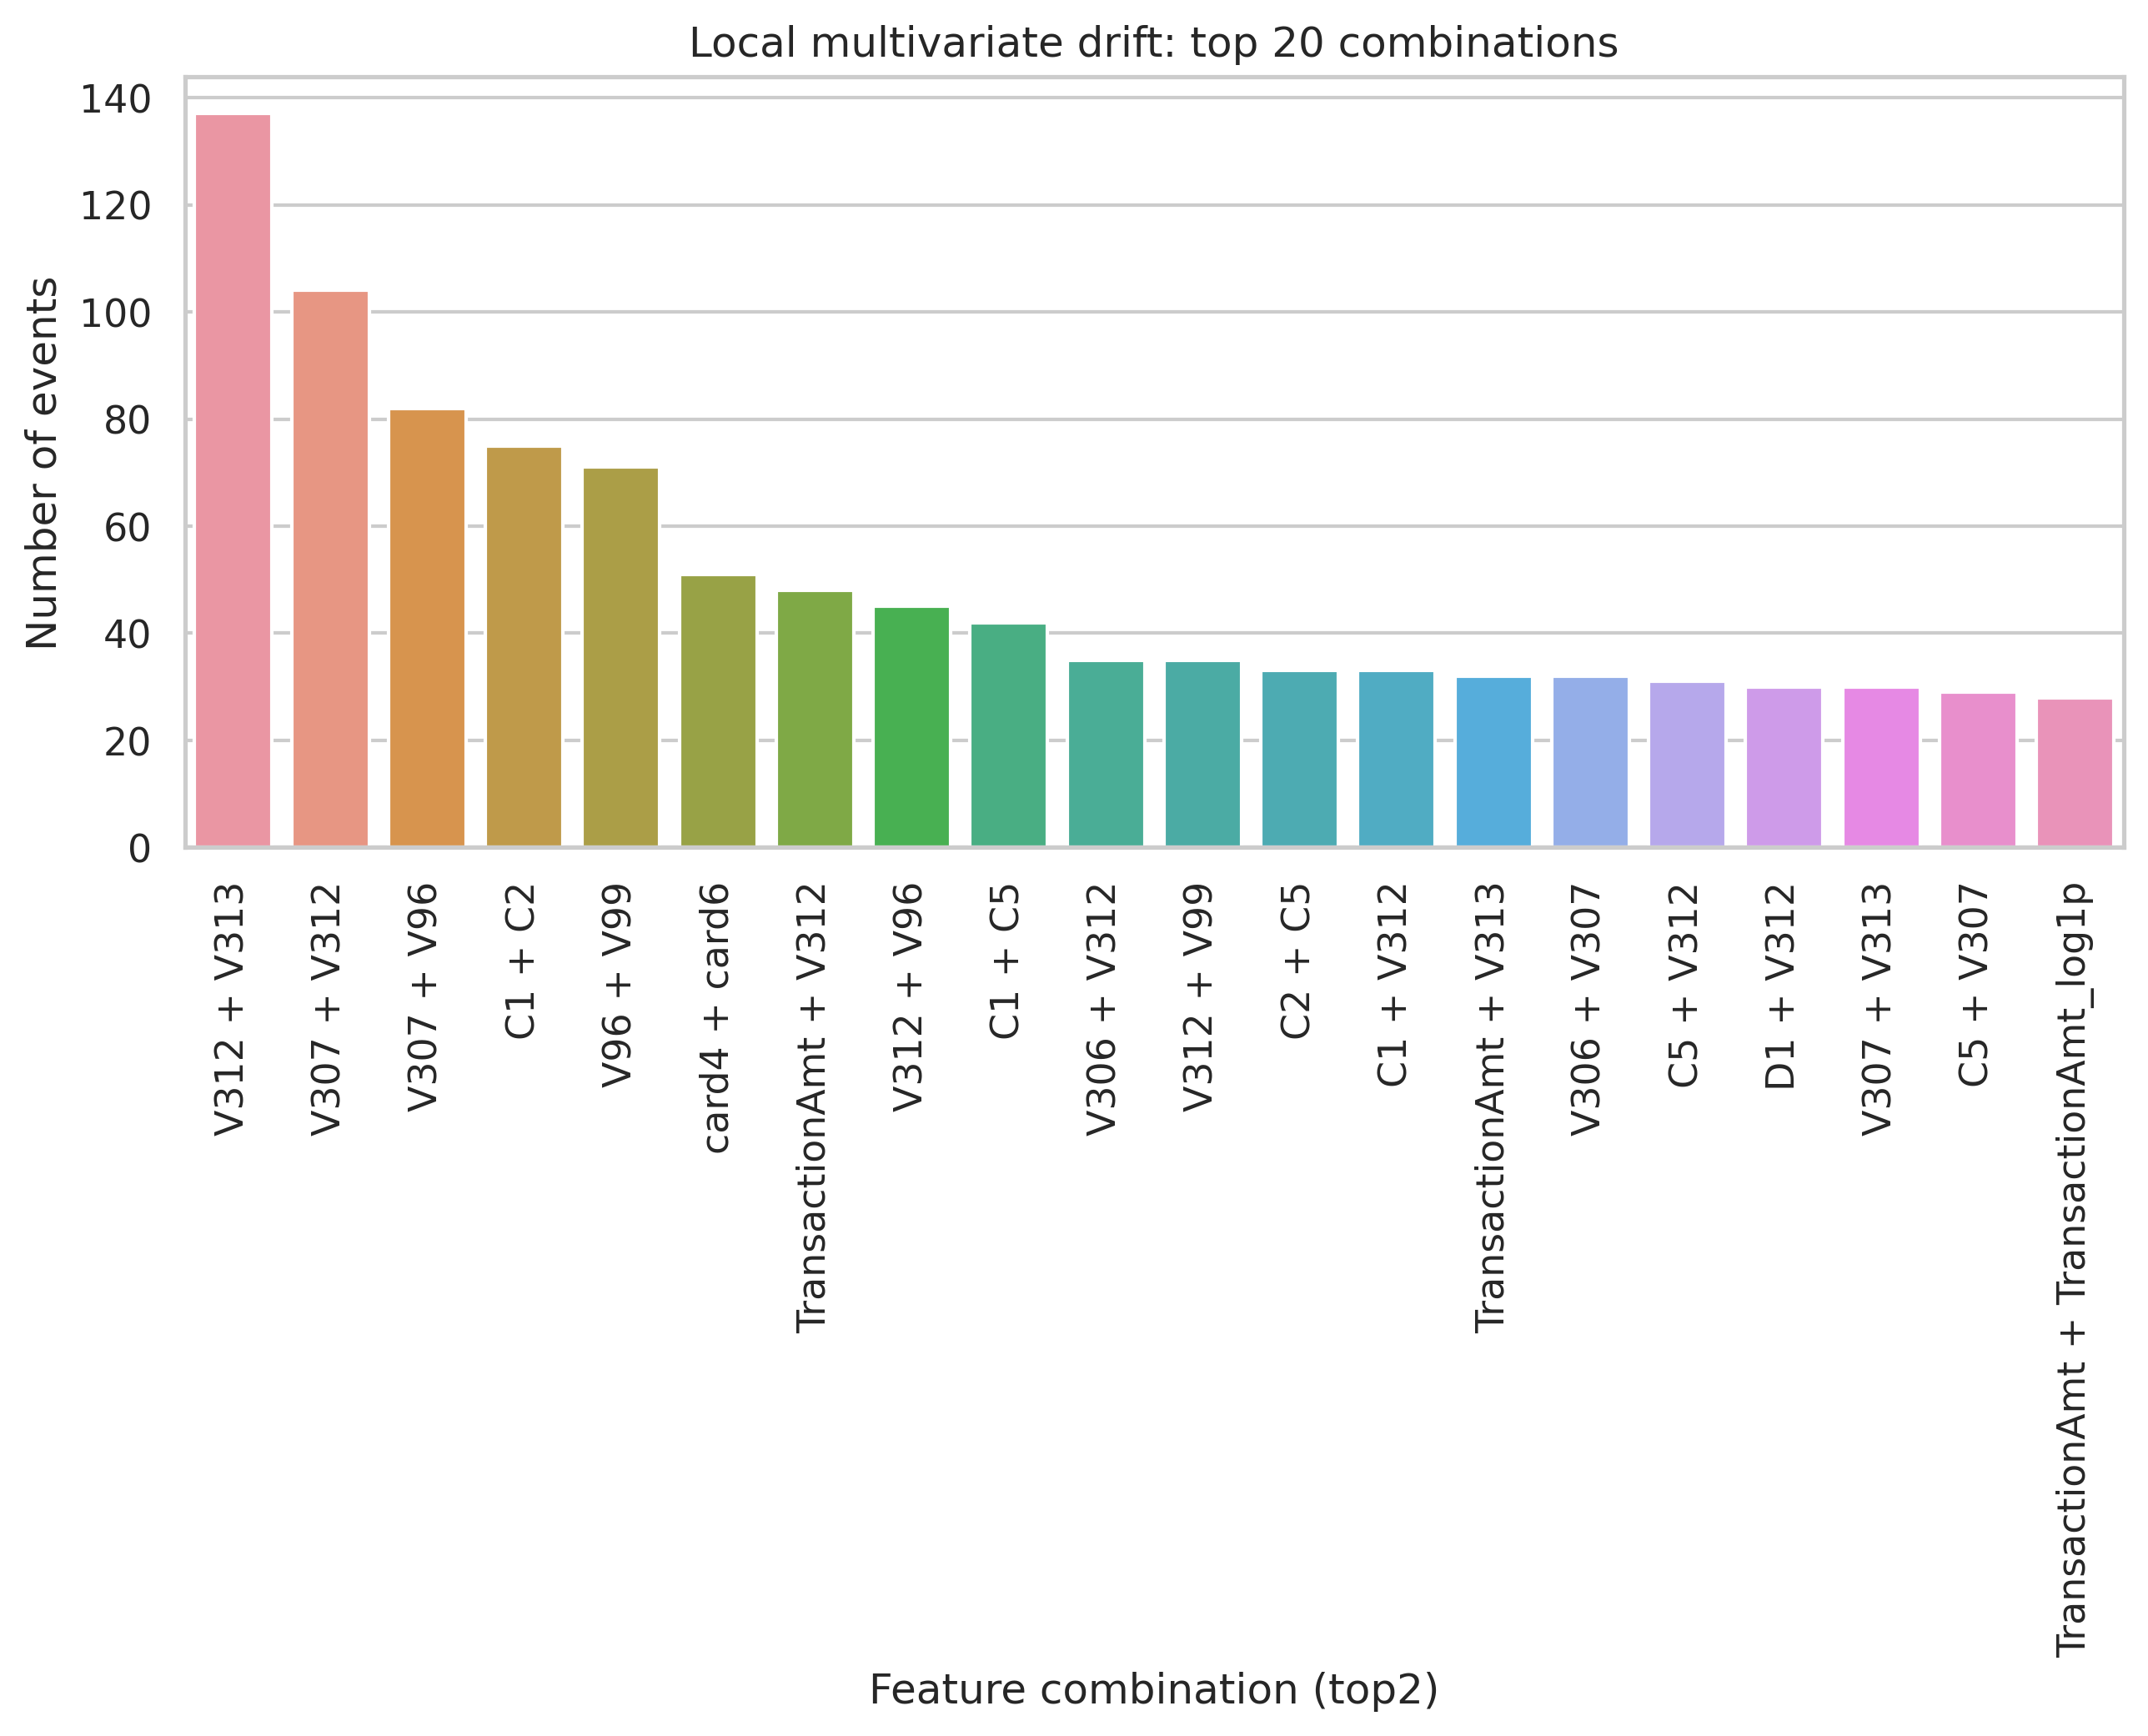

[INFO] Saved figure to: /kaggle/working/fig_local_multi_combo_counts_top20.png

[local + multi] Detector flag cross-tab (STAT vs ADWIN/PH):


ADWIN      False       True       
PH         False True  False True 
STAT_drift                        
True        1849    22    58     2


df_with_drift shape: (590540, 400)

Drift label summary:


,drift_label,count,percentage
0,LOCAL_ONLY,408348,69.15
1,CONFIRMED_BOTH,179927,30.47
2,NO_DRIFT,2192,0.37
3,GLOBAL_ONLY,73,0.01


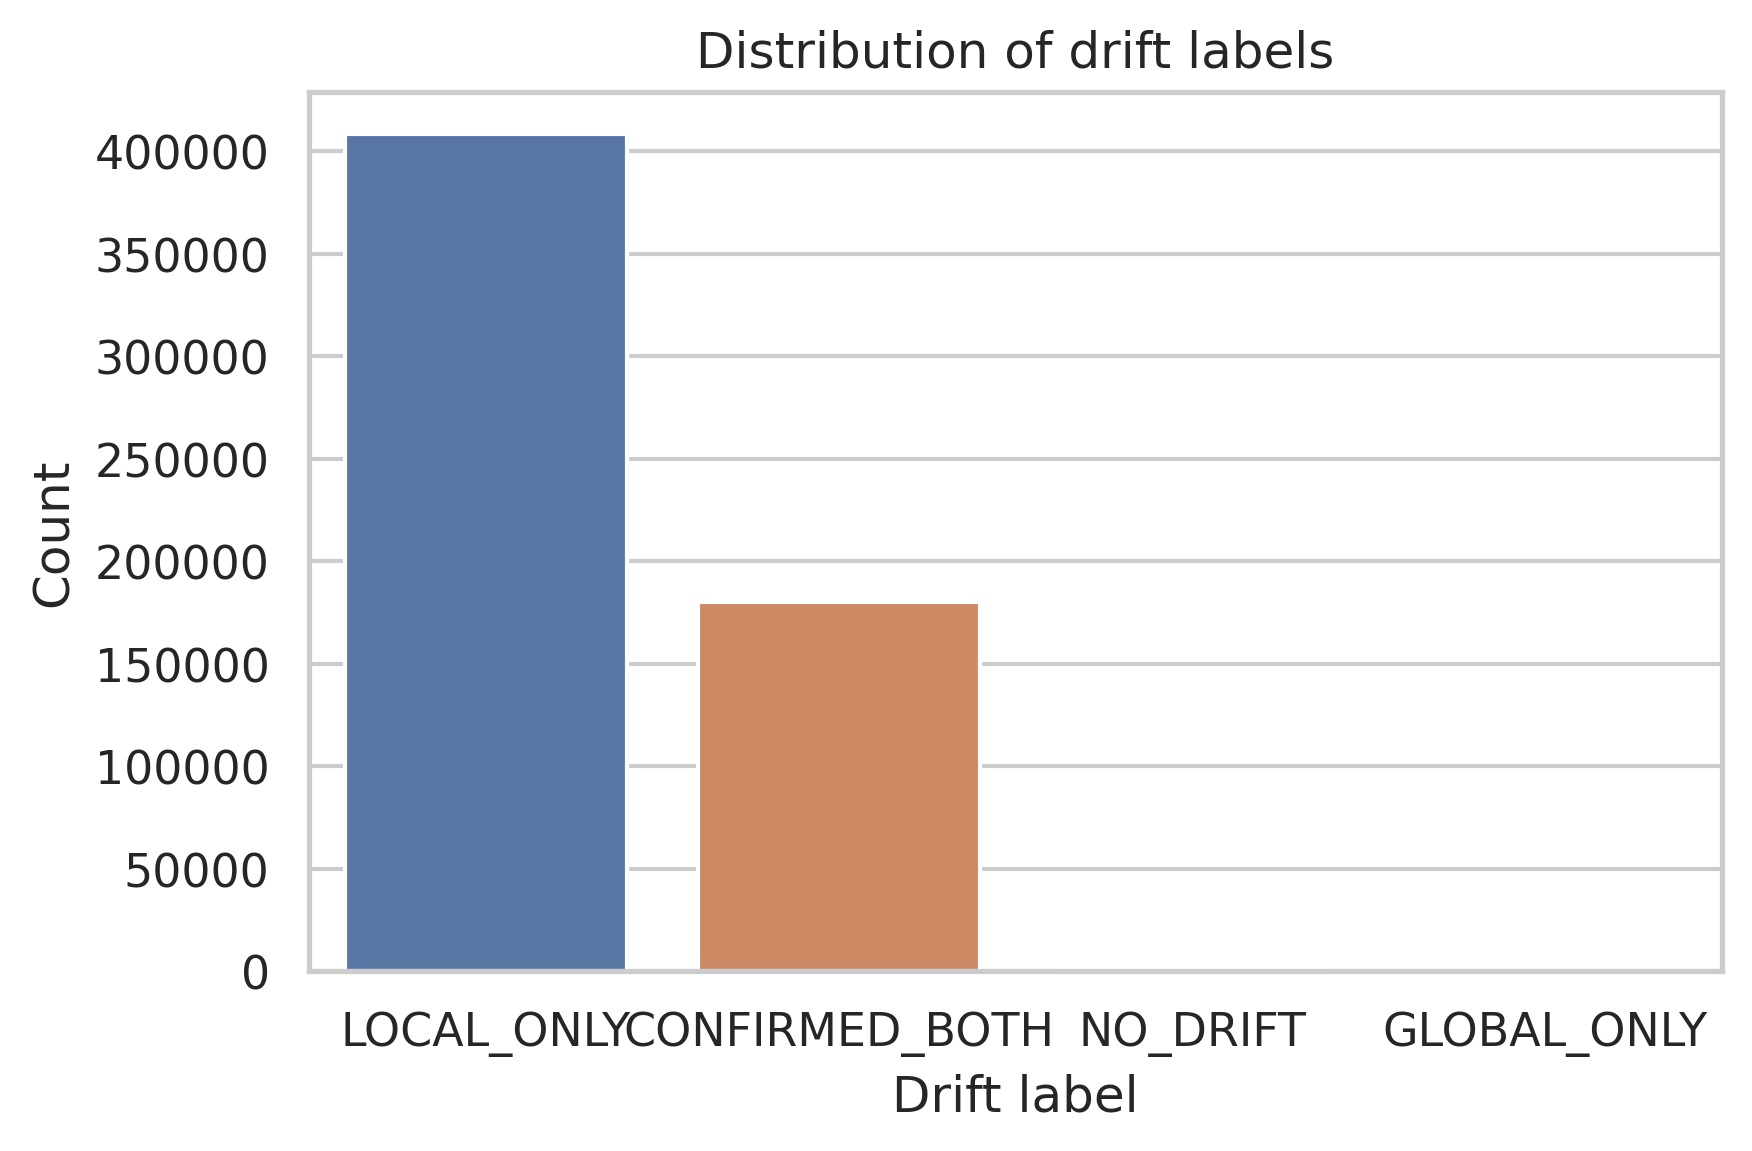

[INFO] Saved figure to: /kaggle/working/fig_drift_label_distribution.png

Fraud rate by drift_label:


,drift_label,count,fraud_count,fraud_rate
0,CONFIRMED_BOTH,"179,927","5,665",3.1485%
1,GLOBAL_ONLY,73,0,0.0000%
2,LOCAL_ONLY,"408,348","14,939",3.6584%
3,NO_DRIFT,"2,192",59,2.6916%


[INFO] Saved fraud_rate_by_drift_label.csv


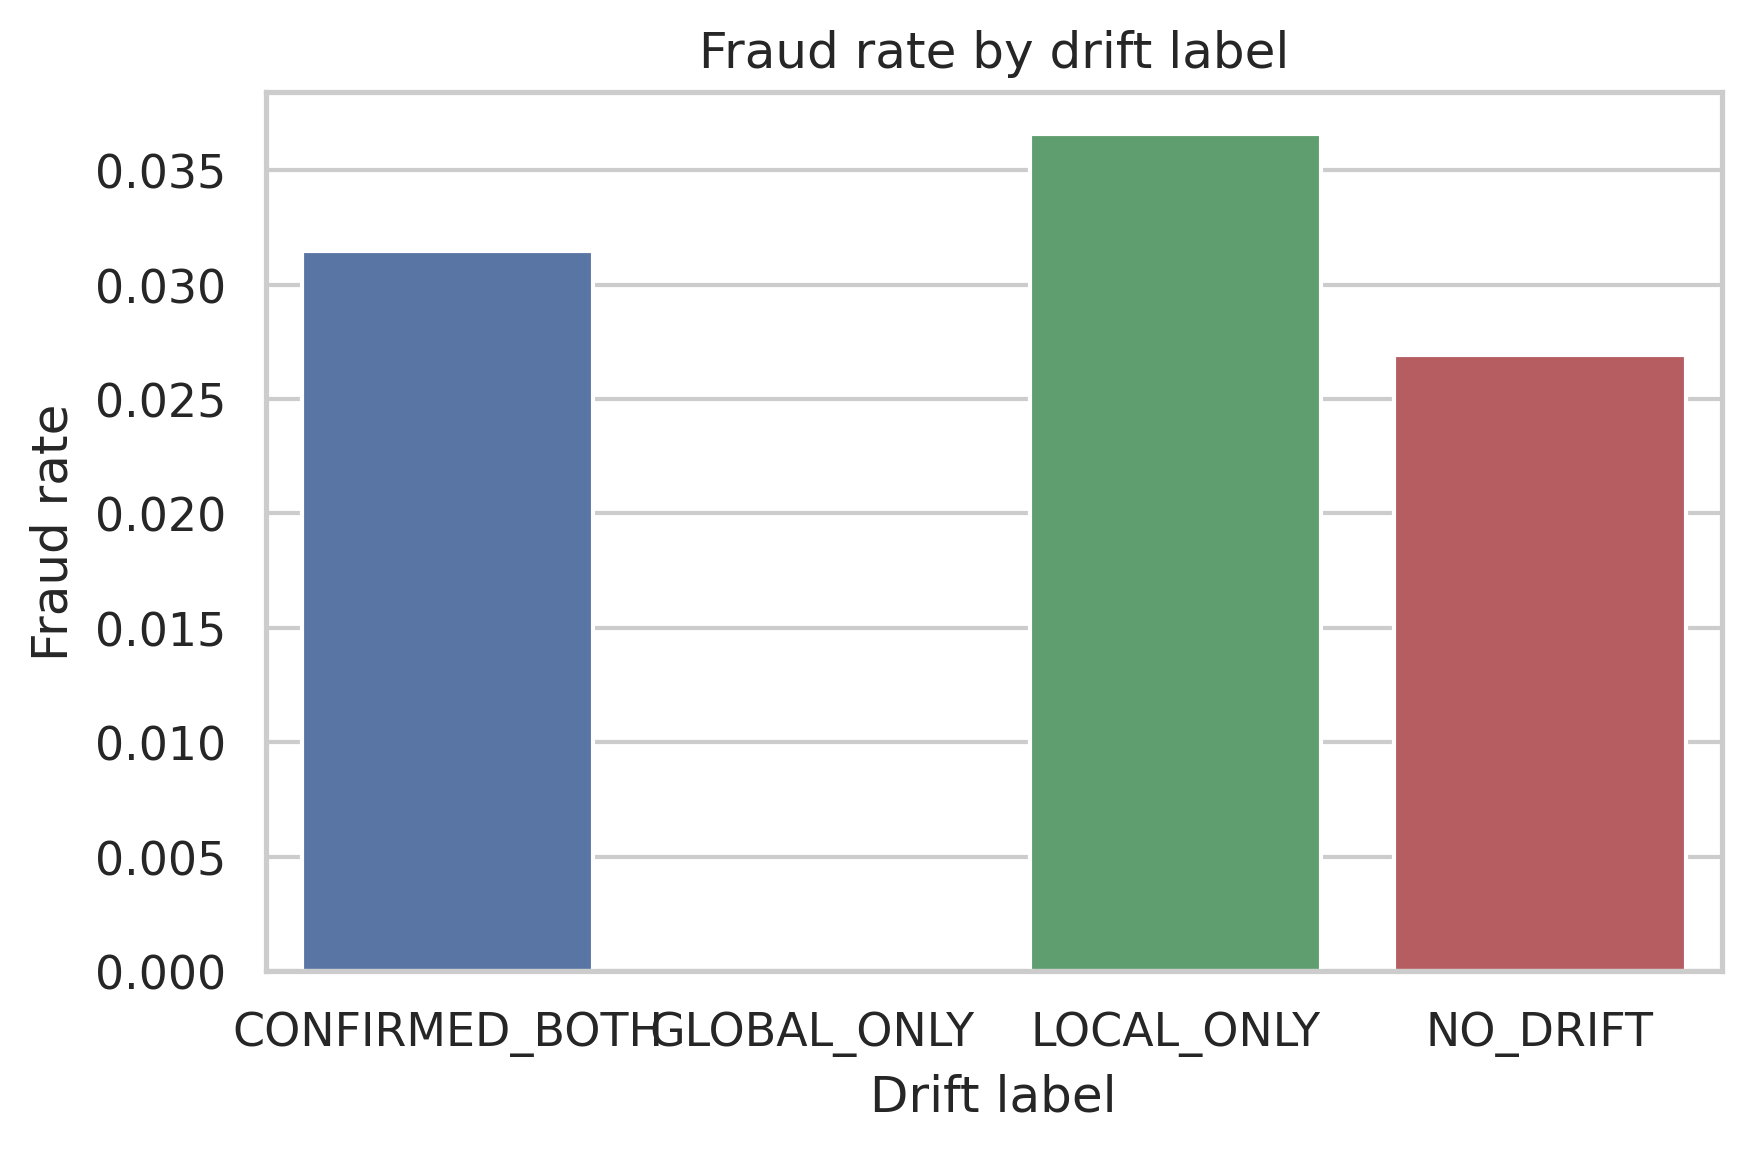

[INFO] Saved figure to: /kaggle/working/fig_fraud_rate_by_drift_label.png

=== Explanation for TransactionID=3017000 ===
row_idx: 30000
drift_label: CONFIRMED_BOTH
local_drift_flag: 1, global_drift_flag: 1
drift_intensity: 37.0615

Global events overlapping this transaction:
  - event_id=0, boundary_index=1, severity=0.5449, flags: ADWIN=False, PH=False, STAT=True
    Top PSI features:
      C2: PSI=0.3252
      C1: PSI=0.3091
      C4: PSI=0.3050
      ProductCD: PSI=0.0459
      D1: PSI=0.0132

Local events overlapping this transaction:
  - card_id=7919, event_id=11, severity=1.8079, flags: ADWIN=False, PH=False, STAT=True
    Top PSI features:
      V312: PSI=0.9908
      V307: PSI=0.8141
      V95: PSI=0.7421
      V306: PSI=0.6259
      V96: PSI=0.5034
  - card_id=7919, event_id=12, severity=0.9716, flags: ADWIN=False, PH=False, STAT=True
    Top PSI features:
      V313: PSI=0.5148
      V312: PSI=0.4852
      C2: PSI=0.3132
      C1: PSI=0.3090
      TransactionAmt_log1p: PSI=0.

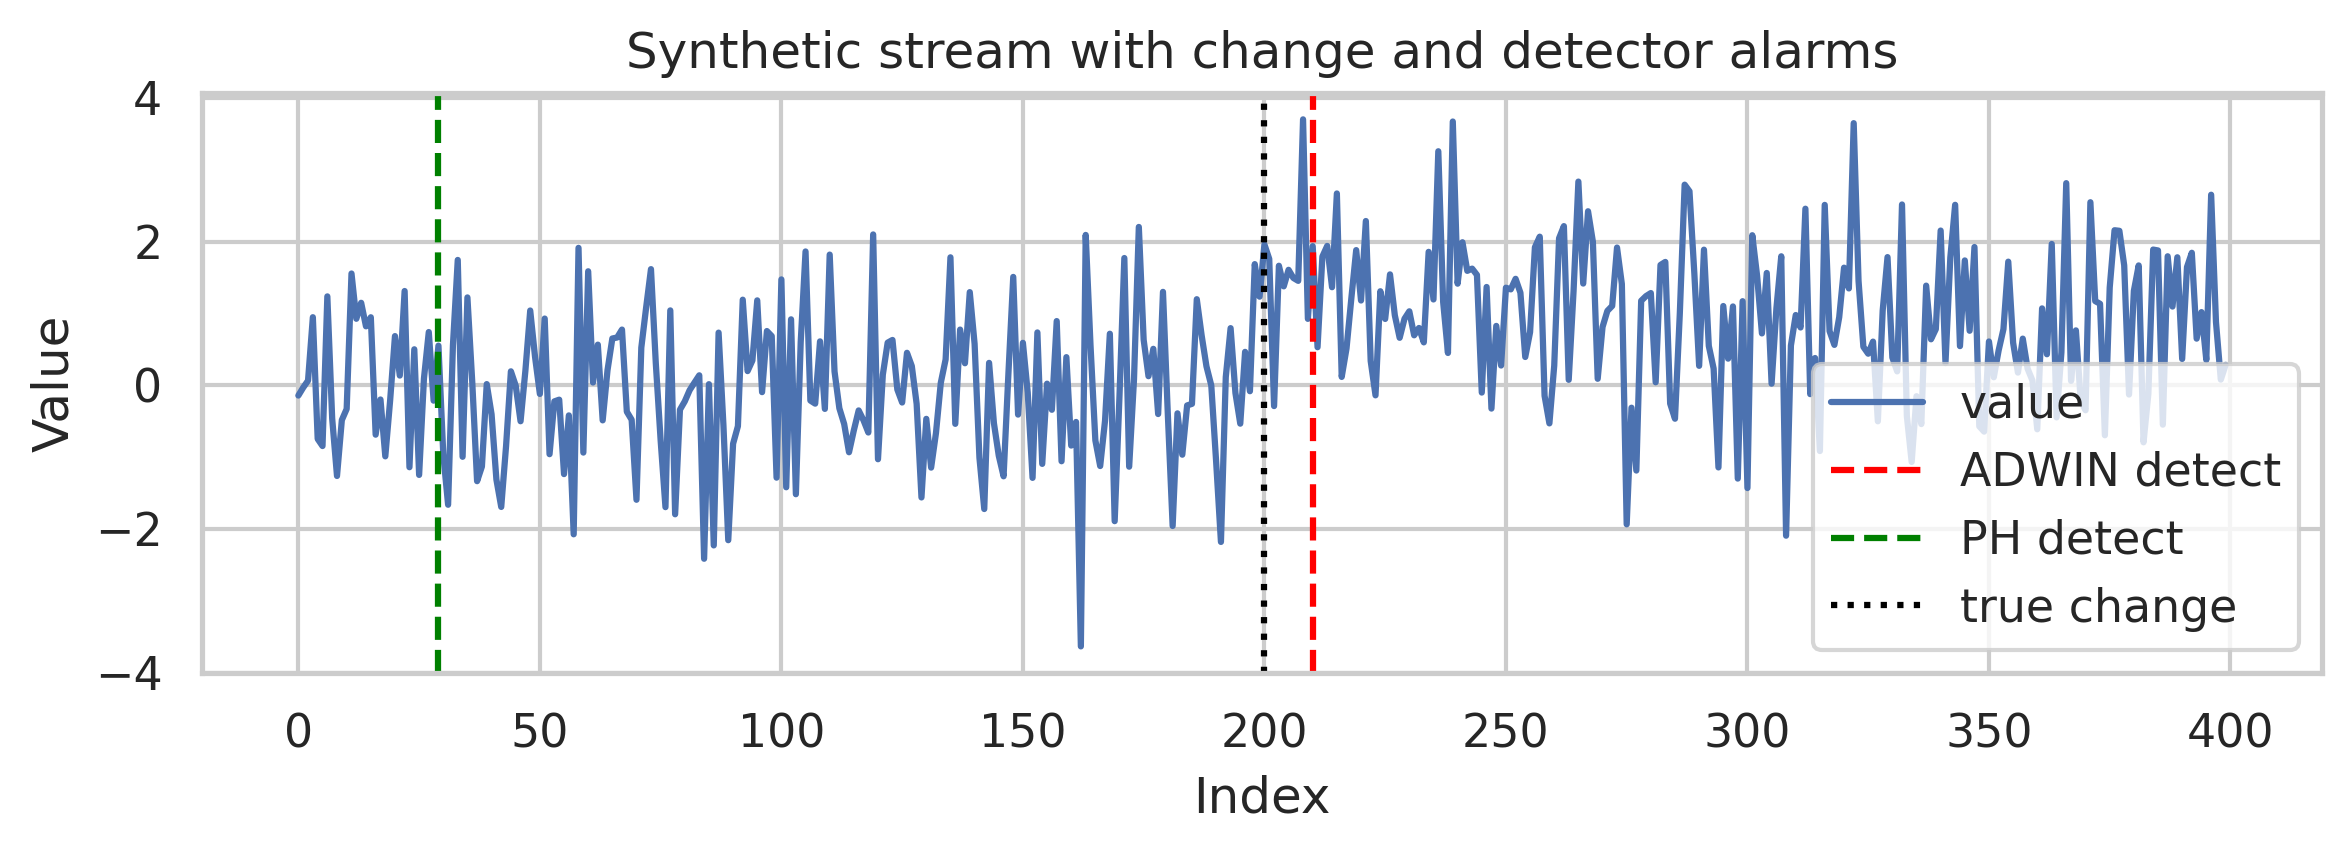

[INFO] Saved figure to: /kaggle/working/fig_synth_stream_detectors.png
hi


In [27]:
# ============================================================
# 12. Main notebook flow
# ============================================================

# 12.1 Load and EDA
df_raw = load_ieee_data(cfg)
print("Raw shape:", df_raw.shape)

df = df_raw.sort_values(cfg.time_col).reset_index(drop=True)
df["row_idx"] = np.arange(len(df), dtype=int)
print("Sorted shape:", df.shape)

rich_eda(df, cfg)

# 12.2 Drift feature selection (manual ~20 features + <5% missing)

MANUAL_DRIFT_FEATURES = [
    "TransactionAmt", "TransactionAmt_log1p",
    "ProductCD",
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1",
    "C1", "C2", "C4", "C5",
    "D1", "D2",
    "V95", "V96", "V99",
    "V306", "V307", "V312", "V313",
]

drift_feat_cfg = DriftFeatureConfig(
    max_missing_pct=DRIFT_MAX_MISSING_PCT,
    add_features=MANUAL_DRIFT_FEATURES,
    drop_features=[],
    use_manual_only=True,
)

drift_features, drift_feature_table = select_drift_features(df, cfg, drift_feat_cfg)

# 12.3 Global drift detection

global_events_df, global_boundary_scores_df = GlobalDriftAnalyzer(
    df=df,
    cfg=cfg,
    drift_features=drift_features,
).run()

print("\nGlobal drift events:", global_events_df.shape)
display(global_events_df.head())

print("\nGlobal boundary scores (first 10):")
display(global_boundary_scores_df.head(10))

print("\nSummary of global boundary severities:")
display(global_boundary_scores_df["severity"].describe().to_frame().T)

if not global_boundary_scores_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
    sns.lineplot(
        data=global_boundary_scores_df,
        x="boundary_index",
        y="severity",
        marker="o",
        ax=ax,
    )
    for _, ev in global_events_df.iterrows():
        ax.axvline(ev["boundary_index"], color="red", alpha=0.3, linestyle="--")
    ax.set_xlabel("Boundary index")
    ax.set_ylabel("Severity (L2 PSI)")
    ax.set_title("Global drift severity over boundaries")
    plt.tight_layout()
    save_fig_300dpi(fig, "fig_global_severity_timeline.png", cfg)

# 12.4 Local drift detection (card-level)

if cfg.card_id_col in df.columns:
    card_counts = df[cfg.card_id_col].value_counts()
    eligible = card_counts[card_counts >= cfg.local_min_tx_per_card]
    top_cards = eligible.head(cfg.max_cards_for_local).index.tolist()
    print(f"\nLocal drift: analysing {len(top_cards)} cards with >= {cfg.local_min_tx_per_card} tx each.")
else:
    top_cards = []
    print("No card1 column, skipping local drift.")

local_events_df = LocalDriftAnalyzer(
    df=df,
    cfg=cfg,
    drift_features=drift_features,
).run_for_cards(top_cards)

print("\nLocal drift events:", local_events_df.shape)
display(local_events_df.head())

if not local_events_df.empty:
    # Count events per card
    events_per_card = (
        local_events_df["card_id"]
        .value_counts()
        .reset_index()
    )
    events_per_card.columns = ["card_id", "num_events"]
    events_per_card = events_per_card.sort_values("num_events", ascending=False)

    print("\nLocal drift events per card (top 30):")
    display(events_per_card.head(30))

    fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
    sns.barplot(
        data=events_per_card.head(30),
        x="card_id",
        y="num_events",
        ax=ax,
    )
    ax.set_xlabel("Card ID")
    ax.set_ylabel("Number of local drift events")
    ax.set_title("Local drift events per card (top 30)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    save_fig_300dpi(fig, "fig_local_events_per_card_top30.png", cfg)

# 12.5 Uni- vs multi-variate drift summaries and detector comparison

global_uni, global_multi = split_events_uni_multi(global_events_df)
local_uni, local_multi = split_events_uni_multi(local_events_df)

summarize_psi_events(global_uni, "global", "uni", cfg)
summarize_psi_events(global_multi, "global", "multi", cfg)
summarize_psi_events(local_uni, "local", "uni", cfg)
summarize_psi_events(local_multi, "local", "multi", cfg)

# 12.6 Transaction-level drift label integration

df_with_drift = integrate_drift_labels(df, global_events_df, local_events_df, cfg)
print("\ndf_with_drift shape:", df_with_drift.shape)

drift_label_summary = summarize_drift_labels(df_with_drift, cfg)

# 12.7 Fraud linkage

fraud_summary_df = fraud_rate_by_drift_label(df_with_drift, cfg)

# 12.8 Example explanation for one CONFIRMED_BOTH transaction (if available)

example_tx = df_with_drift[df_with_drift["drift_label"] == DRIFT_BOTH]
if not example_tx.empty:
    example_tx_id = int(example_tx[cfg.transaction_id_col].iloc[0])
    explain_transaction(example_tx_id, df_with_drift,
                        global_events_df, local_events_df, cfg)
else:
    print("\nNo CONFIRMED_BOTH transactions found (with current thresholds) to explain.")

# 12.9 Synthetic sanity tests

run_synthetic_tests(cfg)

print("hi")